# Orchestration as Hypothesis Testing — wandb analysis notebook

Pulls every run from `nlpresearch.group/orchestration-hypothesis-testing` into a single
`pandas.DataFrame`, caches to parquet, and reproduces every figure in the deck from wandb
data alone (no local file dependencies).

**Workflow:**
1. Run `python upload_runs.py` once to populate the project from local data.
2. Run this notebook top-to-bottom. Each section is one figure / table.
3. Re-run anytime — wandb is the source of truth; local data files are not needed.

See `SCHEMA.md` for the run convention this notebook assumes.

In [121]:
# %% Setup
import os, json, math
from pathlib import Path
from typing import Iterable

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import wandb

ENTITY  = "nlpresearch.group"
PROJECT = "orchestration-hypothesis-testing"
CACHE   = Path(".cache")
CACHE.mkdir(exist_ok=True)

POLICY_NAMES = [
    "always_verify", "best_of_3", "threshold_L0", "threshold_L2",
    "threshold_L3", "fixed_pipeline", "bayesian_greedy", "bayesian_DP",
]

REGIME_BY_BENCH = {
    "lcb_hard": "A", "lcb_medium": "A", "lcb_easy": "A",
    "swe_lite": "B", "swe_verified": "B",
    "mbpp": "C", "humaneval": "C",
    "codecontests": "A", "humanevalfix": "C",   # abbo track
}

print(f"wandb v{wandb.__version__}")
print(f"Project: https://wandb.ai/{ENTITY}/{PROJECT}")

wandb v0.26.0
Project: https://wandb.ai/nlpresearch.group/orchestration-hypothesis-testing


## 1. Fetch all runs and build the DataFrame

Cached to `.cache/runs.parquet`. Pass `force_refresh=True` after a new upload.

In [122]:
# %% Fetch runs
try:
    from tqdm.auto import tqdm
except ImportError:  # graceful no-op if tqdm is unavailable
    def tqdm(x, **kw):
        return x

def _scalarize(d: dict) -> dict:
    """Make a config/summary dict parquet-safe: drop wandb-internal keys and
    JSON-stringify any nested dict/list values (pyarrow can't infer a type
    for objects like the `_wandb` SummarySubDict `{'runtime': 2}`)."""
    out = {}
    for k, v in d.items():
        if k == "_wandb":            # wandb-internal, not analysis data
            continue
        if isinstance(v, (dict, list, tuple, set)):
            out[k] = json.dumps(v, default=str)
        else:
            out[k] = v
    return out

def fetch_runs(force_refresh: bool = False) -> pd.DataFrame:
    cache_path = CACHE / "runs.parquet"
    if cache_path.exists() and not force_refresh:
        print(f"Loading cached DataFrame from {cache_path}")
        return pd.read_parquet(cache_path)

    api = wandb.Api()
    runs = list(api.runs(f"{ENTITY}/{PROJECT}"))
    print(f"Fetched {len(runs)} runs")

    rows = []
    for r in tqdm(runs, desc="Reading run config/summary", unit="run"):
        row = _scalarize(dict(r.config))
        row.update(_scalarize(dict(r.summary)))
        row["_run_id"] = r.id
        row["_run_name"] = r.name
        row["_tags"] = ",".join(r.tags)
        row["_url"] = r.url
        rows.append(row)

    df = pd.DataFrame(rows)
    # Coerce numeric where possible
    for c in df.columns:
        if c.startswith("_") or c in ("track", "experiment_type", "benchmark",
                                       "generator", "method", "kernel_source",
                                       "l3_reviewer", "analysis", "git_sha",
                                       "data_source", "pool_version", "sweep_axis",
                                       "best_policy"):
            continue
        df[c] = pd.to_numeric(df[c], errors="ignore")
    # Any column still object-typed with non-scalar entries -> stringify so
    # the parquet write can't fail on a stray nested value.
    for c in df.columns:
        if df[c].dtype == object:
            df[c] = df[c].map(
                lambda v: json.dumps(v, default=str)
                if isinstance(v, (dict, list, tuple, set)) else v
            )
    df.to_parquet(cache_path)
    print(f"Cached → {cache_path}")
    return df

df = fetch_runs(force_refresh=False)
print(f"DataFrame: {df.shape[0]} runs × {df.shape[1]} columns")
df[["_run_name", "track", "experiment_type", "benchmark", "generator"]].sample(15)

Loading cached DataFrame from .cache/runs.parquet
DataFrame: 213 runs × 87 columns


,_run_name,track,experiment_type,benchmark,generator
127,policy_comparison__orchestration__lcb_medium__...,orchestration,policy_comparison,lcb_medium,qwen3_coder
158,policy_comparison__orchestration__mbpp__haiku4...,orchestration,policy_comparison,mbpp,haiku45
163,policy_comparison__orchestration__humaneval__g...,orchestration,policy_comparison,humaneval,gpt5_mini
40,iter__orchestration__lcb_medium__sonnet45__sin...,orchestration,iter,lcb_medium,sonnet45
90,iter__orchestration__swe_lite__qwen25_32b__ref...,orchestration,iter,swe_lite,qwen25_32b
73,iter__orchestration__lcb_easy__qwen3_coder__se...,orchestration,iter,lcb_easy,qwen3_coder
16,calibration__orchestration__mbpp__qwen3_coder,orchestration,calibration,mbpp,qwen3_coder
153,policy_comparison__orchestration__lcb_easy__qw...,orchestration,policy_comparison,lcb_easy,qwen25_32b
112,policy_comparison__orchestration__lcb_hard__ha...,orchestration,policy_comparison,lcb_hard,haiku45
10,calibration__orchestration__lcb_easy__gpt5_mini,orchestration,calibration,lcb_easy,gpt5_mini


## 2. Statistics recomputed from raw evidence (priors, likelihoods, kernels)

Per `agents.tex` (*Statistics we collect* / Recipes 1--3), W&B stores **only
raw evidence** — `critic_results.jsonl` (single-shot calibration: per
`(instance, patch)` the critic verdicts $z_\ell$ and oracle $Y$) and
`iter_records.jsonl` (refinement trajectories: per `(instance, step)` the
oracle $Y$). **Every derived quantity below is recomputed here, in-notebook,
from those raw artifacts** using the project's authoritative estimators
(`compute_likelihoods_from_critic_results` $\equiv$
`calibrate_from_spotcheck.py`; `_kernel_from_pairs` from
`compute_transition_kernel.py`) — never read from a pre-baked summary. The
W&B summary scalars are used **only as a cross-check** (loud report on
mismatch; no silent fallback).

**Recipe 1 — prior $P(Y{=}1)$** (from step-0 `critic_results.jsonl`).
Beta(1,1) point estimate (as `calibrate_from_spotcheck.py`) + Wilson 95% CI:
$$
\hat P(Y{=}1)=\frac{n_{Y=1}+1}{n+2},\qquad
\mathrm{CI}_{95}=\frac{\hat p+\frac{z^2}{2n}\;\pm\;z\sqrt{\dfrac{\hat p(1-\hat p)}{n}+\dfrac{z^2}{4n^2}}}{1+\frac{z^2}{n}},\quad z=1.96 .
$$

**Recipe 2 — critic likelihoods $P(z_\ell\mid Y)$** (same corpus). 2$\times$2
confusion vs oracle $Y$, Beta(1,1) Laplace smoothing, and the
informativeness gap:
$$
\hat P(z_\ell{=}1\mid Y{=}1)=\frac{\mathrm{TP}_\ell+1}{\mathrm{TP}_\ell+\mathrm{FN}_\ell+2},\qquad
\hat P(z_\ell{=}1\mid Y{=}0)=\frac{\mathrm{FP}_\ell+1}{\mathrm{FP}_\ell+\mathrm{TN}_\ell+2},
$$
$$
\mathrm{gap}_\ell=\hat P(z_\ell{=}1\mid Y{=}1)-\hat P(z_\ell{=}1\mid Y{=}0).
$$
Critic-independence is checked with $\chi^2=\sum (O-E)^2/E$ (product
likelihood safe if $p>0.05$).

**Recipe 3 — transition kernel $P(Y_{k+1}\mid Y_k)$** (from
`iter_records.jsonl`; consecutive $(Y_k,Y_{k+1})$ within an instance, sorted
by step). Beta(1,1) on the four transition counts:
$$
\hat P(\mathrm{fix}\mid\mathrm{broken})=\frac{\#\mathrm{fix}+1}{(\#\mathrm{fix}+1)+(\#\mathrm{persist\_broken}+1)},\quad
\hat P(\mathrm{break}\mid\mathrm{correct})=\frac{\#\mathrm{break}+1}{(\#\mathrm{break}+1)+(\#\mathrm{persist\_correct}+1)} .
$$
95% CI by **instance-level cluster bootstrap** ($B{=}1000$: resample whole
trajectories, recompute, 2.5/97.5 percentiles). IID baseline
$\hat P_{\mathrm{IID}}(\mathrm{fix})=\hat P(Y{=}1)$ (the prior); measured
$\neq$ IID $\Rightarrow$ DP can dominate greedy.

Outputs: `STAT_PRIOR`, `STAT_LIK`, `STAT_KERNEL` (consumed by later
sections instead of the summary parquet).

In [123]:
# %% §2.0 Setup — shared deps + fetch & recompute calibration likelihoods (once)
# The old monolithic §2 cell is split into per-recipe cells (prior /
# likelihoods / kernel / cross-check) for readability. This cell does the
# expensive part ONCE: fetch each calibration critic_results.jsonl from W&B
# and recompute its Beta(1,1) likelihood table (shared by Recipe 1 + 2).
import sys, json, math
from pathlib import Path
import numpy as np, pandas as pd
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k): return x

NB_DIR = Path(".").resolve()
if str(NB_DIR) not in sys.path:
    sys.path.insert(0, str(NB_DIR))                       # upload_runs.py is here
SCRIPTS = (Path("../../orchestration_hypothesis_testing/scripts")).resolve()
assert SCRIPTS.is_dir(), f"sim scripts not found at {SCRIPTS}"
if str(SCRIPTS) not in sys.path:
    sys.path.insert(0, str(SCRIPTS))
from upload_runs import compute_likelihoods_from_critic_results  # Beta(1,1)
from compute_transition_kernel import _kernel_from_pairs         # Beta(1,1) kernel_all

RAW = CACHE / "raw_evidence"; RAW.mkdir(exist_ok=True)
RAW_REFRESH = False
api = wandb.Api()

def _fetch(run, name_token, fname, dst):
    """Download the artifact whose NAME contains `name_token`; the file inside
    it is `fname` (artifact name != file name). Cached under dst."""
    f = dst / fname
    if f.exists() and not RAW_REFRESH:
        return f
    dst.mkdir(parents=True, exist_ok=True)
    for art in run.logged_artifacts():
        if name_token in art.name:
            try:
                art.download(root=str(dst))
            except Exception as e:
                print(f"  download failed {run.name} / {art.name}: {e}")
    return f if f.exists() else None

def wilson_ci(k, n, z=1.96):
    if n == 0:
        return (float("nan"), float("nan"))
    p = k / n; d = 1 + z*z/n
    centre = p + z*z/(2*n)
    half = z*math.sqrt(p*(1-p)/n + z*z/(4*n*n))
    return ((centre-half)/d, (centre+half)/d)

xcheck = []   # cross-check accumulator: Recipes 1-3 append; §2.4 reports

cal_runs  = list(api.runs(f"{ENTITY}/{PROJECT}",
                          filters={"config.experiment_type": "calibration"}))
iter_runs = list(api.runs(f"{ENTITY}/{PROJECT}",
                          filters={"config.experiment_type": "iter"}))

CAL_LL, CAL_WBSUM = {}, {}
for r in tqdm(cal_runs, desc="§2.0 fetch + recompute calibration likelihoods", unit="cell"):
    b, g = r.config.get("benchmark"), r.config.get("generator")
    cr = _fetch(r, "critic_results", "critic_results.jsonl", RAW / f"calib__{b}__{g}")
    if cr is None:
        print(f"  MISSING critic_results.jsonl for {b}/{g} - cannot recompute"); continue
    ll = compute_likelihoods_from_critic_results(cr)
    if ll is None:
        print(f"  EMPTY critic_results for {b}/{g}"); continue
    CAL_LL[(b, g)] = ll
    CAL_WBSUM[(b, g)] = {k: r.summary.get(k) for k in ("prior_Y1", "L2_gap", "L3_gap")}
print(f"§2.0 ready: {len(CAL_LL)} calibration cells recomputed; "
      f"{len(iter_runs)} iter runs queued for Recipe 3.")


§2.0 fetch + recompute calibration likelihoods:   0%|          | 0/35 [00:00<?, ?cell/s]

§2.0 ready: 35 calibration cells recomputed; 68 iter runs queued for Recipe 3.


In [124]:
# %% §2.1 Recipe 1 — prior P(Y=1) + Wilson 95% CI  → STAT_PRIOR
# agents.tex Recipe 1: prior = Beta(1,1) mean of Y over step-0 patches;
# 95% CI = Wilson interval on the proportion.
assert "CAL_LL" in globals(), "run §2.0 Setup first"
prior_rows = []
for (b, g), ll in CAL_LL.items():
    n, n1, prior = ll["n_records"], ll["n_resolved"], ll["prior_Y1"]
    lo, hi = wilson_ci(n1, n)
    prior_rows.append(dict(benchmark=b, generator=g, prior_Y1=prior,
                           prior_ci_lo=lo, prior_ci_hi=hi,
                           n_records=n, n_resolved=n1))
    wv = CAL_WBSUM[(b, g)].get("prior_Y1")
    if wv is not None:
        xcheck.append((f"{b}/{g}", "prior_Y1", float(prior), float(wv),
                       abs(float(prior) - float(wv))))
if not prior_rows:
    raise RuntimeError("No calibration cells - raw evidence missing (no fallback).")
STAT_PRIOR = pd.DataFrame(prior_rows).sort_values(["benchmark", "generator"]).reset_index(drop=True)
print(f"STAT_PRIOR: {len(STAT_PRIOR)} cells")
print(STAT_PRIOR.to_string(index=False))


STAT_PRIOR: 35 cells
   benchmark   generator  prior_Y1  prior_ci_lo  prior_ci_hi  n_records  n_resolved
   humaneval   gpt5_mini  0.894040     0.857059     0.926244        300         269
   humaneval     haiku45  0.897351     0.860833     0.929053        300         270
   humaneval  qwen25_32b  0.844371     0.801533     0.883034        300         254
   humaneval qwen3_coder  0.903974     0.868414     0.934636        300         272
   humaneval    sonnet45  0.943709     0.915130     0.966908        300         284
    lcb_easy   gpt5_mini  0.540541     0.492050     0.588666        405         219
    lcb_easy     haiku45  0.348894     0.303375     0.395775        405         141
    lcb_easy  qwen25_32b  0.889435     0.857292     0.918069        405         361
    lcb_easy qwen3_coder  0.363636     0.317621     0.410880        405         147
    lcb_easy    sonnet45  0.385749     0.339080     0.433448        405         156
    lcb_hard   gpt5_mini  0.214286     0.170301     0.2

In [125]:
# %% §2.2 Recipe 2 — critic likelihoods P(z|Y) + gap, Beta(1,1)  → STAT_LIK
# agents.tex Recipe 2: per-critic 2x2 confusion vs oracle Y, Beta(1,1)
# smoothing; gap = P(pass|Y=1) - P(pass|Y=0).
assert "CAL_LL" in globals(), "run §2.0 Setup first"
lik_rows = []
for (b, g), ll in CAL_LL.items():
    for cname, cl in ll["critic_likelihoods"].items():
        lik_rows.append(dict(benchmark=b, generator=g, critic=cname,
                             P_pass_Y1=cl.get("P_pass_given_Y1"),
                             P_pass_Y0=cl.get("P_pass_given_Y0"),
                             gap=cl.get("gap"), TP=cl.get("TP"), FN=cl.get("FN"),
                             FP=cl.get("FP"), TN=cl.get("TN")))
    for field, val in (("L2_gap", ll["critic_likelihoods"].get("L2_public_tests", {}).get("gap")),
                       ("L3_gap", ll["critic_likelihoods"].get("L3_llm_review", {}).get("gap"))):
        wv = CAL_WBSUM[(b, g)].get(field)
        if wv is not None and val is not None:
            xcheck.append((f"{b}/{g}", field, float(val), float(wv),
                           abs(float(val) - float(wv))))
STAT_LIK = pd.DataFrame(lik_rows).reset_index(drop=True)
print(f"STAT_LIK: {len(STAT_LIK)} rows "
      f"({STAT_LIK.benchmark.nunique()} benches x {STAT_LIK.generator.nunique()} "
      f"gens x {STAT_LIK.critic.nunique()} critics)")
print("per-(benchmark, generator) critic likelihoods  "
      "P(z|Y=1) / P(z|Y=0) / gap  (one block of 4 critics per cell):")
_disp = (STAT_LIK.sort_values(["benchmark", "generator", "critic"])
         [["benchmark", "generator", "critic", "P_pass_Y1", "P_pass_Y0",
           "gap", "TP", "FN", "FP", "TN"]]
         .round({"P_pass_Y1": 3, "P_pass_Y0": 3, "gap": 3}))
with pd.option_context("display.max_rows", None, "display.width", 160):
    print(_disp.to_string(index=False))


STAT_LIK: 140 rows (7 benches x 5 gens x 4 critics)
per-(benchmark, generator) critic likelihoods  P(z|Y=1) / P(z|Y=0) / gap  (one block of 4 critics per cell):
   benchmark   generator          critic  P_pass_Y1  P_pass_Y0    gap    TP   FN    FP    TN
   humaneval   gpt5_mini       L0_syntax      0.996      0.939  0.057 269.0  0.0  30.0   1.0
   humaneval   gpt5_mini         L1_lint      0.996      0.939  0.057 269.0  0.0  30.0   1.0
   humaneval   gpt5_mini L2_public_tests      0.996      0.364  0.633 269.0  0.0  11.0  20.0
   humaneval   gpt5_mini   L3_llm_review      0.871      0.697  0.174 235.0 34.0  22.0   9.0
   humaneval     haiku45       L0_syntax      0.996      0.969  0.028 270.0  0.0  30.0   0.0
   humaneval     haiku45         L1_lint      0.996      0.969  0.028 270.0  0.0  30.0   0.0
   humaneval     haiku45 L2_public_tests      0.996      0.438  0.559 270.0  0.0  13.0  17.0
   humaneval     haiku45   L3_llm_review      0.838      0.656  0.182 227.0 43.0  20.0  10.0
  

In [126]:
# %% §2.3 Recipe 3 — transition kernel + instance cluster-bootstrap  → STAT_KERNEL
# agents.tex Recipe 3: consecutive (Y_k,Y_{k+1}) within instance from
# iter_records.jsonl; Beta(1,1) on the 4 transition counts; 95% CI via
# instance-level cluster bootstrap (B=1000); IID baseline = prior.
assert "STAT_PRIOR" in globals(), "run §2.1 Recipe 1 first (kernel needs prior for IID baseline)"
prior_lookup = {(x.benchmark, x.generator): x.prior_Y1 for x in STAT_PRIOR.itertuples()}
kern_rows = []
B_BOOT = 1000
rng = np.random.default_rng(42)
for r in tqdm(iter_runs, desc="§2.3 transition kernel + cluster bootstrap", unit="cell"):
    b, g, m = r.config.get("benchmark"), r.config.get("generator"), r.config.get("method")
    ir = _fetch(r, "_records", "iter_records.jsonl", RAW / f"iter__{b}__{g}__{m}")
    if ir is None:
        print(f"  MISSING iter_records.jsonl for {b}/{g}/{m}"); continue
    recs = [json.loads(l) for l in open(ir) if l.strip()]
    by_inst = {}
    for rec in recs:
        by_inst.setdefault(rec.get("instance_id"), []).append(rec)
    inst_pairs = {}
    for inst, rs in by_inst.items():
        rs = sorted(rs, key=lambda x: x.get("step", 0))
        ps = []
        for i in range(len(rs)-1):
            yt, yt1 = rs[i].get("Y"), rs[i+1].get("Y")
            if yt is None or yt1 is None:
                continue
            ps.append((int(yt), int(yt1)))
        if ps:
            inst_pairs[inst] = ps
    all_pairs = [p for ps in inst_pairs.values() for p in ps]
    iid = prior_lookup.get((b, g), float("nan"))
    if not all_pairs:
        kern_rows.append(dict(benchmark=b, generator=g, method=m, P_fix=np.nan,
                              P_break=np.nan, n_pairs=0, fix_ci_lo=np.nan,
                              fix_ci_hi=np.nan, IID_P_fix=iid)); continue
    k = _kernel_from_pairs(all_pairs)
    insts = list(inst_pairs)
    boots = []
    for _ in range(B_BOOT):
        idx = rng.integers(0, len(insts), len(insts))
        samp = [p for j in idx for p in inst_pairs[insts[j]]]
        boots.append(_kernel_from_pairs(samp)["P_fix_given_broken"])
    boots.sort()
    kern_rows.append(dict(
        benchmark=b, generator=g, method=m,
        P_fix=k["P_fix_given_broken"], P_break=k["P_break_given_correct"],
        n_pairs=k["n_pairs"],
        fix_ci_lo=boots[int(0.025*B_BOOT)], fix_ci_hi=boots[int(0.975*B_BOOT)],
        IID_P_fix=iid))
    wv = r.summary.get("P_fix_given_broken")
    if wv is not None:
        xcheck.append((f"{b}/{g}/{m}", "P_fix_given_broken",
                       float(k["P_fix_given_broken"]), float(wv),
                       abs(float(k["P_fix_given_broken"]) - float(wv))))
if not kern_rows:
    raise RuntimeError("No iter iter_records.jsonl from W&B - raw evidence missing (no fallback).")
STAT_KERNEL = pd.DataFrame(kern_rows).sort_values(["benchmark", "generator", "method"]).reset_index(drop=True)
print(f"STAT_KERNEL: {len(STAT_KERNEL)} cells")
print(STAT_KERNEL.to_string(index=False))


§2.3 transition kernel + cluster bootstrap:   0%|          | 0/68 [00:00<?, ?cell/s]

STAT_KERNEL: 68 cells
   benchmark   generator        method    P_fix  P_break  n_pairs  fix_ci_lo  fix_ci_hi  IID_P_fix
    lcb_easy   gpt5_mini     reflexion 0.128713 0.019608      351   0.076923   0.195402   0.540541
    lcb_easy   gpt5_mini    selfrefine 0.074468 0.013333      240   0.030612   0.136364   0.540541
    lcb_easy   gpt5_mini single_method 0.529412 0.077778      120   0.361111   0.766667   0.540541
    lcb_easy     haiku45     reflexion 0.231834 0.207143      425   0.177258   0.298851   0.348894
    lcb_easy     haiku45    selfrefine 0.007092 0.015625      201   0.005988   0.008547   0.348894
    lcb_easy     haiku45 single_method 0.010204 0.038462      120   0.008772   0.012821   0.348894
    lcb_easy  qwen25_32b     reflexion 0.074074 0.016216      235   0.019231   0.166667   0.889435
    lcb_easy  qwen25_32b    selfrefine 0.133333 0.020408      222   0.030303   0.294118   0.889435
    lcb_easy qwen3_coder     reflexion 0.022472 0.055556      513   0.009615   0.039900

In [127]:
# %% §2.4 Cross-check recomputed vs W&B summary (loud; no silent fallback)
assert "xcheck" in globals(), "run §2.0–§2.3 first"
xc = (pd.DataFrame(xcheck, columns=["cell", "field", "recomputed",
                                    "wandb_summary", "abs_diff"])
        .drop_duplicates(["cell", "field"], keep="last"))
print(f"Recomputed from raw evidence: {len(STAT_PRIOR)} prior cells, "
      f"{len(STAT_LIK)} likelihood rows, {len(STAT_KERNEL)} kernel cells")
if len(xc):
    n_exact = int((xc.abs_diff <= 1e-6).sum())
    n_close = int((xc.abs_diff <= 0.02).sum())
    print(f"cross-check vs W&B summary ({len(xc)} comparisons): "
          f"exact(<=1e-6)={n_exact}  within-0.02={n_close}  "
          f"beyond-0.02={len(xc)-n_close}")
    if len(xc) - n_close:
        print("  worst (recompute vs W&B) -- investigate, do NOT ignore:")
        print(xc.sort_values("abs_diff", ascending=False).head(8).to_string(index=False))
    else:
        print("  -> recomputation reproduces every W&B summary scalar (<=0.02)")


Recomputed from raw evidence: 35 prior cells, 140 likelihood rows, 68 kernel cells
cross-check vs W&B summary (150 comparisons): exact(<=1e-6)=150  within-0.02=150  beyond-0.02=0
  -> recomputation reproduces every W&B summary scalar (<=0.02)


### 2.5 Cost vectors — per-benchmark config (the cost-dependent layer starts here)

§2.0–§2.4 (prior / likelihoods / kernel) are **cost-independent** and already
computed. Everything **cost-dependent** below — §3 `STAT_POLICY`, `STAT_ITER`,
the headline `pc`, the winner matrix, the scatters, §10 export, §12
per-model bars — reads its cost vector from **here**, the single source of
truth. Defined **per benchmark** so costs can legitimately differ later
(e.g. SWE container eval vs LCB hidden-test runner); identical to the
canonical `c_gen5,c_L0 1,c_L2 2,c_L3 5,c_ver30,R100` for now. Change an entry
and *Run All* recomputes everything consistently. (§6's 4×4 grid is the
deliberate R×c_ver sweep and is independent of this.)

In [128]:
# %% §2.5 Cost vectors — per-benchmark (single source of truth)
from run_baseline_vs_controller import CostModel
import pandas as pd

CANONICAL_COST = dict(c_gen=5, c_L0=1, c_L2=2, c_L3=5, c_ver=30, reward=100)
BENCHMARKS = ["lcb_hard", "lcb_medium", "lcb_easy", "mbpp", "humaneval",
              "swe_lite", "swe_verified"]
# Per-benchmark cost vectors. Edit individual entries to vary cost per
# benchmark; the cost-dependent cells below then recompute consistently.
COST_VECTORS = {b: dict(CANONICAL_COST) for b in BENCHMARKS}

def cost_dict_for(bench):
    "Plain dict (compute_iter_replay_baselines / SR-Rx scorer use this shape)."
    return COST_VECTORS.get(bench, CANONICAL_COST)

def cost_model_for(bench):
    "CostModel (run_policies / BayesianController use this shape)."
    return CostModel(**cost_dict_for(bench))

print("§2.5 per-benchmark cost vectors (cost-dependent layer below uses these):")
print(pd.DataFrame(COST_VECTORS).T.to_string())


§2.5 per-benchmark cost vectors (cost-dependent layer below uses these):
              c_gen  c_L0  c_L2  c_L3  c_ver  reward
lcb_hard          5     1     2     5     30     100
lcb_medium        5     1     2     5     30     100
lcb_easy          5     1     2     5     30     100
mbpp              5     1     2     5     30     100
humaneval         5     1     2     5     30     100
swe_lite          5     1     2     5     30     100
swe_verified      5     1     2     5     30     100


## 3. Policy utilities recomputed from raw evidence — CANONICAL (Δ vs always_verify)

Per `agents.tex` (*Utility* / *What number do we compare?*), every policy is
**replayed** over the raw recorded evidence — **no new LLM calls, no oracle
runs**. Patches and oracle outcomes are frozen in `critic_results.jsonl`;
replay only asks "given this instance's recorded $z_\ell$ and $Y$, what would
policy $\pi$ pay and earn at this cost vector?".
$$
U_\pi(i)=R\cdot Y_i\cdot \mathbb{1}[\pi\text{ verified}]-\!\!\sum_{a\in\text{actions}_\pi(i)}\!\!c_a,
\quad \bar U_\pi=\tfrac1N\!\sum_i U_\pi(i),
\quad \Delta_\pi=\bar U_\pi-\bar U_{\texttt{always\_verify}} .
$$
95% CI = **paired** bootstrap ($B{=}1000$, same resampled instances for both
policies). **Single consistent operating point** — the documented default
cost vector: $R{=}100,\ c_\mathrm{gen}{=}5,\ c_{L_0}{=}1,\ c_{L_2}{=}2,\
c_{L_3}{=}5,\ c_\mathrm{ver}{=}30$.

**This is now the canonical policy comparison and replaces the W&B
`policy_comparison` summary.** Estimator: the project's *authoritative*
controllers — `GreedyController` (`lcb_compare.py`) and `BayesianController`
/ `simulate_policy` (`run_baseline_vs_controller.py`) via
`lcb_sensitivity.run_policies` — the **same code** that produced the legacy
`pc` and that §6's grid was verified to reproduce the deck winner matrix
with. `likes`/`prior` come from §2's raw recomputation (verified bit-exact).

**Why canonical (not the legacy `pc`).** Investigation showed the legacy W&B
`policy_comparison` archive is *heterogeneous*: closed-API cells were computed
at $c_\mathrm{ver}{=}30$, but `qwen25_32b` (late open-weight addition) at a
different $c_\mathrm{ver}{\approx}14$, and `gpt5_mini/lcb_hard` at the old
$n{=}29$ pre-registration cohort — and `agents.tex` itself contradicts on the
cost vector. Recomputing every cell at one fixed operating point from the
full raw cohort is the correct, internally-consistent number; where the
legacy `pc` used the same operating point, this reproduces it **bit-exactly**
(`lcb_hard/haiku45`, `swe_verified/haiku45`). Cells that differ are the
**corrected** legacy inconsistencies (enumerated in the correction log below).
`bayesian_DP` uses the **measured** transition kernel from §2.3
`STAT_KERNEL` (the unambiguous per-cell `single_method` kernel) — the kernel
`agents.tex` requires for a correct DP (*"IID assumption is empirically wrong
on every benchmark"*). Cells with no `single_method` measured kernel
(`qwen25_32b` LCB/SWE; all MBPP+/HumanEval+, which have no iter data) keep the
IID-prior kernel, **explicitly flagged** in the `STAT_POLICY.dp_kernel`
provenance column and listed loudly (no silent fallback). `bayesian_greedy`
is kernel-free, so it and every stateless/threshold policy are bit-identical
to `run_policies`/§6. Output `STAT_POLICY` (carries `dp_kernel`).

In [129]:
# %% Policy utilities recomputed from raw evidence
# Replay all 8 policies over the raw critic_results.jsonl at the default cost
# vector via the authoritative run_policies (== §6 grid path). No LLM/oracle.
import sys, json
from pathlib import Path
import numpy as np, pandas as pd
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k): return x

NB_DIR = Path(".").resolve()
if str(NB_DIR) not in sys.path: sys.path.insert(0, str(NB_DIR))
SCRIPTS = (Path("../../orchestration_hypothesis_testing/scripts")).resolve()
assert SCRIPTS.is_dir(), f"sim scripts not found at {SCRIPTS}"
if str(SCRIPTS) not in sys.path: sys.path.insert(0, str(SCRIPTS))
from upload_runs import compute_likelihoods_from_critic_results   # raw-derived likes (§2)
from lcb_sensitivity import run_policies                          # authoritative replay
from lcb_compare import load_lcb_trajectories, paired_bootstrap_ci
from run_baseline_vs_controller import (CostModel, BayesianController,
    simulate_policy, policy_always_verify, make_bayesian_policy)

assert "STAT_PRIOR" in globals(), "run §2 (Statistics) first"
RAW = CACHE / "raw_evidence"; RAW.mkdir(exist_ok=True)
api = wandb.Api()
assert "cost_model_for" in globals(), "run §2.5 (Cost vectors) first"
N_BOOT = 1000
POLS = ["always_verify","threshold_L0","threshold_L2","threshold_L3",
        "fixed_pipeline","best_of_3","bayesian_DP","bayesian_greedy"]

assert "STAT_KERNEL" in globals(), "run §2.3 Recipe 3 (transition kernel) first"
# Per-cell MEASURED kernel for bayesian_DP (agents.tex: DP must use the
# measured P(Y_{k+1}|Y_k), not the IID prior synthesis). Use the unambiguous
# per-cell single_method kernel from §2.3 STAT_KERNEL. Cells with no
# single_method measured kernel (qwen25_32b lcb/swe; all mbpp/humaneval --
# no iter data) keep the IID-kernel DP, explicitly flagged (no silent fallback).
KERN_MEAS = {}
for _k in STAT_KERNEL.itertuples():
    if _k.method == "single_method" and _k.P_fix == _k.P_fix:   # P_fix not NaN
        KERN_MEAS[(_k.benchmark, _k.generator)] = {"kernel_all": {
            "P_fix_given_broken": float(_k.P_fix),
            "P_break_given_correct": float(_k.P_break)}}

def _measured_dp_row(traj, likes, prior, kernel, cost, n_boot):
    """bayesian_DP under the MEASURED kernel. Faithful to run_policies'
    bayesian_DP path (same BayesianController / simulate_policy / paired
    bootstrap, same always_verify baseline); ONLY the generate-kernel is the
    measured one instead of the IID prior synthesis."""
    dp_fn = make_bayesian_policy(
        BayesianController(prior, likes, kernel, cost, horizon=3))
    dp_u, dp_r, av_u = [], [], []
    for _inst, _t in traj.items():
        rd = simulate_policy(_t, dp_fn, cost)
        ra = simulate_policy(_t, policy_always_verify, cost)
        dp_u.append(rd["utility"]); dp_r.append(rd["reward"])
        av_u.append(ra["utility"])
    md_, lo_, hi_ = paired_bootstrap_ci(dp_u, av_u, n_boot)
    return {"mean_utility": float(np.mean(dp_u)),
            "pass_rate": float(np.mean([x > 0 for x in dp_r])),
            "diff_vs_baseline": md_, "ci95_lo": lo_, "ci95_hi": hi_}

dp_prov = {"measured": [], "IID": []}

def _critic_results(run, b, g):
    dst = RAW / f"calib__{b}__{g}"; f = dst / "critic_results.jsonl"
    if f.exists(): return f
    dst.mkdir(parents=True, exist_ok=True)
    for art in run.logged_artifacts():
        if "critic_results" in art.name:
            try: art.download(root=str(dst))
            except Exception as e: print(f"  dl fail {b}/{g}: {e}")
    return f if f.exists() else None

cal_runs = list(api.runs(f"{ENTITY}/{PROJECT}",
                         filters={"config.experiment_type": "calibration"}))
rows, xcheck = [], []
for r in tqdm(cal_runs, desc="recompute policy utilities (replay)", unit="cell"):
    b, g = r.config.get("benchmark"), r.config.get("generator")
    cr = _critic_results(r, b, g)
    if cr is None:
        print(f"  MISSING critic_results.jsonl for {b}/{g}"); continue
    likes = compute_likelihoods_from_critic_results(cr)   # raw-derived (§2-consistent)
    if likes is None:
        print(f"  EMPTY critic_results for {b}/{g}"); continue
    # Match the canonical likelihood_tables.json schema the controller expects:
    # an absent critic (L2 on SWE-bench -- public tests ARE the verifier there)
    # must be OMITTED, not present-with-None. calibrate_from_spotcheck.py omits
    # it; compute_likelihoods_from_critic_results emits None -> drop those so
    # BayesianController's `if critic in likes` guard skips them (== §6 path).
    likes["critic_likelihoods"] = {
        k: v for k, v in likes["critic_likelihoods"].items()
        if v.get("P_pass_given_Y1") is not None
        and v.get("P_pass_given_Y0") is not None}
    prior = likes["prior_Y1"]
    traj = load_lcb_trajectories(cr)
    cost = cost_model_for(b)
    res = run_policies(traj, likes, prior, cost, n_boot=N_BOOT)
    # bayesian_DP: replace the IID-kernel DP with the MEASURED-kernel DP where
    # a per-cell single_method measured kernel exists; else keep IID, flagged.
    if (b, g) in KERN_MEAS:
        res["bayesian_DP"] = _measured_dp_row(
            traj, likes, prior, KERN_MEAS[(b, g)], cost, N_BOOT)
        _dpk = "measured(single_method)"; dp_prov["measured"].append(f"{b}/{g}")
    else:
        _dpk = "IID(no single_method measured kernel)"
        dp_prov["IID"].append(f"{b}/{g}")
    for pol in POLS:
        rp = res.get(pol)
        if rp is None: continue
        rows.append(dict(benchmark=b, generator=g, policy=pol,
                         mean_utility=rp["mean_utility"],
                         delta_vs_av=rp["diff_vs_baseline"],
                         ci95_lo=rp["ci95_lo"], ci95_hi=rp["ci95_hi"],
                         pass_rate=rp["pass_rate"],
                         dp_kernel=(_dpk if pol == "bayesian_DP" else "n/a")))

if not rows:
    raise RuntimeError("No policy utilities recomputed - raw critic_results "
                       "missing on W&B (no silent fallback).")
STAT_POLICY = pd.DataFrame(rows).sort_values(["benchmark","generator","policy"]).reset_index(drop=True)

print(f"bayesian_DP kernel: measured(single_method)={len(dp_prov['measured'])} "
      f"cells | IID-flagged={len(dp_prov['IID'])} cells")
if dp_prov["IID"]:
    print("  IID-kernel DP (no single_method measured kernel; NOT a silent "
          "fallback -- flagged in STAT_POLICY.dp_kernel):")
    print("   ", ", ".join(sorted(dp_prov["IID"])))

# explicit cross-check vs the W&B policy_comparison summary (prefer measured kernel)
pcr = list(api.runs(f"{ENTITY}/{PROJECT}",
                    filters={"config.experiment_type": "policy_comparison",
                             "config.track": "orchestration"}))
_pref = {"measured": 0, "default": 1, "iid_baseline": 2}
best = {}
for r in pcr:
    key = (r.config.get("benchmark"), r.config.get("generator"))
    rank = _pref.get(r.config.get("kernel_source"), 9)
    if key not in best or rank < best[key][0]:
        best[key] = (rank, r)
sp_idx = STAT_POLICY.set_index(["benchmark","generator","policy"])
for (b, g), (_, r) in best.items():
    for pol in POLS:
        wv = r.summary.get(f"{pol}/delta_vs_av")
        try:
            rv = float(sp_idx.loc[(b, g, pol), "delta_vs_av"])
        except KeyError:
            continue
        if wv is not None:
            xcheck.append((f"{b}/{g}", pol, rv, float(wv), abs(rv-float(wv))))

xc = pd.DataFrame(xcheck, columns=["cell","policy","recomputed","wandb_pc","abs_diff"])
print(f"\nSTAT_POLICY: {STAT_POLICY.shape[0]} rows "
      f"({STAT_POLICY.benchmark.nunique()} benches x "
      f"{STAT_POLICY.generator.nunique()} gens x {len(POLS)} policies)")
if len(xc):
    n_close = int((xc.abs_diff <= 0.5).sum())
    print(f"vs LEGACY W&B pc ({len(xc)} comparisons): reproduced-exactly"
          f"(<=0.5)={n_close}  CORRECTED(>0.5)={len(xc)-n_close}  "
          f"[legacy pc is a heterogeneous archive: mixed c_ver / cohorts]")
    worst = xc.sort_values("abs_diff", ascending=False).head(15)
    print("  CORRECTION LOG -- recomputed @ the §2.5 per-benchmark cost (full cohort) "
          "vs legacy W&B pc (inconsistent c_ver/cohort). These are FIXED:")
    print(worst.to_string(index=False))
print("\nSTAT_POLICY (bayesian_greedy rows, head):")
print(STAT_POLICY[STAT_POLICY.policy=="bayesian_greedy"].head(10).to_string(index=False))


recompute policy utilities (replay):   0%|          | 0/35 [00:00<?, ?cell/s]

bayesian_DP kernel: measured(single_method)=18 cells | IID-flagged=17 cells
  IID-kernel DP (no single_method measured kernel; NOT a silent fallback -- flagged in STAT_POLICY.dp_kernel):
    humaneval/gpt5_mini, humaneval/haiku45, humaneval/qwen25_32b, humaneval/qwen3_coder, humaneval/sonnet45, lcb_easy/qwen25_32b, lcb_hard/qwen25_32b, lcb_medium/qwen25_32b, mbpp/gpt5_mini, mbpp/haiku45, mbpp/qwen25_32b, mbpp/qwen3_coder, mbpp/sonnet45, swe_lite/gpt5_mini, swe_lite/qwen25_32b, swe_lite/qwen3_coder, swe_verified/qwen25_32b

STAT_POLICY: 280 rows (7 benches x 5 gens x 8 policies)
vs LEGACY W&B pc (264 comparisons): reproduced-exactly(<=0.5)=221  CORRECTED(>0.5)=43  [legacy pc is a heterogeneous archive: mixed c_ver / cohorts]
  CORRECTION LOG -- recomputed @ the §2.5 per-benchmark cost (full cohort) vs legacy W&B pc (inconsistent c_ver/cohort). These are FIXED:
                  cell          policy  recomputed   wandb_pc  abs_diff
 lcb_medium/qwen25_32b     bayesian_DP    6.473430  -7.8

### Self-Refine / Reflexion — utility Δ from raw `iter_records` (at the §2.5 per-benchmark cost)

`agents.tex`'s policy panel = the 8 `STAT_POLICY` policies **plus** these two
stateful iterative methods. They are scored over the **iter** corpus
(`iter_records.jsonl`), a *different cohort* than the calibration single-shot
`STAT_POLICY`, via the project's authoritative replay scorer
(`compute_iter_replay_baselines.py`) at the **same** canonical cost vector.
"Real" variant: **Self-Refine** = its own `selfrefine` trajectory's last
patch (`utility_selfrefine_last`); **Reflexion** = its own `reflexion`
trajectory's first external-test-pass patch (`utility_reflexion_first_pass`;
external test = `L2_public_tests` for LCB, `Y` for SWE). Each Δ is vs
`always_verify` **recomputed on that method's own iter cohort** — exactly as
the scorer / deck does. MBPP+/HumanEval+ have no iter data → no SR/Rx (as in
the deck). Output `STAT_ITER`.

In [130]:
# %% Self-Refine / Reflexion utility Δ (raw iter_records, §2.5 cost)
import sys
from pathlib import Path
import numpy as np, pandas as pd
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k): return x
SCRIPTS = (Path("../../orchestration_hypothesis_testing/scripts")).resolve()
if str(SCRIPTS) not in sys.path: sys.path.insert(0, str(SCRIPTS))
from compute_iter_replay_baselines import (
    load_iter_trajectories, utility_selfrefine_last,
    utility_reflexion_first_pass, utility_always_verify,
    paired_bootstrap_ci as _iter_boot, DEFAULT_COSTS)

assert "STAT_POLICY" in globals(), "run §3 (STAT_POLICY) first"
assert "cost_dict_for" in globals(), "run §2.5 (Cost vectors) first"
RAW = CACHE / "raw_evidence"; RAW.mkdir(exist_ok=True)
api = wandb.Api()

def _iter_records(run, b, g, m):
    dst = RAW / f"iter__{b}__{g}__{m}"; f = dst / "iter_records.jsonl"
    if f.exists(): return f
    dst.mkdir(parents=True, exist_ok=True)
    for art in run.logged_artifacts():
        if "_records" in art.name:
            try: art.download(root=str(dst))
            except Exception as e: print(f"  dl fail {b}/{g}/{m}: {e}")
    return f if f.exists() else None

SCORER = {"selfrefine": (utility_selfrefine_last, "Self-Refine"),
          "reflexion":  (utility_reflexion_first_pass, "Reflexion")}
iter_runs = [r for r in api.runs(f"{ENTITY}/{PROJECT}",
             filters={"config.experiment_type": "iter"})
             if r.config.get("method") in SCORER]
rows, miss = [], []
for r in tqdm(iter_runs, desc="Self-Refine / Reflexion utility (raw iter replay)", unit="cell"):
    b, g, m = r.config.get("benchmark"), r.config.get("generator"), r.config.get("method")
    variant = ("lcb" if str(b).startswith("lcb")
               else "swe" if str(b).startswith("swe") else None)
    if variant is None:
        miss.append(f"{b}/{g}/{m} (no lcb/swe variant)"); continue
    ir = _iter_records(r, b, g, m)
    if ir is None:
        miss.append(f"{b}/{g}/{m} (no iter_records)"); continue
    traj = load_iter_trajectories(ir)
    if not traj:
        miss.append(f"{b}/{g}/{m} (empty)"); continue
    util_fn, label = SCORER[m]
    insts = sorted(traj)
    costs_b = cost_dict_for(b)
    u_m  = [util_fn(traj[i], costs_b, variant) for i in insts]
    u_av = [utility_always_verify(traj[i], costs_b, variant) for i in insts]
    md_, lo_, hi_ = _iter_boot(u_m, u_av, n_boot=1000)
    rows.append(dict(benchmark=b, generator=g, method=label,
                     mean_utility=float(np.mean(u_m)), delta_vs_av=md_,
                     ci95_lo=lo_, ci95_hi=hi_, n_instances=len(insts)))
if not rows:
    raise RuntimeError("No Self-Refine/Reflexion cells scored - iter_records "
                       "missing on W&B (no silent fallback).")
STAT_ITER = pd.DataFrame(rows).sort_values(
    ["benchmark", "generator", "method"]).reset_index(drop=True)
print(f"STAT_ITER: {len(STAT_ITER)} rows "
      f"({STAT_ITER.benchmark.nunique()} benches x "
      f"{STAT_ITER.generator.nunique()} gens x 2 methods); §2.5 per-benchmark cost")
if miss:
    print(f"  unscored ({len(miss)}):", ", ".join(sorted(miss)))
print(STAT_ITER.to_string(index=False))
print("\ndeck sanity (real impl): Self-Refine LCB-hard/gpt5_mini ~ -33; "
      "Reflexion LCB-easy/gpt5_mini ~ +27 (sign/scale check)")


Self-Refine / Reflexion utility (raw iter replay):   0%|          | 0/50 [00:00<?, ?cell/s]

STAT_ITER: 50 rows (5 benches x 5 gens x 2 methods); §2.5 per-benchmark cost
   benchmark   generator      method  mean_utility  delta_vs_av    ci95_lo    ci95_hi  n_instances
    lcb_easy   gpt5_mini   Reflexion     31.066667     4.770370  -2.318519  11.681481          135
    lcb_easy   gpt5_mini Self-Refine     21.111111    -5.185185  -7.962963  -1.814815          135
    lcb_easy     haiku45   Reflexion     27.525926    21.970370  13.296296  30.962963          135
    lcb_easy     haiku45 Self-Refine     -1.888889    -7.444444  -8.185185  -6.703704          135
    lcb_easy  qwen25_32b   Reflexion     54.933333    -3.955556  -7.992593  -0.370370          135
    lcb_easy  qwen25_32b Self-Refine     50.666667    -8.222222  -9.037037  -7.370370          135
    lcb_easy qwen3_coder   Reflexion    -13.385185   -19.681481 -25.303704 -14.096296          135
    lcb_easy qwen3_coder Self-Refine     -1.962963    -8.259259 -10.629630  -5.888889          135
    lcb_easy    sonnet45   Refle

In [131]:
STAT_POLICY.policy

0        always_verify
1          bayesian_DP
2      bayesian_greedy
3            best_of_3
4       fixed_pipeline
            ...       
275          best_of_3
276     fixed_pipeline
277       threshold_L0
278       threshold_L2
279       threshold_L3
Name: policy, Length: 280, dtype: object

In [132]:
print(STAT_POLICY[STAT_POLICY.policy=="bayesian_greedy"].to_string(index=False))

   benchmark   generator          policy  mean_utility  delta_vs_av   ci95_lo   ci95_hi  pass_rate dp_kernel
   humaneval   gpt5_mini bayesian_greedy     61.000000     0.000000  0.000000  0.000000   0.910000       n/a
   humaneval     haiku45 bayesian_greedy     61.000000     0.000000  0.000000  0.000000   0.910000       n/a
   humaneval  qwen25_32b bayesian_greedy     53.650000    -0.350000 -1.250000  0.553750   0.840000       n/a
   humaneval qwen3_coder bayesian_greedy     59.000000     0.000000  0.000000  0.000000   0.890000       n/a
   humaneval    sonnet45 bayesian_greedy     64.000000     0.000000  0.000000  0.000000   0.940000       n/a
    lcb_easy   gpt5_mini bayesian_greedy     30.851852     4.555556  3.333333  5.888889   0.562963       n/a
    lcb_easy     haiku45 bayesian_greedy     22.888889    17.333333 14.888889 19.777778   0.355556       n/a
    lcb_easy  qwen25_32b bayesian_greedy     58.888889     0.000000  0.000000  0.000000   0.888889       n/a
    lcb_easy qwen3_

## 4. Run inventory by track × experiment type

In [133]:
# %% Inventory
inv = (
    df.groupby(["track", "experiment_type"])
    .size()
    .reset_index(name="n_runs")
    .pivot(index="experiment_type", columns="track", values="n_runs")
    .fillna(0).astype(int)
)
inv

track,orchestration
experiment_type,
aggregate,1
calibration,35
cver_sweep,24
iter,68
policy_comparison,85


## 5. Bayesian Δ vs prior × critic informativeness

For each critic layer, where does the Bayesian controller actually pay off?
x = generator strength on the benchmark (prior $P(Y{=}1)$)  ·  y = critic
informativeness (likelihood gap $P(\mathrm{pass}|Y{=}1) -
P(\mathrm{pass}|Y{=}0)$)  ·  colour = `bayesian_greedy` Δ utility vs
`always_verify`.

One per-axes panel function is called for each critic layer — **L0**
(syntax), **L1** (lint), **L2** (public tests), **L3** (LLM review) — laid
out as a **2×2 grid** with a single shared colour scale, colorbar and
benchmark legend (one global symmetric `TwoSlopeNorm`, so panels are
directly comparable).

*This is the cost-fixed **structural** view (generator strength × critic
quality at the canonical cost vector). The actual A/B/C decision **regimes**
— which sweep the $c_\mathrm{ver}/R$ cost plane — are mapped at the very end
of the notebook, not here.*


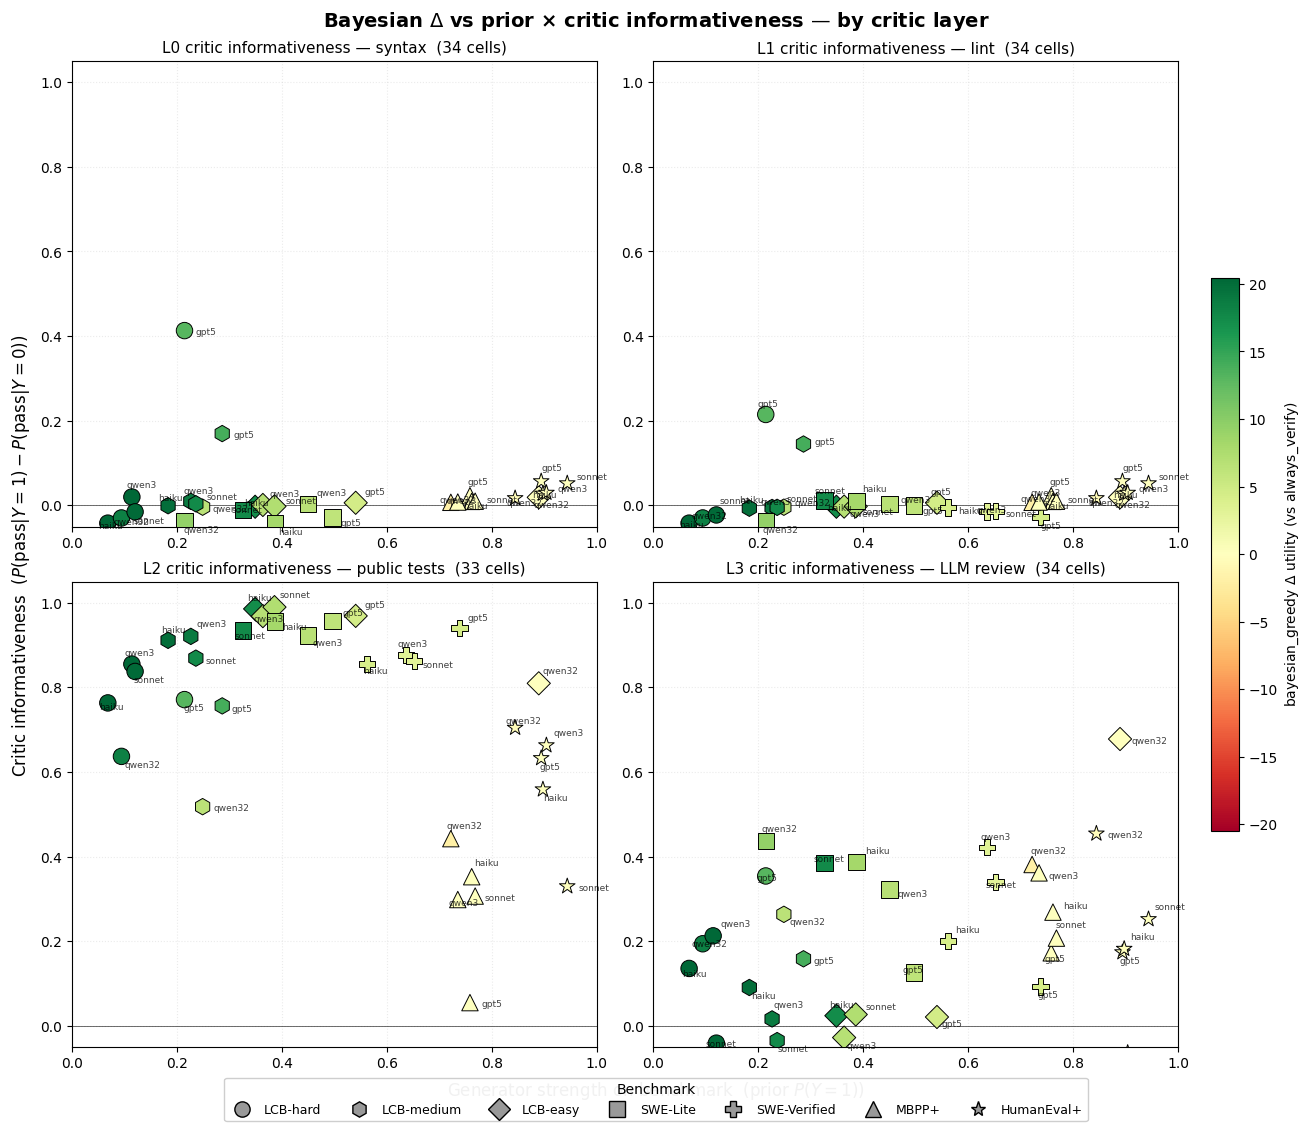

In [134]:
# %% §5 Bayesian Δ vs prior × critic informativeness — 2×2 critic grid
#    one panel per critic layer (L0 syntax / L1 lint / L2 public tests /
#    L3 LLM review). shape = benchmark, colour = bayesian_greedy Δ utility.
#    One per-axes panel function; shared colour scale / colorbar / legend.
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

# prior + critic gap come from §2's in-notebook recomputation (STAT_*),
# NOT the W&B summary parquet. (policy delta still from pc -- not a STAT_*.)
assert "STAT_PRIOR" in globals() and "STAT_LIK" in globals(), \
    "run §2 (Statistics recomputed from raw evidence) first"

# benchmark -> marker / label  (matches the deck's lcb_regime_map.py;
# W&B uses swe_lite/swe_verified, not swebench_*)
CELL_MARKER = {"lcb_hard": "o", "lcb_medium": "h", "lcb_easy": "D",
               "swe_lite": "s", "swe_verified": "P", "mbpp": "^",
               "humaneval": "*"}
CELL_LABEL  = {"lcb_hard": "LCB-hard", "lcb_medium": "LCB-medium",
               "lcb_easy": "LCB-easy", "swe_lite": "SWE-Lite",
               "swe_verified": "SWE-Verified", "mbpp": "MBPP+",
               "humaneval": "HumanEval+"}
GEN_SHORT   = {"gpt5_mini": "gpt5", "qwen3_coder": "qwen3", "haiku45": "haiku",
               "sonnet45": "sonnet", "qwen25_32b": "qwen32"}
_MATH = r"$P(\mathrm{pass}|Y{=}1) - P(\mathrm{pass}|Y{=}0)$"
# (critic, y-name, descriptor) -> one 2×2 panel each
CRITIC_PANELS = [
    ("L0_syntax",       "L0 critic informativeness", "syntax"),
    ("L1_lint",         "L1 critic informativeness", "lint"),
    ("L2_public_tests", "L2 critic informativeness", "public tests"),
    ("L3_llm_review",   "L3 critic informativeness", "LLM review"),
]

def _smart_offset(pt, neighbours):
    x, y = pt["prior"], pt["gap"]
    dxs = dys = 0.0
    for n in neighbours:
        if n is pt:
            continue
        dx, dy = x - n["prior"], y - n["gap"]
        d2 = dx * dx + dy * dy + 1e-6
        if d2 < 0.02:
            dxs += dx / d2; dys += dy / d2
    if abs(dxs) < 1e-9 and abs(dys) < 1e-9:
        return (8, -3)
    nrm = np.hypot(dxs, dys)
    return (int(round(8 * dxs / nrm)), int(round(8 * dys / nrm)))

def _critic_points(critic):
    """(prior, gap, bayesian_greedy Δ) points for one critic; [] if none."""
    _lk = (STAT_LIK[STAT_LIK.critic == critic]
           [["benchmark", "generator", "gap"]])
    cal = (STAT_PRIOR[["benchmark", "generator", "prior_Y1"]]
           .merge(_lk, on=["benchmark", "generator"], how="left")
           .set_index(["benchmark", "generator"]))
    joined = (pc.set_index(["benchmark", "generator"])[["delta"]]
              .join(cal[["prior_Y1", "gap"]]).dropna())
    return [{"cell": b, "generator": g, "prior": float(r.prior_Y1),
             "gap": float(r.gap), "diff": float(r.delta)}
            for (b, g), r in joined.iterrows()]

def _draw_regime_panel(ax, name, desc, points, norm, cmap):
    for ck, mk in CELL_MARKER.items():
        pts = [p for p in points if p["cell"] == ck]
        if not pts:
            continue
        ax.scatter([p["prior"] for p in pts], [p["gap"] for p in pts],
                   c=[p["diff"] for p in pts], cmap=cmap, norm=norm,
                   marker=mk, s=140, edgecolors="black", linewidths=0.7,
                   zorder=3)
    for p in points:
        ox, oy = _smart_offset(p, points)
        ax.annotate(GEN_SHORT.get(p["generator"], p["generator"]),
                    (p["prior"], p["gap"]), textcoords="offset points",
                    xytext=(ox, oy), fontsize=6.5, alpha=0.75, zorder=4)
    ax.set_title(f"{name} — {desc}  ({len(points)} cells)",
                 fontsize=11, pad=6)
    ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.25, linestyle=":", zorder=1); ax.set_axisbelow(True)
    ax.axhline(0, color="black", linewidth=0.4)

# gather every critic's points once -> one shared colour scale
ALL = {c: _critic_points(c) for c, _, _ in CRITIC_PANELS}
_alld = np.array([p["diff"] for c in ALL for p in ALL[c]])
if _alld.size == 0:
    print("§5: no (prior, gap, Δ) points available")
else:
    cap  = max(np.percentile(np.abs(_alld), 95), 5.0)
    norm = TwoSlopeNorm(vmin=-cap, vcenter=0, vmax=cap)
    cmap = plt.get_cmap("RdYlGn")

    fig, axes = plt.subplots(2, 2, figsize=(13, 11),
                             squeeze=False, constrained_layout=True)
    for idx, (critic, name, desc) in enumerate(CRITIC_PANELS):
        ax = axes[idx // 2][idx % 2]
        pts = ALL[critic]
        if pts:
            _draw_regime_panel(ax, name, desc, pts, norm, cmap)
        else:
            ax.set_title(f"{name} — {desc}  (no data)", fontsize=11)
            ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.05)

    if hasattr(fig, "supxlabel"):
        fig.supxlabel("Generator strength on benchmark  (prior $P(Y=1)$)",
                      fontsize=12)
        fig.supylabel(f"Critic informativeness  ({_MATH})", fontsize=12)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = fig.colorbar(sm, ax=axes.ravel().tolist(), fraction=0.025,
                        pad=0.02)
    cbar.set_label("bayesian_greedy $\\Delta$ utility (vs always_verify)",
                   fontsize=10)
    leg = [Line2D([0], [0], marker=CELL_MARKER[k], color="white",
                  markerfacecolor="#999", markeredgecolor="black",
                  markersize=11, label=CELL_LABEL[k]) for k in CELL_MARKER]
    fig.legend(handles=leg, loc="lower center", ncol=len(leg), fontsize=9,
               framealpha=0.95, title="Benchmark",
               bbox_to_anchor=(0.5, -0.02))
    fig.suptitle("Bayesian $\\Delta$ vs prior × critic informativeness "
                 "— by critic layer", fontsize=14, fontweight="bold")
    fig.savefig(CACHE / "fig6_critic_grid.png", dpi=150,
                bbox_inches="tight")
    plt.show()

## 6. Per-strategy Δ scatter — all benchmarks in a 2-column grid

Same axes as §5 (x = generator strength = prior $P(Y{=}1)$, y = L2 critic
informativeness = L2 gap), but instead of colouring by *one* strategy we draw
**every strategy's** Δ utility vs `always_verify`. One panel per benchmark,
laid out as a **2-column grid** — a single panel function is called per
benchmark (no per-benchmark cells). Within a panel each **strategy is a
distinct marker shape**; `(prior, L2_gap)` depends on `(benchmark, generator)`
only, so all strategy markers for a generator would coincide — they are
**fanned in a small rosette** around the true location (grey `+`). The colour
scale, colorbar and legend are **shared across the whole grid** (one global
symmetric `TwoSlopeNorm`) so panels are directly comparable — this differs
from the old per-figure independent scaling.


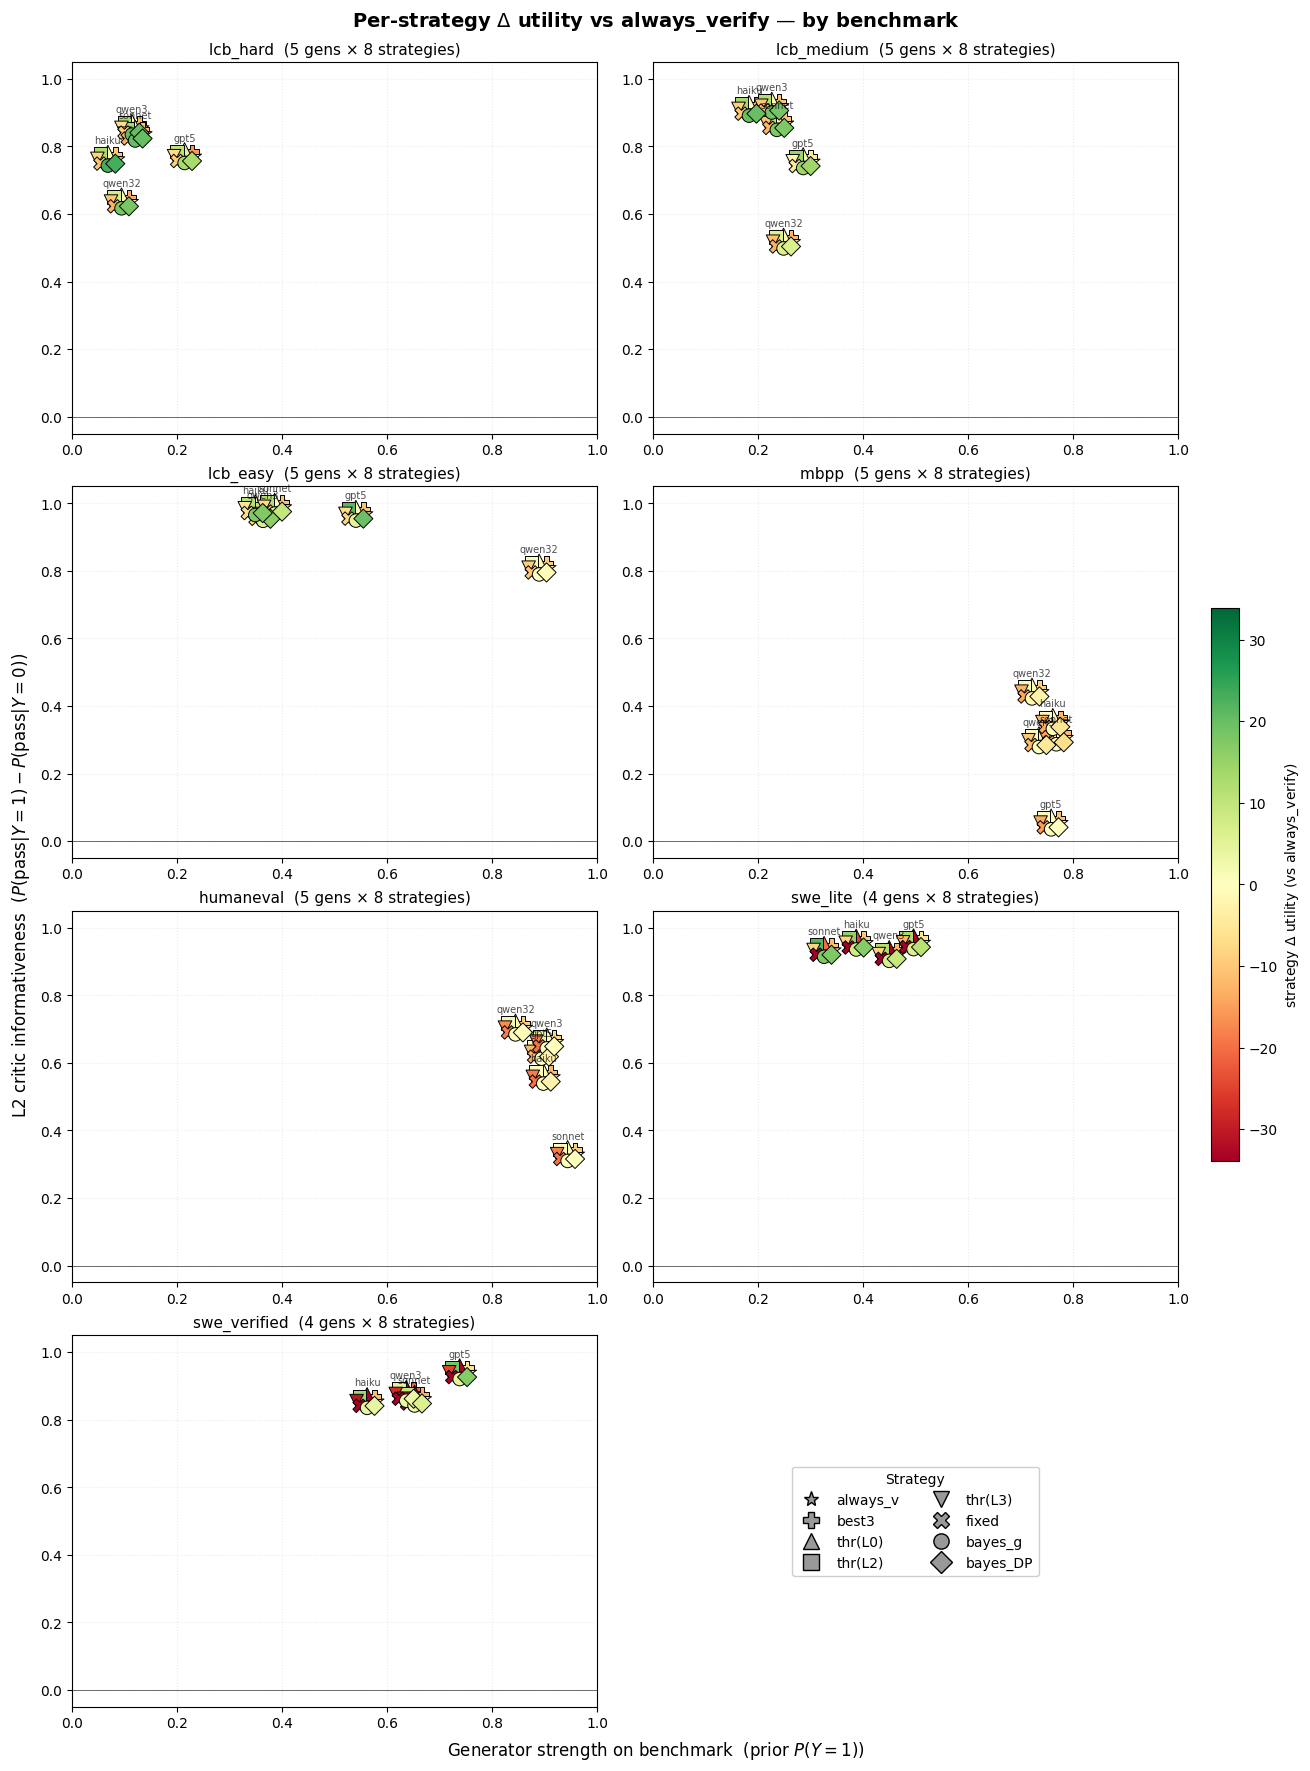

In [135]:
# %% §6 Per-strategy Δ scatter — one panel function, 2-column benchmark grid
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm
from matplotlib.lines import Line2D

assert "STAT_PRIOR" in globals() and "STAT_LIK" in globals(), \
    "run §2 (Statistics recomputed from raw evidence) first"

POLICY_MARKER = {"bayesian_greedy": "o", "bayesian_DP": "D", "threshold_L0": "^",
                 "threshold_L2": "s", "threshold_L3": "v", "best_of_3": "P",
                 "fixed_pipeline": "X", "always_verify": "*"}
POLICY_SHORT  = {"bayesian_greedy": "bayes_g", "bayesian_DP": "bayes_DP",
                 "threshold_L0": "thr(L0)", "threshold_L2": "thr(L2)",
                 "threshold_L3": "thr(L3)", "best_of_3": "best3",
                 "fixed_pipeline": "fixed", "always_verify": "always_v"}
GEN_SHORT2    = {"gpt5_mini": "gpt5", "qwen3_coder": "qwen3", "haiku45": "haiku",
                 "sonnet45": "sonnet", "qwen25_32b": "qwen32"}
BENCHES = ["lcb_hard", "lcb_medium", "lcb_easy", "mbpp", "humaneval",
           "swe_lite", "swe_verified"]

def _policy_points(bench, R=0.020):
    """Rosette points on (prior, L2_gap) for one benchmark. prior + L2 gap
    from §2 recomputation (STAT_*); per-strategy Δ stays from the wide pc."""
    _l2 = (STAT_LIK[(STAT_LIK.benchmark == bench) &
                    (STAT_LIK.critic == "L2_public_tests")]
           [["generator", "gap"]].rename(columns={"gap": "L2_gap"}))
    cal = (STAT_PRIOR[STAT_PRIOR.benchmark == bench][["generator", "prior_Y1"]]
           .merge(_l2, on="generator", how="left")
           .drop_duplicates("generator").set_index("generator"))
    sub = pc[pc.benchmark == bench].drop_duplicates("generator").set_index("generator")
    if sub.empty or cal.empty:
        return [], []
    pols = [p for p in POLICY_NAMES if f"{p}/delta_vs_av" in pc.columns]
    gens = [g for g in GEN_SHORT2 if g in sub.index and g in cal.index]
    pts = []
    for g in gens:
        pr, l2 = cal.loc[g, "prior_Y1"], cal.loc[g, "L2_gap"]
        if pd.isna(pr) or pd.isna(l2):
            continue
        row = sub.loc[g]
        for k, p in enumerate(pols):
            d = row[f"{p}/delta_vs_av"]
            if pd.isna(d):
                continue
            a = 2 * np.pi * k / len(pols)
            pts.append(dict(g=g, p=p, x0=float(pr), y0=float(l2),
                            x=float(pr) + R*np.cos(a),
                            y=float(l2) + R*np.sin(a), d=float(d)))
    return pts, pols

def _draw_panel(ax, bench, pts, pols, norm, cmap):
    for g in {q["g"] for q in pts}:
        x0 = next(q["x0"] for q in pts if q["g"] == g)
        y0 = next(q["y0"] for q in pts if q["g"] == g)
        ax.plot(x0, y0, marker="+", color="#888", ms=8, mew=1.0, zorder=2)
        ax.annotate(GEN_SHORT2.get(g, g), (x0, y0), textcoords="offset points",
                    xytext=(0, 11), ha="center", fontsize=7, alpha=0.7, zorder=4)
    for p in pols:
        qp = [q for q in pts if q["p"] == p]
        if not qp:
            continue
        ax.scatter([q["x"] for q in qp], [q["y"] for q in qp],
                   c=[q["d"] for q in qp], cmap=cmap, norm=norm,
                   marker=POLICY_MARKER[p], s=95,
                   edgecolors="black", linewidths=0.7, zorder=3)
    ng = len({q["g"] for q in pts})
    ax.set_title(f"{bench}  ({ng} gens × {len(pols)} strategies)",
                 fontsize=11, pad=6)
    ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.25, linestyle=":"); ax.set_axisbelow(True)
    ax.axhline(0, color="black", linewidth=0.4)

# gather every benchmark's points once -> one shared colour scale
ALL = {b: _policy_points(b) for b in BENCHES}
_alld = np.array([q["d"] for b in BENCHES for q in ALL[b][0]])
if _alld.size == 0:
    print("§6: no per-strategy points available")
else:
    cap  = max(np.percentile(np.abs(_alld), 95), 5.0)
    norm = TwoSlopeNorm(vmin=-cap, vcenter=0, vmax=cap)
    cmap = plt.get_cmap("RdYlGn")
    pols_all = next((ALL[b][1] for b in BENCHES if ALL[b][1]), [])

    ncol = 2
    nrow = -(-len(BENCHES) // ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 4.4 * nrow),
                             squeeze=False, constrained_layout=True)
    for idx, b in enumerate(BENCHES):
        ax = axes[idx // ncol][idx % ncol]
        pts, pols = ALL[b]
        if pts:
            _draw_panel(ax, b, pts, pols, norm, cmap)
        else:
            ax.set_title(f"{b}  (no data)", fontsize=11)
            ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.05)
    panel_axes = axes.ravel()[:len(BENCHES)].tolist()
    leg_ax = (axes.ravel()[len(BENCHES)]
              if nrow * ncol > len(BENCHES) else None)
    for j in range(len(BENCHES), nrow * ncol):
        axes[j // ncol][j % ncol].axis("off")

    if hasattr(fig, "supxlabel"):
        fig.supxlabel("Generator strength on benchmark  (prior $P(Y=1)$)",
                      fontsize=12)
        fig.supylabel("L2 critic informativeness  "
                      "($P(\\mathrm{pass}|Y{=}1) - P(\\mathrm{pass}|Y{=}0)$)",
                      fontsize=12)
    sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm); sm.set_array([])
    cbar = fig.colorbar(sm, ax=panel_axes, fraction=0.025, pad=0.02)
    cbar.set_label("strategy $\\Delta$ utility (vs always_verify)", fontsize=10)
    leg = [Line2D([0], [0], marker=POLICY_MARKER[p], color="white",
                  markerfacecolor="#999", markeredgecolor="black",
                  markersize=11, label=POLICY_SHORT[p]) for p in pols_all]
    if leg_ax is not None:
        leg_ax.legend(handles=leg, loc="center", ncol=2, fontsize=10,
                      framealpha=0.95, title="Strategy")
    else:
        fig.legend(handles=leg, loc="lower center", ncol=4, fontsize=9,
                   framealpha=0.95, title="Strategy")
    fig.suptitle("Per-strategy $\\Delta$ utility vs always_verify "
                 "— by benchmark", fontsize=14, fontweight="bold")
    fig.savefig(CACHE / "fig7_per_strategy_grid.png", dpi=150,
                bbox_inches="tight")
    plt.show()

### 6b. The (prior, L2-gap) location depends on (benchmark, generator) only

In the §6 grid each generator shows a rosette of eight strategy markers.
That fan is **purely cosmetic**: `(prior, L2_gap)` is a function of
`(benchmark, generator)` **alone** — it does not depend on the strategy. All
eight strategy markers for a generator sit at *exactly the same* point; §6
spreads them on a tiny circle only so the shapes do not overlap, and encodes
each strategy's Δ in colour. The companion grid below removes the strategy
dimension entirely — **one point per generator** at its true location — so
the bare (benchmark, generator) structure is visible without the rosette.


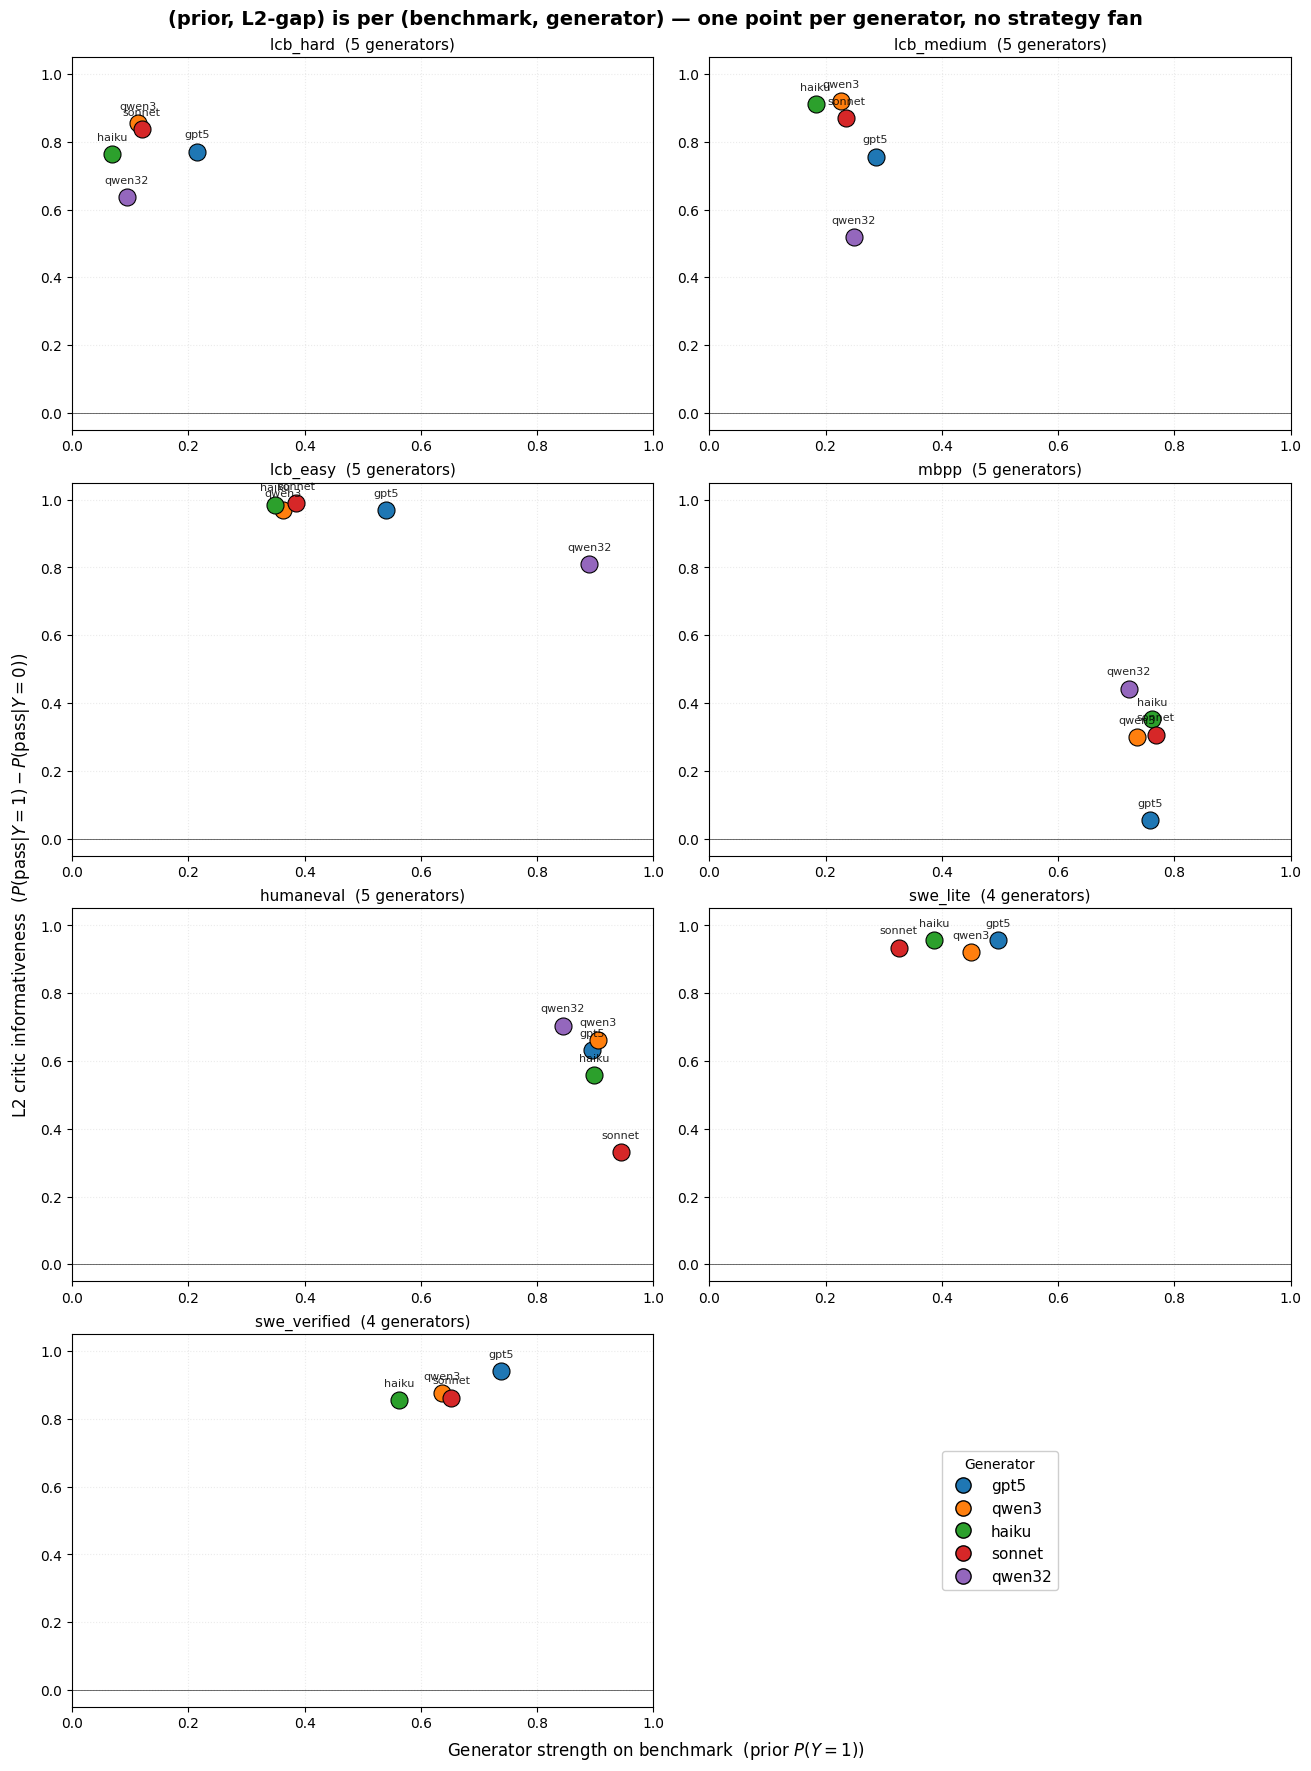

In [136]:
# %% §6b Generator locations only — same benchmark grid, no strategy fan
#    Emphasises that (prior, L2_gap) is a function of (benchmark, generator)
#    ONLY: one point per generator at its true location (no policy rosette,
#    no Δ colour). Compare directly with the §6 grid above.
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

assert "STAT_PRIOR" in globals() and "STAT_LIK" in globals(), \
    "run §2 (Statistics recomputed from raw evidence) first"

GEN_SHORT2 = {"gpt5_mini": "gpt5", "qwen3_coder": "qwen3", "haiku45": "haiku",
              "sonnet45": "sonnet", "qwen25_32b": "qwen32"}
GEN_COLOR  = {"gpt5_mini": "#1f77b4", "qwen3_coder": "#ff7f0e",
              "haiku45": "#2ca02c", "sonnet45": "#d62728",
              "qwen25_32b": "#9467bd"}
BENCHES = ["lcb_hard", "lcb_medium", "lcb_easy", "mbpp", "humaneval",
           "swe_lite", "swe_verified"]

def _gen_points(bench):
    """One (prior, L2_gap) per generator for this benchmark. Depends on
    (benchmark, generator) ONLY -- no strategy, no Δ, no pc."""
    _l2 = (STAT_LIK[(STAT_LIK.benchmark == bench) &
                    (STAT_LIK.critic == "L2_public_tests")]
           [["generator", "gap"]].rename(columns={"gap": "L2_gap"}))
    cal = (STAT_PRIOR[STAT_PRIOR.benchmark == bench][["generator", "prior_Y1"]]
           .merge(_l2, on="generator", how="left")
           .drop_duplicates("generator").set_index("generator"))
    out = []
    for g in GEN_SHORT2:
        if g not in cal.index:
            continue
        pr, l2 = cal.loc[g, "prior_Y1"], cal.loc[g, "L2_gap"]
        if pd.isna(pr) or pd.isna(l2):
            continue
        out.append((g, float(pr), float(l2)))
    return out

def _draw_gen_panel(ax, bench, pts):
    for g, pr, l2 in pts:
        ax.scatter([pr], [l2], c=GEN_COLOR.get(g, "#888"), s=150,
                   marker="o", edgecolors="black", linewidths=0.8, zorder=3)
        ax.annotate(GEN_SHORT2.get(g, g), (pr, l2),
                    textcoords="offset points", xytext=(0, 10),
                    ha="center", fontsize=8, alpha=0.85, zorder=4)
    ax.set_title(f"{bench}  ({len(pts)} generators)", fontsize=11, pad=6)
    ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.05)
    ax.grid(alpha=0.25, linestyle=":"); ax.set_axisbelow(True)
    ax.axhline(0, color="black", linewidth=0.4)

ALL = {b: _gen_points(b) for b in BENCHES}
if not any(ALL.values()):
    print("§6b: no (prior, L2_gap) points available")
else:
    ncol = 2
    nrow = -(-len(BENCHES) // ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 4.4 * nrow),
                             squeeze=False, constrained_layout=True)
    for idx, b in enumerate(BENCHES):
        ax = axes[idx // ncol][idx % ncol]
        pts = ALL[b]
        if pts:
            _draw_gen_panel(ax, b, pts)
        else:
            ax.set_title(f"{b}  (no data)", fontsize=11)
            ax.set_xlim(0, 1); ax.set_ylim(-0.05, 1.05)
    leg_ax = (axes.ravel()[len(BENCHES)]
              if nrow * ncol > len(BENCHES) else None)
    for j in range(len(BENCHES), nrow * ncol):
        axes[j // ncol][j % ncol].axis("off")

    if hasattr(fig, "supxlabel"):
        fig.supxlabel("Generator strength on benchmark  (prior $P(Y=1)$)",
                      fontsize=12)
        fig.supylabel("L2 critic informativeness  "
                      "($P(\\mathrm{pass}|Y{=}1) - P(\\mathrm{pass}|Y{=}0)$)",
                      fontsize=12)
    leg = [Line2D([0], [0], marker="o", color="white",
                  markerfacecolor=GEN_COLOR[g], markeredgecolor="black",
                  markersize=11, label=GEN_SHORT2[g]) for g in GEN_SHORT2]
    if leg_ax is not None:
        leg_ax.legend(handles=leg, loc="center", ncol=1, fontsize=11,
                      framealpha=0.95, title="Generator")
    else:
        fig.legend(handles=leg, loc="lower center", ncol=len(leg),
                   fontsize=9, framealpha=0.95, title="Generator")
    fig.suptitle("(prior, L2-gap) is per (benchmark, generator) — "
                 "one point per generator, no strategy fan",
                 fontsize=14, fontweight="bold")
    fig.savefig(CACHE / "fig7b_generator_locations.png", dpi=150,
                bbox_inches="tight")
    plt.show()

## 7. Per-cell winner matrix

Winner = `idxmax` of `delta_vs_av` over the eight policies (in
`POLICY_NAMES` order, so exact ties go to the earlier / simpler policy).
The **first** cell is the canonical matrix at the §2.5 cost. The **second**
sweeps R × c_ver with the *same* winner rule and the *same* recomputed
likelihoods, so its **R=100, c_ver=30** panel is the canonical matrix
cell-for-cell (it is boxed in red).


Per-cell winner:
generator           gpt5_mini          haiku45       qwen25_32b  \
benchmark                                                         
humaneval        threshold_L2    always_verify     threshold_L2   
lcb_easy         threshold_L2  bayesian_greedy     threshold_L2   
lcb_hard      bayesian_greedy  bayesian_greedy  bayesian_greedy   
lcb_medium       threshold_L2  bayesian_greedy  bayesian_greedy   
mbpp            always_verify     threshold_L2     threshold_L2   
swe_lite         threshold_L2      bayesian_DP  bayesian_greedy   
swe_verified     threshold_L2     threshold_L2    always_verify   

generator         qwen3_coder         sonnet45  
benchmark                                       
humaneval        threshold_L2    always_verify  
lcb_easy          bayesian_DP     threshold_L2  
lcb_hard      bayesian_greedy  bayesian_greedy  
lcb_medium    bayesian_greedy  bayesian_greedy  
mbpp             threshold_L2    always_verify  
swe_lite         threshold_L2     th

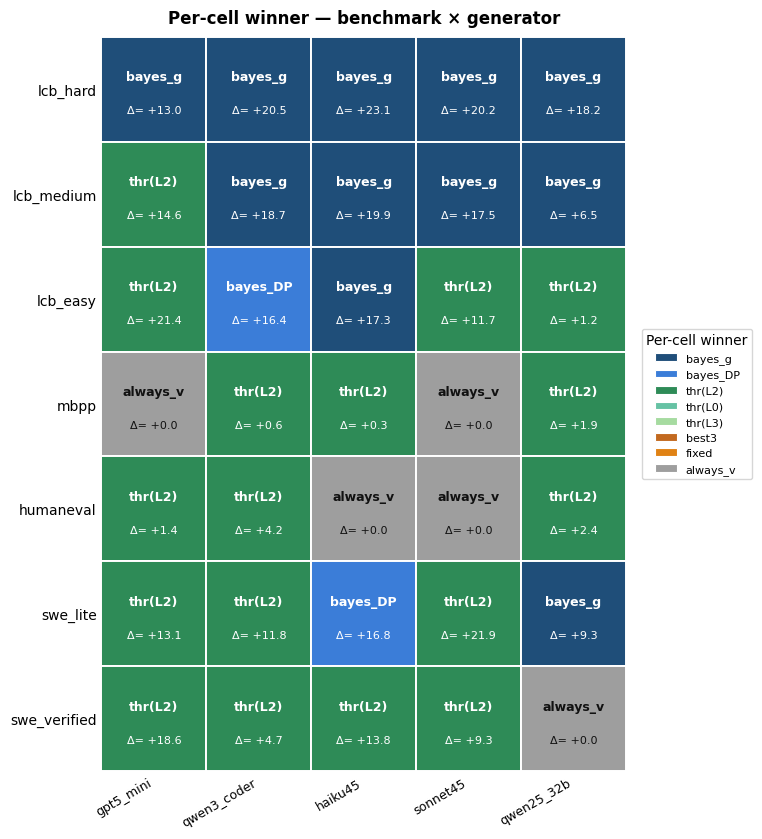

In [137]:
# %% Winner matrix
policy_cols = [f"{p}/delta_vs_av" for p in POLICY_NAMES]
available_policy_cols = [c for c in policy_cols if c in pc.columns]

pc["winner"] = pc[available_policy_cols].idxmax(axis=1).str.replace("/delta_vs_av", "", regex=False)
pc["winner_delta"] = pc[available_policy_cols].max(axis=1)

matrix = pc.pivot_table(index="benchmark", columns="generator",
                        values="winner", aggfunc="first")
delta_matrix = pc.pivot_table(index="benchmark", columns="generator",
                               values="winner_delta", aggfunc="first")
print("Per-cell winner:")
print(matrix)
print("\nΔ at winner:")
print(delta_matrix.round(2))

# --- deck-style winner-matrix figure ---
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
BENCH_ORDER = ["lcb_hard","lcb_medium","lcb_easy","mbpp","humaneval","swe_lite","swe_verified"]
GEN_ORDER   = ["gpt5_mini","qwen3_coder","haiku45","sonnet45","qwen25_32b"]
# Family-coherent palette, consistent with the §12 bars (Bayesian=blue,
# threshold=green, best/fixed=orange, always_verify=grey) but saturated for
# print. threshold_L2 kept distinct from L0/L3 — it is its own regime.
POLICY_COLOR = {"bayesian_greedy":"#1f4e79","bayesian_DP":"#3b7dd8",
                "threshold_L2":"#2e8b57","threshold_L0":"#66c2a4",
                "threshold_L3":"#a6dba0","best_of_3":"#c2691f",
                "fixed_pipeline":"#e08214","always_verify":"#9e9e9e"}
SHORT = {"bayesian_greedy":"bayes_g","bayesian_DP":"bayes_DP","threshold_L0":"thr(L0)",
         "threshold_L2":"thr(L2)","threshold_L3":"thr(L3)","best_of_3":"best3",
         "fixed_pipeline":"fixed","always_verify":"always_v"}

def _txt(hexcol):
    """Black or white text, whichever has more contrast on `hexcol`."""
    h = hexcol.lstrip("#"); r, g, b = (int(h[i:i+2], 16) for i in (0, 2, 4))
    return "white" if (0.299*r + 0.587*g + 0.114*b) < 150 else "#111111"
benches = [b for b in BENCH_ORDER if b in set(pc.benchmark)]
gens    = [g for g in GEN_ORDER   if g in set(pc.generator)]
fig, ax = plt.subplots(figsize=(1.5*len(gens)+2, 1.0*len(benches)+1.5))
for bi, b in enumerate(benches):
    for gi, g in enumerate(gens):
        row = pc[(pc.benchmark==b) & (pc.generator==g)]
        y = len(benches)-1-bi
        if row.empty:
            ax.add_patch(Rectangle((gi,y),1,1,facecolor="#ededed",
                                   edgecolor="#bbbbbb",lw=1.2,hatch="///"))
            continue
        w  = row.winner.iloc[0]; dv = row.winner_delta.iloc[0]
        face = POLICY_COLOR.get(w, "#cccccc"); tc = _txt(face)
        ax.add_patch(Rectangle((gi,y),1,1,facecolor=face,
                               edgecolor="white",lw=1.4))
        ax.text(gi+0.5,y+0.62,SHORT.get(w,w),ha="center",va="center",
                fontsize=9,fontweight="bold",color=tc)
        ax.text(gi+0.5,y+0.30,f"Δ= {dv:+.1f}",ha="center",va="center",
                fontsize=8,color=tc)
ax.set_xlim(0,len(gens)); ax.set_ylim(0,len(benches)); ax.set_aspect("equal")
ax.set_xticks([i+0.5 for i in range(len(gens))])
ax.set_xticklabels(gens,rotation=30,ha="right",fontsize=9)
ax.set_yticks([len(benches)-1-i+0.5 for i in range(len(benches))])
ax.set_yticklabels(benches,fontsize=10)
ax.tick_params(length=0)
for s in ax.spines.values(): s.set_visible(False)
leg_keys = ["bayesian_greedy","bayesian_DP","threshold_L2","threshold_L0",
            "threshold_L3","best_of_3","fixed_pipeline","always_verify"]
leg = [Rectangle((0,0),1,1,facecolor=POLICY_COLOR[k],edgecolor="white",lw=0.8)
       for k in leg_keys]
ax.legend(leg,[SHORT[k] for k in leg_keys],
          loc="center left",bbox_to_anchor=(1.02,0.5),title="Per-cell winner",
          fontsize=8,frameon=True)
ax.set_title("Per-cell winner — benchmark × generator", fontsize=12, fontweight="bold", pad=10)
plt.tight_layout(); plt.show()


loaded 35 cells; KERN_MEAS covers 18 (measured single_method kernel; rest = run_policies IID DP, as §3)


Winner grid (one §3 method, every panel):   0%|          | 0/16 [00:00<?, ?panel/s]

tripwire OK: recomputed R=100,c_ver=30 panel == §7 pc winners, 35/35 cells (one method, n_boot=1)


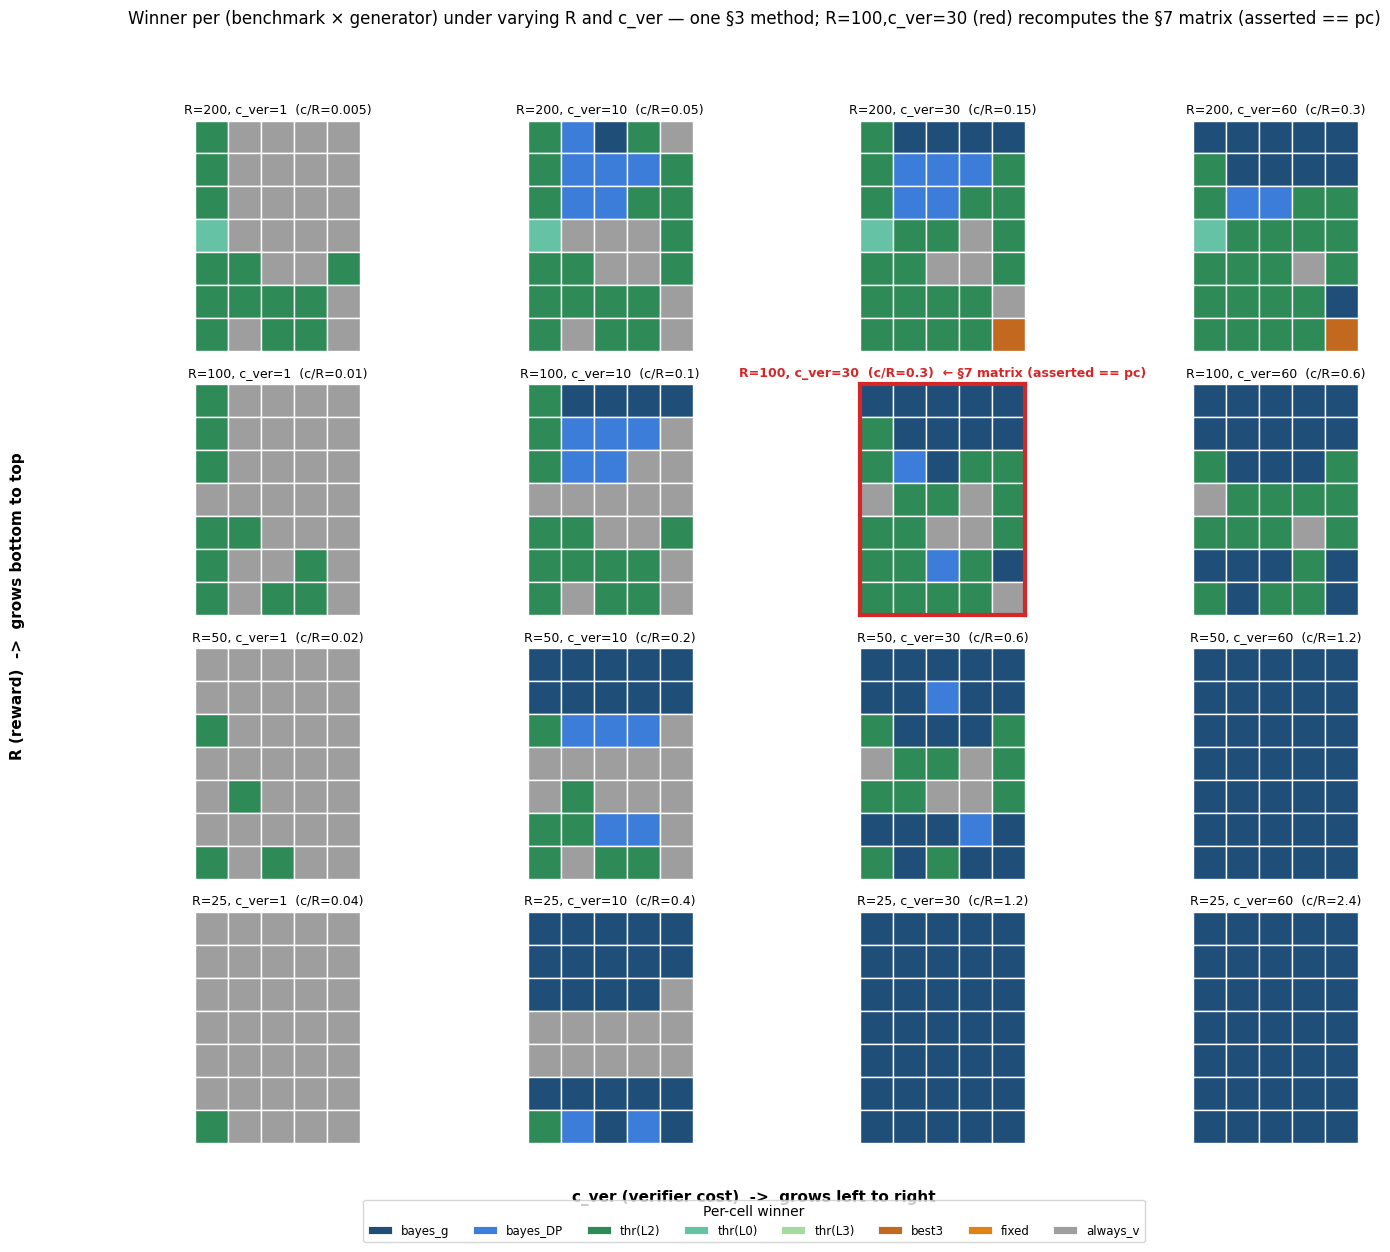

In [138]:
# %% §7 Winner grid over R × c_ver — one §3 method for every panel
#
# ONE method, reused from §3 (no reimplementation, NO special-casing):
# every panel -- including R=100,c_ver=30 -- is recomputed identically:
# run_policies for the 7 non-DP policies + §3's own _measured_dp_row /
# KERN_MEAS for bayesian_DP (measured single_method kernel where it exists,
# else run_policies' IID DP -- exactly §3's branch); winner = §7's
# idxmax(delta_vs_av) in POLICY_NAMES order. paired_bootstrap_ci's point
# estimate is the EXACT mean diff (only the CI uses n_boot), so the argmax
# winner is n_boot-independent: n_boot=1 here == §3's N_BOOT=1000. A
# tripwire then asserts the recomputed R=100,c_ver=30 panel == §7's pc
# winners cell-for-cell -- so it IS the §7 matrix, proven by the method
# (fail loud on drift), NOT copied from pc.
import sys
from pathlib import Path
import numpy as np, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **kw): return x

assert all(n in globals() for n in
           ("pc", "KERN_MEAS", "_measured_dp_row", "POLICY_NAMES")), \
    ("run §3 (Policy utilities) + §7 first — this grid reuses their "
     "canonical pc and measured-kernel DP machinery (KERN_MEAS / "
     "_measured_dp_row); it does not reimplement them.")

R_VALUES    = [25, 50, 100, 200]
CVER_VALUES = [1, 10, 30, 60]
CANON_R, CANON_CVER = 100, 30          # == §2.5 canonical cost == §7 matrix
BENCH_ORDER = ["lcb_hard", "lcb_medium", "lcb_easy", "mbpp", "humaneval",
               "swe_lite", "swe_verified"]
GEN_ORDER   = ["gpt5_mini", "qwen3_coder", "haiku45", "sonnet45", "qwen25_32b"]

NB_DIR  = Path(".").resolve()
SCRIPTS = (Path("../../orchestration_hypothesis_testing/scripts")).resolve()
for _p in (str(NB_DIR), str(SCRIPTS)):
    if _p not in sys.path:
        sys.path.insert(0, _p)
from upload_runs import compute_likelihoods_from_critic_results  # noqa: E402
from run_baseline_vs_controller import CostModel                 # noqa: E402
from lcb_sensitivity import run_policies                          # noqa: E402
from lcb_compare import load_lcb_trajectories                     # noqa: E402

def _winner_from_res(res):
    """§7's exact rule: idxmax of delta_vs_av in POLICY_NAMES order
    (== pc[cols].idxmax(axis=1); ties -> the earlier / simpler policy)."""
    pols = [p for p in POLICY_NAMES if p in res]
    mx = max(res[p]["diff_vs_baseline"] for p in pols)
    return next(p for p in pols if res[p]["diff_vs_baseline"] == mx)

# --- cells: recompute likelihoods from the §2.0 raw-evidence cache ---
RAW = CACHE / "raw_evidence"
CELLS = {}
for d in sorted(RAW.glob("calib__*")):
    cr = d / "critic_results.jsonl"
    if not cr.exists():
        continue
    b, g = d.name[len("calib__"):].rsplit("__", 1)
    lk = compute_likelihoods_from_critic_results(cr)
    if lk is None:
        continue
    lk["critic_likelihoods"] = {k: v for k, v in lk["critic_likelihoods"].items()
        if v.get("P_pass_given_Y1") is not None
        and v.get("P_pass_given_Y0") is not None}
    CELLS[(b, g)] = (load_lcb_trajectories(cr), lk, lk["prior_Y1"])
assert CELLS, "run §2.0 first (it populates .cache/raw_evidence)"
print(f"loaded {len(CELLS)} cells; KERN_MEAS covers {len(KERN_MEAS)} "
      f"(measured single_method kernel; rest = run_policies IID DP, as §3)")

# ONE method for ALL 16 panels -- canonical panel is NOT special-cased.
winners = {}
_combos = [(R, cv) for R in R_VALUES for cv in CVER_VALUES]
for R, cv in tqdm(_combos, desc="Winner grid (one §3 method, every panel)",
                  unit="panel"):
    cost = CostModel(c_gen=5, c_L0=1, c_L2=2, c_L3=5, c_ver=cv, reward=R)
    wm = {}
    for (b, g), (tr, lk, pr) in CELLS.items():
        try:
            res = run_policies(tr, lk, pr, cost, n_boot=1)
            if (b, g) in KERN_MEAS:                  # §3's measured-kernel DP
                res["bayesian_DP"] = _measured_dp_row(
                    tr, lk, pr, KERN_MEAS[(b, g)], cost, 1)
            wm[(b, g)] = _winner_from_res(res)
        except Exception as e:
            print(f"  skip {b}/{g} R={R} cv={cv}: {e}")
    winners[(R, cv)] = wm

# Tripwire (NOT a substitution): the canonical panel, recomputed by the one
# method above, must equal §7's pc winners cell-for-cell. paired_bootstrap_ci
# returns the exact mean diff, so n_boot=1 here == §3's N_BOOT=1000 for the
# argmax; same likelihoods/trajectories/cost/DP machinery/rule => exact.
# If this ever fails the grid method has drifted from §3/§7 -- fail loudly.
_acols = [f"{p}/delta_vs_av" for p in POLICY_NAMES
          if f"{p}/delta_vs_av" in pc.columns]
_pcw = {(r.benchmark, r.generator): w for r, w in zip(
        pc.itertuples(),
        pc[_acols].idxmax(axis=1).str.replace("/delta_vs_av", "",
                                              regex=False))}
_canon = winners[(CANON_R, CANON_CVER)]
_bad = {k: (_canon.get(k), _pcw.get(k)) for k in set(_pcw) | set(_canon)
        if _canon.get(k) != _pcw.get(k)}
assert not _bad, ("canonical panel != §7 pc -- grid method has drifted "
                  f"from §3/§7 (NOT a render glitch): {_bad}")
print(f"tripwire OK: recomputed R={CANON_R},c_ver={CANON_CVER} panel == §7 "
      f"pc winners, {len(_pcw)}/{len(_pcw)} cells (one method, n_boot=1)")

# palette identical to the §7 winner matrix (cell 29)
PC = {"bayesian_greedy": "#1f4e79", "bayesian_DP": "#3b7dd8",
      "threshold_L2": "#2e8b57", "threshold_L0": "#66c2a4",
      "threshold_L3": "#a6dba0", "best_of_3": "#c2691f",
      "fixed_pipeline": "#e08214", "always_verify": "#9e9e9e"}
SHORT = {"bayesian_greedy": "bayes_g", "bayesian_DP": "bayes_DP",
         "threshold_L2": "thr(L2)", "threshold_L0": "thr(L0)",
         "threshold_L3": "thr(L3)", "best_of_3": "best3",
         "fixed_pipeline": "fixed", "always_verify": "always_v"}
nB, nG = len(BENCH_ORDER), len(GEN_ORDER)
fig, axes = plt.subplots(len(R_VALUES), len(CVER_VALUES), figsize=(15, 12))
for ri, R in enumerate(reversed(R_VALUES)):
    for ci, cv in enumerate(CVER_VALUES):
        ax = axes[ri][ci]; wm = winners.get((R, cv), {})
        for bi, b in enumerate(BENCH_ORDER):
            for gi, g in enumerate(GEN_ORDER):
                w = wm.get((b, g))
                ax.add_patch(Rectangle((gi, nB - 1 - bi), 1, 1,
                    facecolor=PC.get(w, "#ffffff") if w else "#ededed",
                    edgecolor="white", lw=1.0, hatch=None if w else "///"))
        ax.set_xlim(0, nG); ax.set_ylim(0, nB); ax.set_aspect("equal")
        ax.set_xticks([]); ax.set_yticks([])
        is_canon = (R == CANON_R and cv == CANON_CVER)
        for s in ax.spines.values():
            s.set_visible(is_canon)
            if is_canon:
                s.set_edgecolor("#d62728"); s.set_linewidth(3.0)
        ttl = f"R={R}, c_ver={cv}  (c/R={cv / R:.2g})"
        if is_canon:
            ttl += "  ← §7 matrix (asserted == pc)"
        ax.set_title(ttl, fontsize=9,
                     fontweight="bold" if is_canon else "normal",
                     color="#d62728" if is_canon else "black")
fig.text(0.5, 0.004, "c_ver (verifier cost)  ->  grows left to right",
         ha="center", fontsize=11, fontweight="bold")
fig.text(0.004, 0.5, "R (reward)  ->  grows bottom to top",
         va="center", rotation=90, fontsize=11, fontweight="bold")
leg_keys = ["bayesian_greedy", "bayesian_DP", "threshold_L2", "threshold_L0",
            "threshold_L3", "best_of_3", "fixed_pipeline", "always_verify"]
handles = [Rectangle((0, 0), 1, 1, facecolor=PC[k], edgecolor="white",
                     lw=0.6) for k in leg_keys]
fig.legend(handles, [SHORT[k] for k in leg_keys], loc="lower center",
           ncol=8, fontsize=8.5, frameon=True, bbox_to_anchor=(0.5, -0.035),
           title="Per-cell winner")
fig.suptitle("Winner per (benchmark × generator) under varying R and c_ver "
             "— one §3 method; R=100,c_ver=30 (red) recomputes the §7 matrix "
             "(asserted == pc)", fontsize=12, y=0.997)
fig.tight_layout(rect=[0.03, 0.04, 1, 0.96])
fig.savefig(CACHE / "fig8_winner_grid_R_cver.png", dpi=150,
            bbox_inches="tight")
plt.show()

### The §7 grid is itself the four regimes (read by colour)

Each panel above is already a four-regime map — the per-policy palette *is*
the regime, resolved per (benchmark, generator) and per cost point:

- **Bayesian wins** → `bayes_g` (dark blue) + `bayes_DP` (blue) — regime **A**
- **threshold wins** → `thr(L2)` / `thr(L0)` / `thr(L3)` (green) — regime **B**
- **always-verify wins** → `always_v` (grey) — regime **C**
- **other wins** → `best3` / `fixed` (orange) — regime **O**

So the grid sweeps the same A/B/C/O structure that §14 draws as smoothed
decision regions — here resolved cell-by-cell instead of as continuous
regions (and with Bayesian split into greedy vs DP by shade).


## 8. Iter trajectories — measured kernel per (benchmark, gen, method)

In [139]:
# %% Iter kernels
assert "STAT_KERNEL" in globals(), "run §2 (Statistics recomputed from raw evidence) first"
# Transition kernel from §2's in-notebook recomputation of raw iter_records.jsonl,
# NOT the W&B summary parquet.
kernel_table = STAT_KERNEL.pivot_table(
    index=["benchmark", "generator"], columns="method",
    values="P_fix", aggfunc="first")
print("P(fix | broken) per (benchmark, generator, method)  [recomputed from raw]:")
print(kernel_table.round(3))


P(fix | broken) per (benchmark, generator, method)  [recomputed from raw]:
method                    reflexion  selfrefine  single_method
benchmark    generator                                        
lcb_easy     gpt5_mini        0.129       0.074          0.529
             haiku45          0.232       0.007          0.010
             qwen25_32b       0.074       0.133            NaN
             qwen3_coder      0.022       0.013          0.011
             sonnet45         0.086       0.008          0.117
lcb_hard     gpt5_mini        0.023       0.065          0.012
             haiku45          0.010       0.015          0.039
             qwen25_32b       0.011       0.023            NaN
             qwen3_coder      0.032       0.016          0.020
             sonnet45         0.024       0.010          0.045
lcb_medium   gpt5_mini        0.044       0.082          0.100
             haiku45          0.031       0.007          0.031
             qwen25_32b       0.009       0

## 9. Framework vs Self-Refine / Reflexion baselines

Bayesian best variant Δ vs published baselines (real implementations, not replay).

In [140]:
# %% Framework vs published baselines
assert "STAT_KERNEL" in globals(), "run §2 (Statistics) first"
# Self-Refine / Reflexion transition kernels, recomputed from raw
# iter_records.jsonl in §2 (not the W&B summary parquet).
rb = STAT_KERNEL[STAT_KERNEL.method.isin(["selfrefine", "reflexion"])].copy()
if rb.empty:
    print("No Self-Refine / Reflexion kernel cells.")
else:
    print("P_fix per (bench, gen, method)  [recomputed from raw]:")
    rb_table = rb.pivot_table(index=["benchmark", "generator"],
                              columns="method", values="P_fix")
    print(rb_table.round(3))


P_fix per (bench, gen, method)  [recomputed from raw]:
method                    reflexion  selfrefine
benchmark    generator                         
lcb_easy     gpt5_mini        0.129       0.074
             haiku45          0.232       0.007
             qwen25_32b       0.074       0.133
             qwen3_coder      0.022       0.013
             sonnet45         0.086       0.008
lcb_hard     gpt5_mini        0.023       0.065
             haiku45          0.010       0.015
             qwen25_32b       0.011       0.023
             qwen3_coder      0.032       0.016
             sonnet45         0.024       0.010
lcb_medium   gpt5_mini        0.044       0.082
             haiku45          0.031       0.007
             qwen25_32b       0.009       0.030
             qwen3_coder      0.026       0.015
             sonnet45         0.020       0.013
swe_lite     gpt5_mini        0.118       0.055
             haiku45          0.160       0.062
             qwen25_32b       0.1

## 10. Re-export tables to CSV for paper

Three CSVs ready to paste into the paper's tables:
- `paper_table.csv` — main cube
- `regime_summary.csv` — counts per regime × winner
- `kernel_summary.csv` — measured P_fix per cell

In [141]:
# %% Export paper tables
OUT = CACHE / "paper_tables"
OUT.mkdir(exist_ok=True)

# 1. Paper table
cols_to_keep = ["benchmark", "generator", "kernel_source", "winner", "winner_delta"]
for p in POLICY_NAMES:
    for s in ("delta_vs_av", "ci95_lo", "ci95_hi"):
        cols_to_keep.append(f"{p}/{s}")
paper = pc[[c for c in cols_to_keep if c in pc.columns]].copy()
paper.to_csv(OUT / "paper_table.csv", index=False)
print(f"Wrote {OUT / 'paper_table.csv'} ({len(paper)} rows)")

# 2. Regime summary
pc["regime"] = pc.benchmark.map(REGIME_BY_BENCH)
regime = pc.groupby(["regime", "winner"]).size().reset_index(name="n")
regime.to_csv(OUT / "regime_summary.csv", index=False)
print(f"Wrote {OUT / 'regime_summary.csv'}")
print(regime)

# 3. Kernel summary  (recomputed kernel from §2 -- raw iter_records.jsonl)
if "STAT_KERNEL" in globals() and not STAT_KERNEL.empty:
    kernel_summary = STAT_KERNEL[["benchmark", "generator", "method",
                                  "P_fix", "P_break", "n_pairs",
                                  "fix_ci_lo", "fix_ci_hi", "IID_P_fix"]]
    kernel_summary.to_csv(OUT / "kernel_summary.csv", index=False)
    print(f"Wrote {OUT / 'kernel_summary.csv'} ({len(kernel_summary)} rows, recomputed)")

Wrote .cache/paper_tables/paper_table.csv (35 rows)
Wrote .cache/paper_tables/regime_summary.csv
  regime           winner   n
0      A      bayesian_DP   1
1      A  bayesian_greedy  10
2      A     threshold_L2   4
3      B    always_verify   1
4      B      bayesian_DP   1
5      B  bayesian_greedy   1
6      B     threshold_L2   7
7      C    always_verify   4
8      C     threshold_L2   6
Wrote .cache/paper_tables/kernel_summary.csv (68 rows, recomputed)


## 11. Sanity checks

Cross-reference with `data/PAPER_TABLE.{json,csv}` if it's locally available.

In [142]:
# %% Sanity check vs local PAPER_TABLE
local_pt_csv = Path("../data/PAPER_TABLE.csv")
if local_pt_csv.exists():
    local = pd.read_csv(local_pt_csv)
    print(f"Local PAPER_TABLE: {len(local)} rows")
    # Spot-check: bayesian_greedy delta on lcb_hard / gpt5_mini
    cell_local = local[(local.cell == "lcb_hard") & (local.generator == "gpt5_mini") &
                       (local.policy == "bayesian_greedy")]
    if not cell_local.empty:
        local_delta = cell_local.diff_vs_always_verify.iloc[0]
        wandb_delta = pc.set_index(["benchmark", "generator"]).loc[
            ("lcb_hard", "gpt5_mini")]["bayesian_greedy/delta_vs_av"]
        print(f"\n  LCB-hard / gpt5_mini / bayesian_greedy:")
        print(f"    local PAPER_TABLE: Δ = {local_delta:+.2f}")
        print(f"    wandb upload:      Δ = {wandb_delta:+.2f}")
        if abs(local_delta - wandb_delta) < 0.1:
            print("    ✓ Match (within 0.1)")
        else:
            print("    ⚠ Mismatch — re-run upload_runs.py to refresh")
else:
    print("Local PAPER_TABLE.csv not found — skipping cross-check")

Local PAPER_TABLE.csv not found — skipping cross-check


## 12. All policies, per model — bar charts (one cell per benchmark)

Δ utility vs `always_verify`, one subplot per generator, ★ = winner, 95%
paired-bootstrap CI bars. The plotter is defined once below, then called once
per benchmark in its **own cell** so each figure renders separately. Shows the
**full 10-method panel**: the 8 calibration-cohort policies (`pc` ← §3
`STAT_POLICY`, recomputed from raw) **plus Self-Refine / Reflexion** (`STAT_ITER`,
recomputed from raw `iter_records.jsonl` @ the §2.5 per-benchmark cost). A dotted divider marks
the cohort boundary — SR/Rx Δ is vs `always_verify` recomputed on the **iter**
cohort, the 8 policies vs `always_verify` on the **calibration** cohort (same
as the deck's per-model panels). MBPP+/HumanEval+ have no iter data → 8 bars.

In [143]:
# %% All policies per model — define plotter
import numpy as np, matplotlib.pyplot as plt

FAM = {"bayesian_greedy":"#1f4e79","bayesian_DP":"#3b7dd8","threshold_L0":"#2e8b57",
       "threshold_L2":"#2e8b57","threshold_L3":"#2e8b57","best_of_3":"#c2691f",
       "fixed_pipeline":"#c2691f","always_verify":"#888888",
       "Self-Refine":"#7a3b9e","Reflexion":"#b5179e"}
GEN_ORDER = ["gpt5_mini","qwen3_coder","haiku45","sonnet45","qwen25_32b"]
assert "STAT_ITER" in globals(), "run the STAT_ITER (Self-Refine/Reflexion) cell first"

def plot_all_policies(bench):
    """Per-generator Δ-utility bars, ★ = winner, 95% paired-bootstrap CI.
    Full 10-method panel: 8 calibration-cohort policies (pc ← §3 STAT_POLICY)
    + Self-Refine / Reflexion (STAT_ITER, iter cohort). Dotted divider marks
    the cohort boundary. MBPP+/HumanEval+ (no iter data) show 8 bars only."""
    sub = pc[pc.benchmark == bench]
    if sub.empty:
        print(f"no recomputed policy data for {bench}"); return
    it_b = STAT_ITER[STAT_ITER.benchmark == bench]
    gens = [g for g in GEN_ORDER if g in set(sub.generator)]
    ncol = 3; nrow = int(np.ceil(len(gens)/ncol))
    fig, axes = plt.subplots(nrow, ncol, figsize=(5.6*ncol, 3.4*nrow), squeeze=False)
    base_pols = [p for p in POLICY_NAMES if f"{p}/delta_vs_av" in pc.columns]
    for idx, g in enumerate(gens):
        ax = axes[idx//ncol][idx%ncol]
        row = sub[sub.generator == g]
        if row.empty:
            ax.set_visible(False); continue
        row = row.iloc[0]
        names = list(base_pols)
        vals  = [row[f"{p}/delta_vs_av"] for p in base_pols]
        lo    = [row.get(f"{p}/ci95_lo", v) for p, v in zip(base_pols, vals)]
        hi    = [row.get(f"{p}/ci95_hi", v) for p, v in zip(base_pols, vals)]
        n_base = len(names)
        itg = it_b[it_b.generator == g]
        for meth in ("Self-Refine", "Reflexion"):
            mr = itg[itg.method == meth]
            if mr.empty:
                continue
            mr = mr.iloc[0]
            names.append(meth); vals.append(float(mr.delta_vs_av))
            lo.append(float(mr.ci95_lo)); hi.append(float(mr.ci95_hi))
        err = [[v-l for v, l in zip(vals, lo)], [h-v for v, h in zip(vals, hi)]]
        x = np.arange(len(names))
        bars = ax.bar(x, vals, yerr=err, capsize=2.5,
                      color=[FAM.get(p, "#888") for p in names],
                      edgecolor="black", linewidth=0.5,
                      error_kw={"ecolor": "black", "linewidth": 0.7})
        wi = int(np.nanargmax(vals)) if any(v == v for v in vals) else 0
        bars[wi].set_linewidth(1.8)
        finite = [v for v in vals if v == v]
        span = (max(finite) - min(finite)) if finite else 1.0
        span = span or 1.0
        cap = err[1][wi] if err[1][wi] == err[1][wi] else 0
        ax.plot(wi, vals[wi] + cap + 0.06*span, marker="*", markersize=13,
                color="#f5b400", markeredgecolor="black", markeredgewidth=0.7,
                linestyle="None", zorder=10)
        if len(names) > n_base:
            ax.axvline(n_base - 0.5, color="#555", linestyle=":", linewidth=1.0)
        ax.axhline(0, color="black", linewidth=0.7)
        ax.set_xticks(x); ax.set_xticklabels(names, rotation=40, ha="right", fontsize=7)
        ax.set_ylabel("Δ utility vs always_verify", fontsize=8)
        ax.set_title(f"{bench} / {g}", fontsize=9, fontweight="bold")
        ax.grid(axis="y", alpha=0.3, linestyle="--", linewidth=0.4); ax.set_axisbelow(True)
        for sp in ("top", "right"): ax.spines[sp].set_visible(False)
    for j in range(len(gens), nrow*ncol):
        axes[j//ncol][j%ncol].set_visible(False)
    fig.suptitle(f"All policies, per model — {bench}   "
                 f"(8 calibration-cohort | SR/Rx iter-cohort)",
                 fontsize=12, fontweight="bold", y=1.0)
    plt.tight_layout(); plt.show()

print("plot_all_policies(bench) ready — 8 policies (STAT_POLICY) + SR/Rx (STAT_ITER).")


plot_all_policies(bench) ready — 8 policies (STAT_POLICY) + SR/Rx (STAT_ITER).


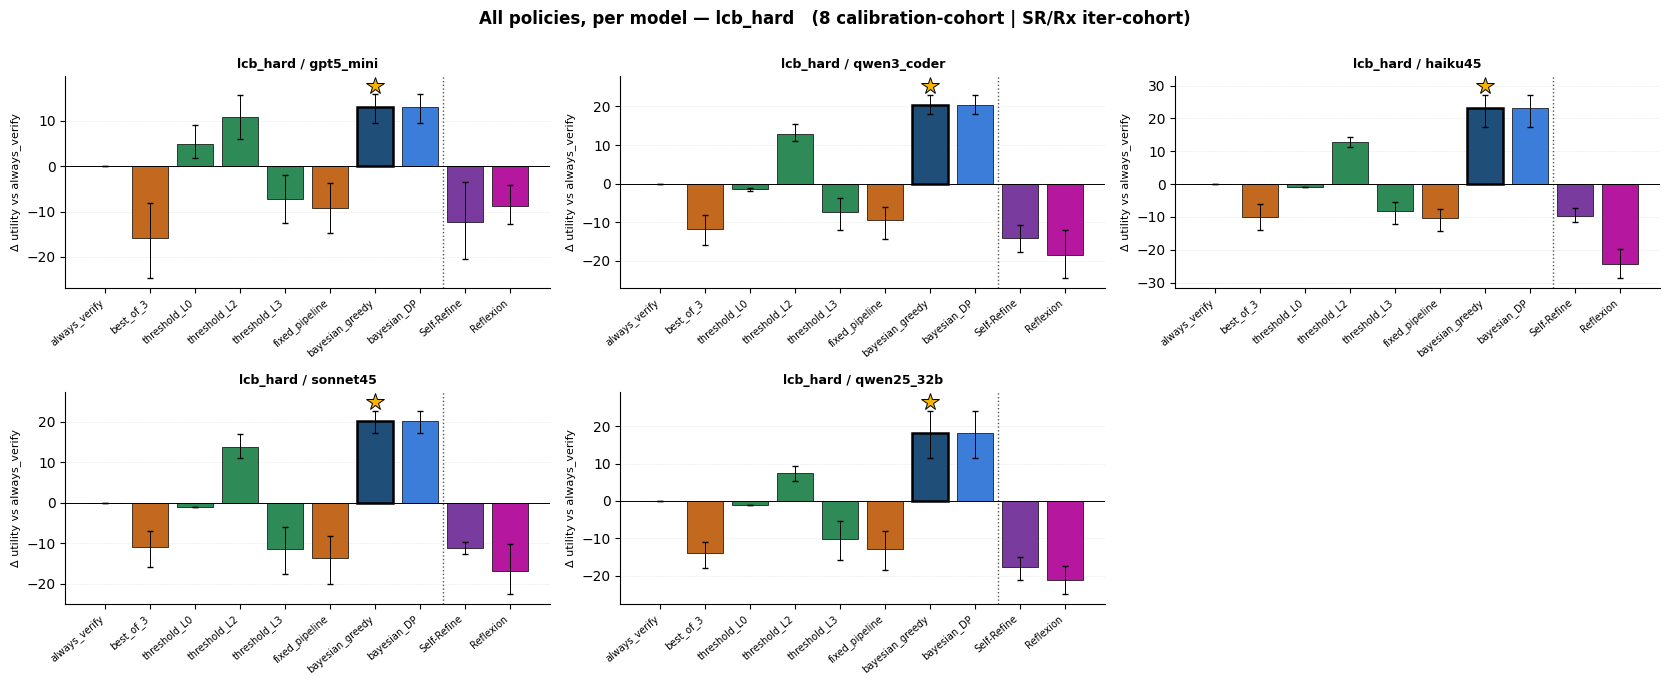

In [144]:
# === lcb_hard ===
plot_all_policies('lcb_hard')

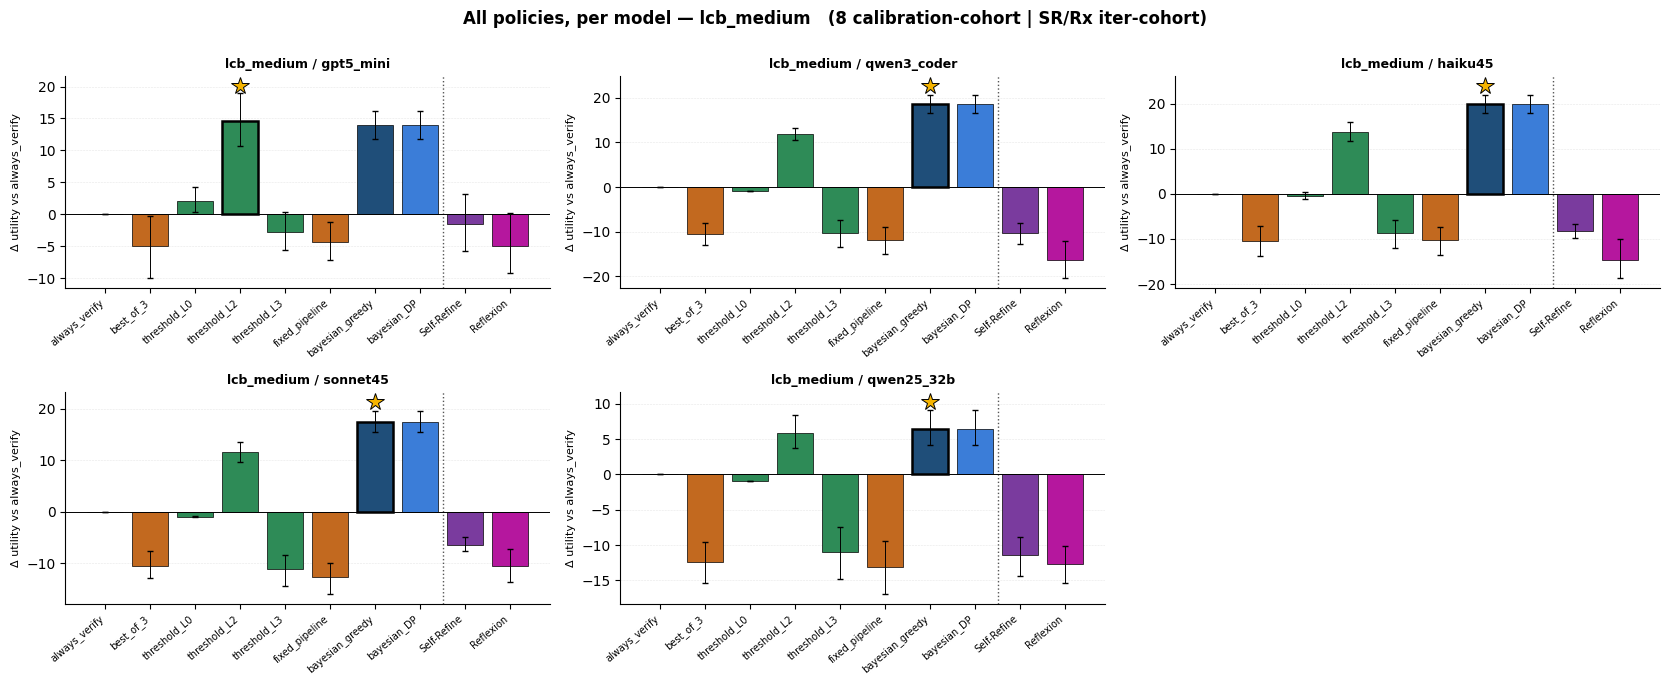

In [145]:
# === lcb_medium ===
plot_all_policies('lcb_medium')

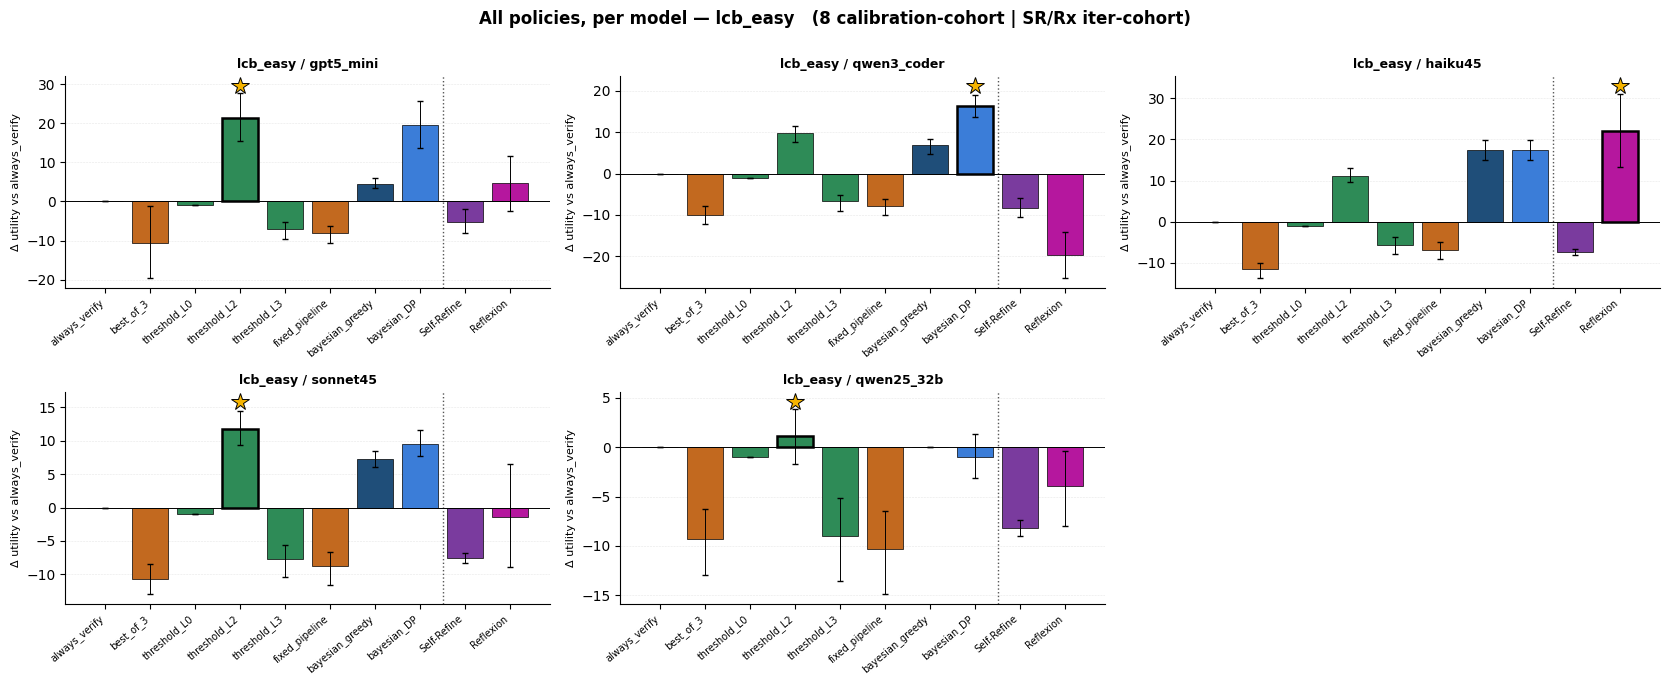

In [146]:
# === lcb_easy ===
plot_all_policies('lcb_easy')

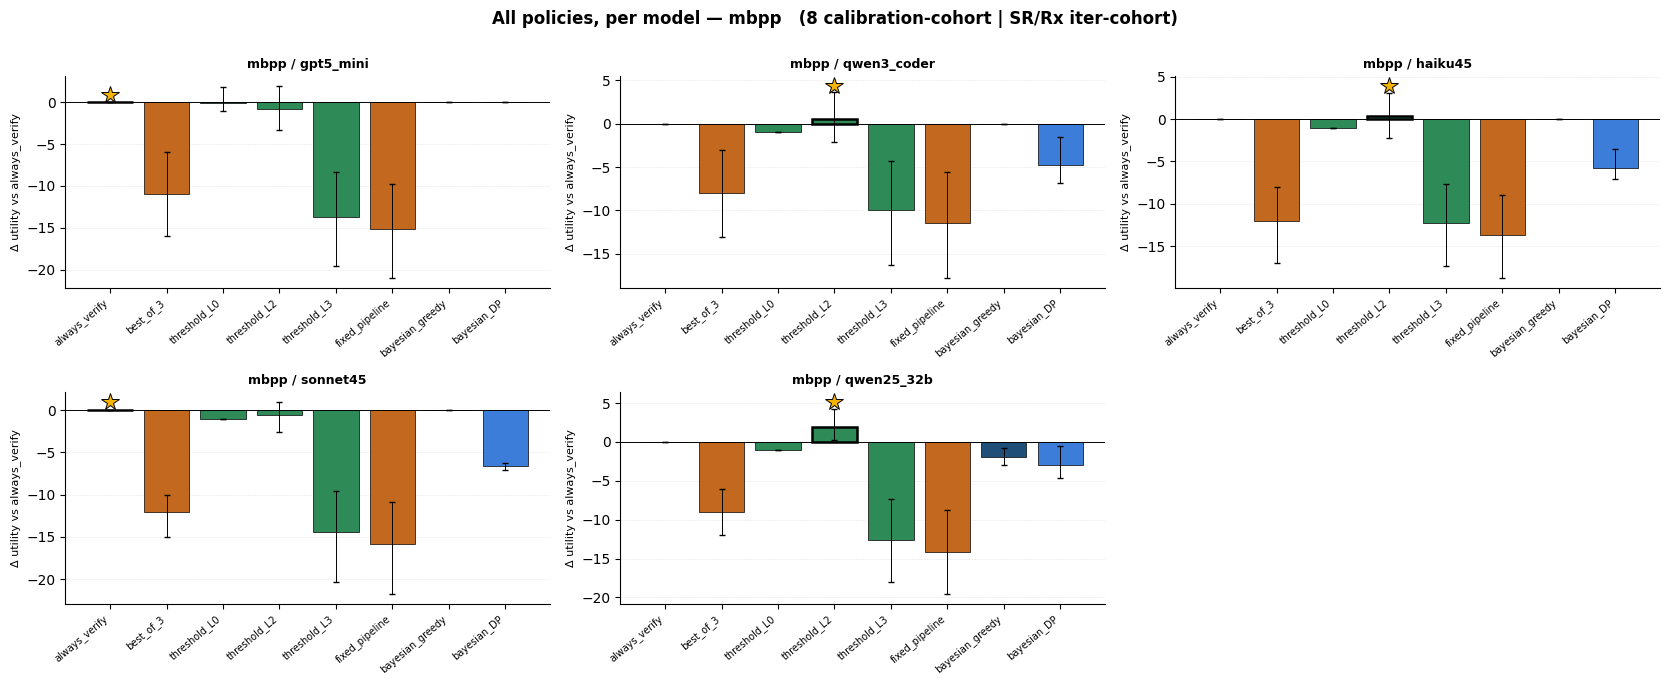

In [147]:
# === mbpp ===
plot_all_policies('mbpp')

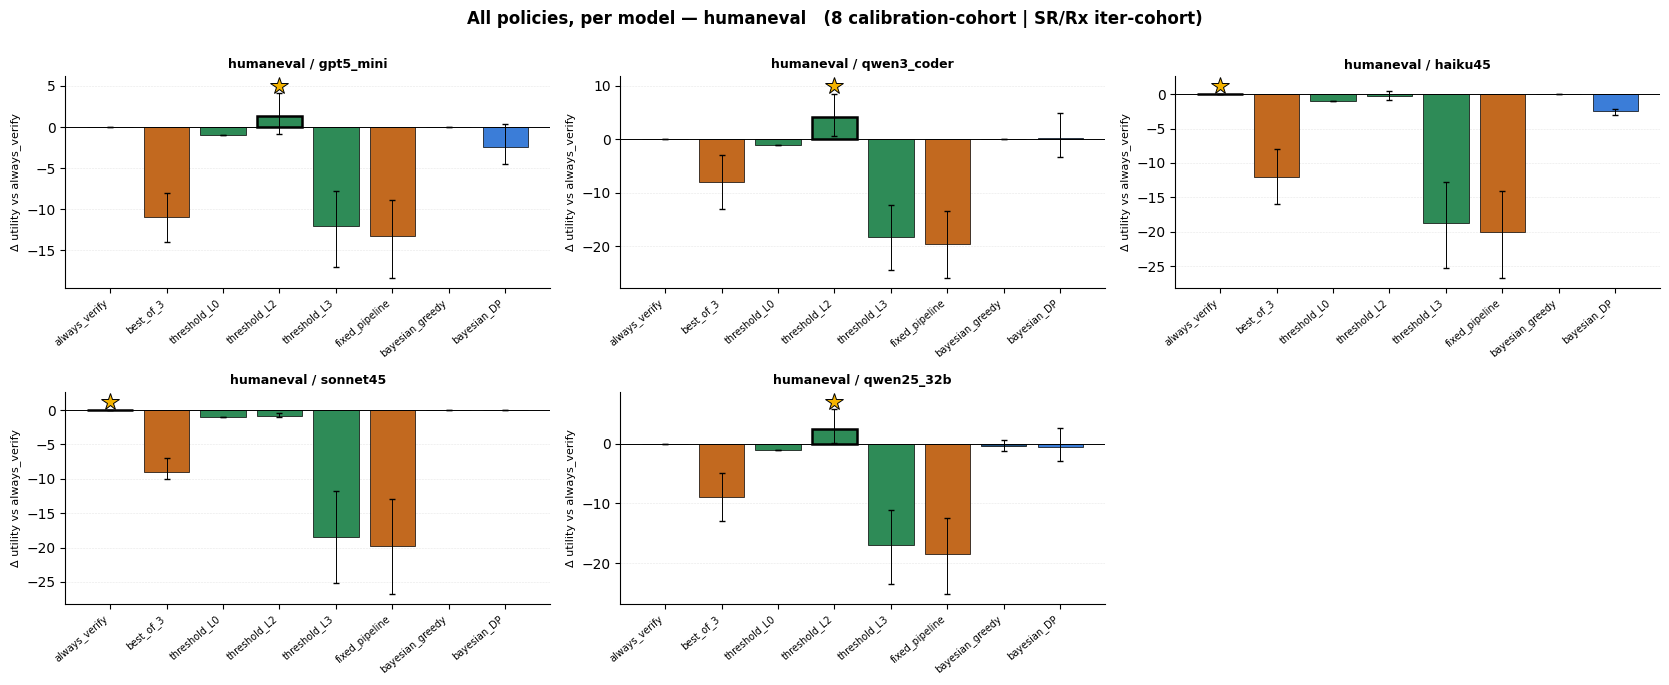

In [148]:
# === humaneval ===
plot_all_policies('humaneval')

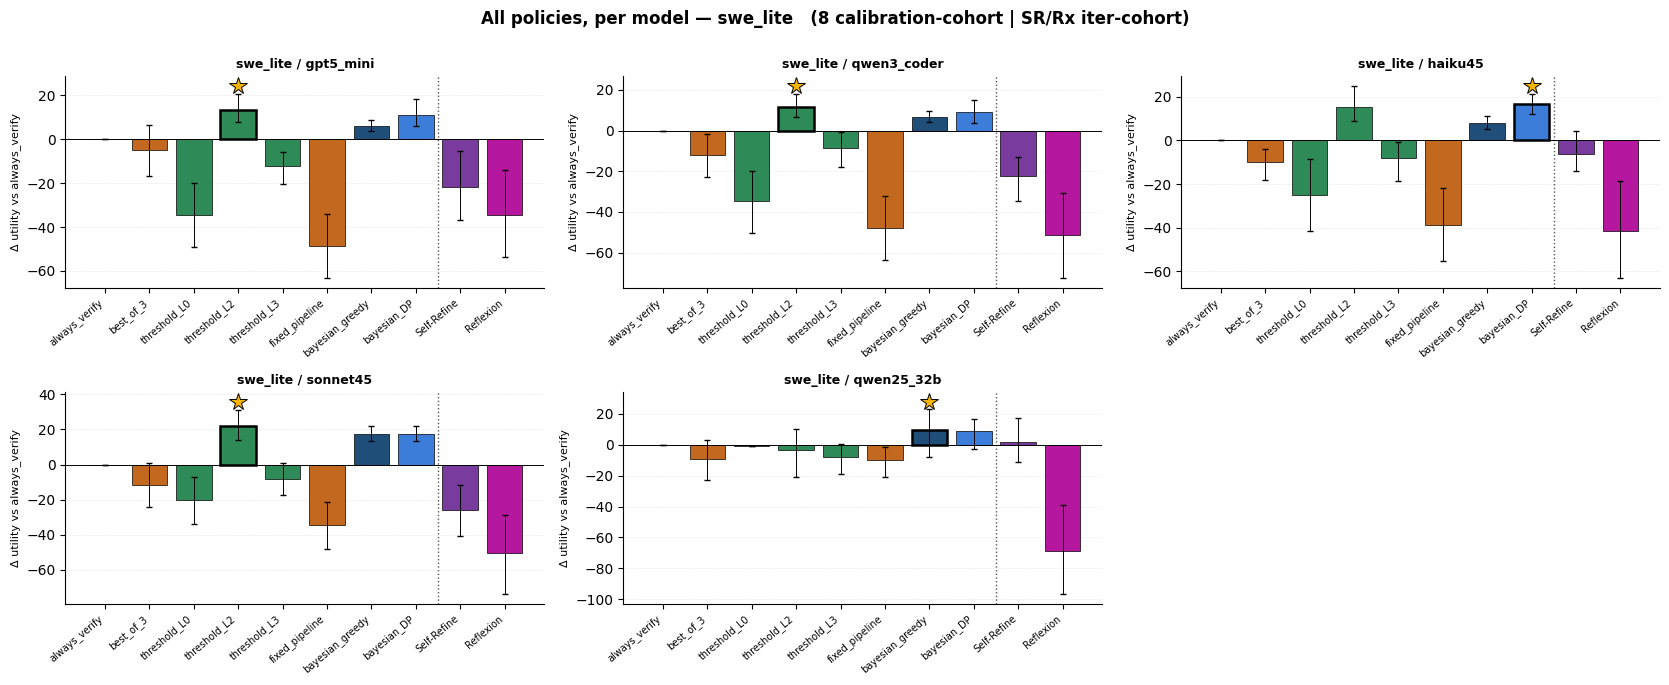

In [149]:
# === swe_lite ===
plot_all_policies('swe_lite')

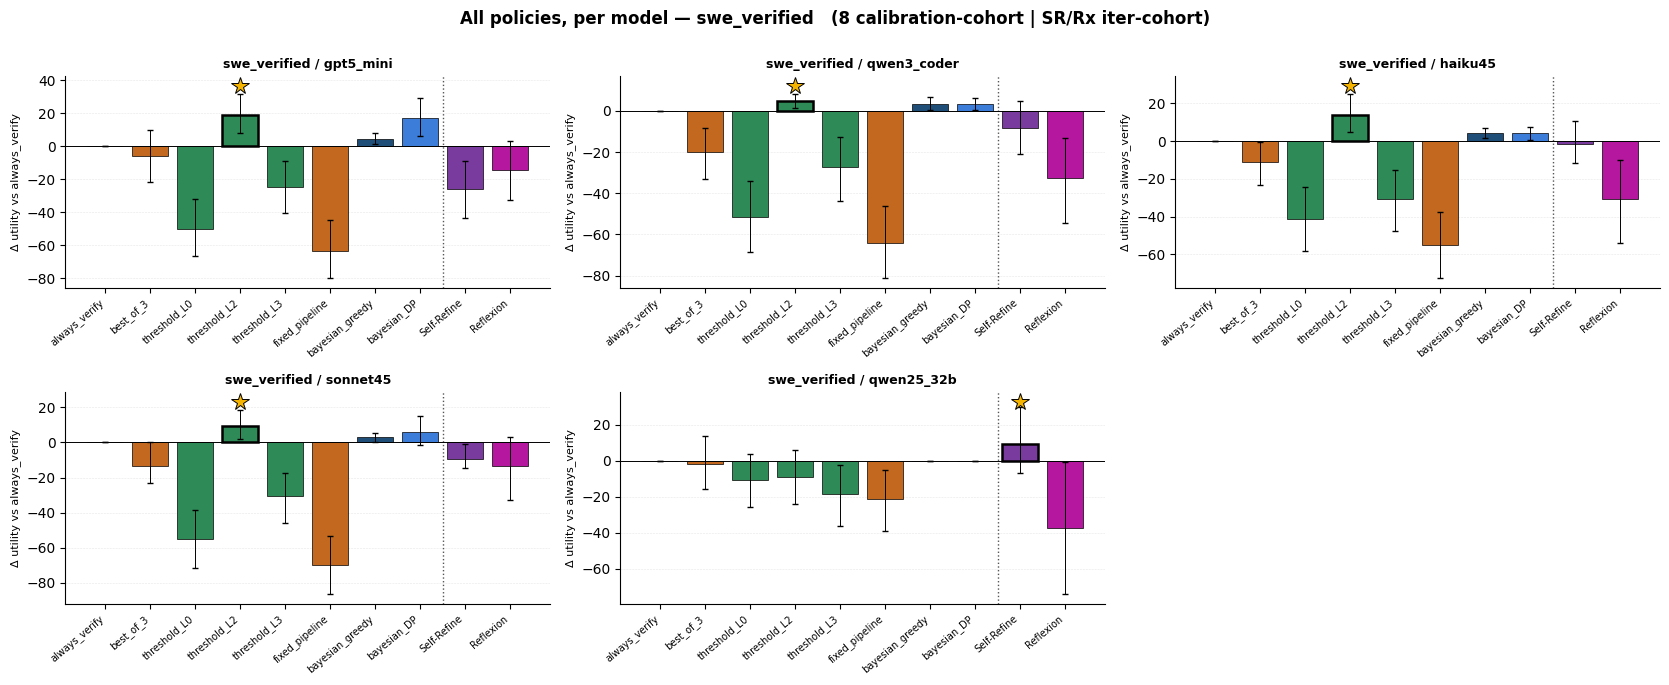

In [150]:
# === swe_verified ===
plot_all_policies('swe_verified')

## 13. L3-reviewer invariance heatmap (LCB-hard)

P(L3 pass | Y=1) − P(L3 pass | Y=0) per (generator × L3-reviewer model). Bold border = self-review. Read entirely from the `L3_gap__<reviewer>` summary fields on `calibration` runs in W&B (logged by `l3_per_reviewer_summary` in `upload_runs.py`). Generators whose run carries no L3 sweep (e.g. `qwen25_32b`) are omitted.

L3 gaps ← .cache/l3_invariance_lcb_hard.parquet (set L3_REFRESH=True to repull)


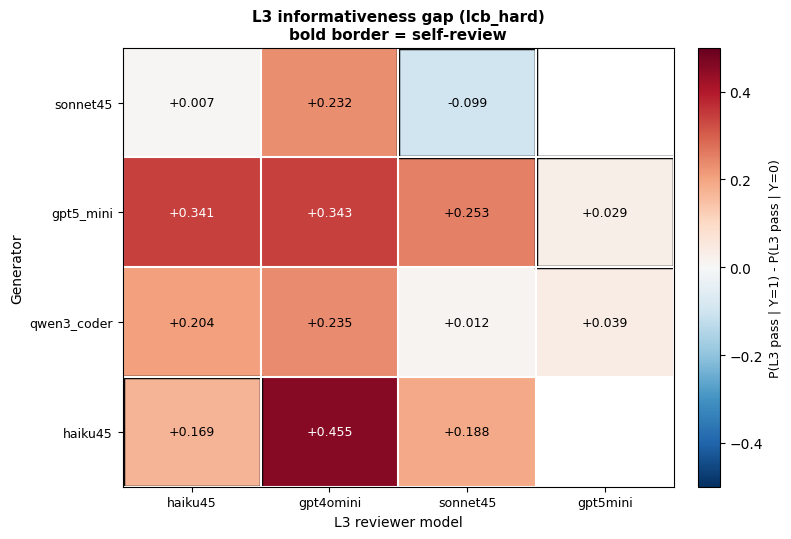

no L3_gap__ in W&B for: ['qwen25_32b'] (no L3 sweep uploaded for these cells)


In [151]:
# %% L3-reviewer invariance
import numpy as np, matplotlib.pyplot as plt

BENCH = "lcb_hard"   # L3 sweep also exists for lcb_easy / lcb_medium / mbpp
REV_ORDER = ["haiku45", "gpt4omini", "sonnet45", "gpt5mini"]
GEN_ORDER = ["sonnet45", "gpt5_mini", "qwen3_coder", "haiku45", "qwen25_32b"]
SELF = {"sonnet45": "sonnet45", "haiku45": "haiku45", "gpt5_mini": "gpt5mini"}

cal = df[(df.experiment_type == "calibration") &
         (df.track == "orchestration") &
         (df.benchmark == BENCH)].copy()

# L3_gap__<rev> are backfilled onto calibration runs *after* upload, so a
# runs.parquet (cell 3) built before that backfill won't carry them. Source
# order, so this cell hits the network at most once (never on every run):
#   1. main runs cache, if it already has L3_gap__  (re-run cell 3 with
#      force_refresh=True once to fold them in permanently)
#   2. small per-benchmark cache  .cache/l3_invariance_<bench>.parquet
#   3. one-off W&B pull (~5 calibration runs) -> written to (2)
L3_REFRESH = False   # flip True once to re-pull L3 gaps from W&B
if not any(c.startswith("L3_gap__") for c in cal.columns):
    l3_cache = CACHE / f"l3_invariance_{BENCH}.parquet"
    if l3_cache.exists() and not L3_REFRESH:
        print(f"L3 gaps \u2190 {l3_cache} (set L3_REFRESH=True to repull)")
        cal = pd.read_parquet(l3_cache)
    else:
        print("L3 gaps \u2190 W&B (one-off pull of calibration runs) …")
        api = wandb.Api()
        recs = []
        for r in api.runs(f"{ENTITY}/{PROJECT}",
                          filters={"config.experiment_type": "calibration",
                                   "config.benchmark": BENCH,
                                   "config.track": "orchestration"}):
            rec = {"generator": r.config.get("generator")}
            rec.update({k: v for k, v in r.summary.items()
                        if k.startswith("L3_gap__")})
            recs.append(rec)
        cal = pd.DataFrame(recs)
        cal.to_parquet(l3_cache)
        print(f"L3 gaps cached \u2192 {l3_cache} ({len(cal)} runs)")

l3_cols = [f"L3_gap__{rv}" for rv in REV_ORDER if f"L3_gap__{rv}" in cal.columns]

rows, present = [], []
for g in GEN_ORDER:
    row = cal[cal.generator == g] if not cal.empty else cal
    if row.empty:
        continue
    r0 = row.iloc[0]
    vals = [r0.get(f"L3_gap__{rv}") if f"L3_gap__{rv}" in cal.columns else np.nan
            for rv in REV_ORDER]
    if all(pd.isna(v) for v in vals):
        continue
    rows.append([float(v) if pd.notna(v) else np.nan for v in vals])
    present.append(g)

if not present:
    print("No L3_gap__ data available in W&B for benchmark", BENCH,
          "— the L3 sweep was not uploaded for any of its calibration cells.")
else:
    M = np.array(rows, dtype=float)
    fig, ax = plt.subplots(figsize=(1.5*len(REV_ORDER)+2, 1.0*len(present)+1.5))
    im = ax.imshow(M, cmap="RdBu_r", vmin=-0.5, vmax=0.5, aspect="auto")
    ax.set_xticks(range(len(REV_ORDER))); ax.set_xticklabels(REV_ORDER, fontsize=9)
    ax.set_yticks(range(len(present))); ax.set_yticklabels(present, fontsize=9)
    ax.set_xlabel("L3 reviewer model"); ax.set_ylabel("Generator")
    ax.set_xticks(np.arange(-0.5, len(REV_ORDER), 1), minor=True)
    ax.set_yticks(np.arange(-0.5, len(present), 1), minor=True)
    ax.grid(which="minor", color="white", linewidth=1.5)
    ax.tick_params(which="minor", length=0)
    for i, g in enumerate(present):
        for j, rv in enumerate(REV_ORDER):
            v = M[i, j]
            if v == v:
                ax.text(j, i, f"{v:+.3f}", ha="center", va="center", fontsize=9,
                        color="white" if abs(v) > 0.28 else "black")
            if SELF.get(g) == rv:
                ax.add_patch(plt.Rectangle((j-0.5, i-0.5), 1, 1, fill=False,
                                           edgecolor="black", linewidth=2.5))
    cb = plt.colorbar(im, ax=ax, fraction=0.046, pad=0.04)
    cb.set_label("P(L3 pass | Y=1) - P(L3 pass | Y=0)", fontsize=9)
    ax.set_title(f"L3 informativeness gap ({BENCH})\nbold border = self-review",
                 fontsize=11, fontweight="bold")
    plt.tight_layout(); plt.show()
    miss = [g for g in GEN_ORDER if g not in present]
    if miss:
        print("no L3_gap__ in W&B for:", miss, "(no L3 sweep uploaded for these cells)")

## 14. Three-regime map — prior × cost-ratio, colored by best strategy

One point per **(benchmark, generator)** cell. **x** = prior $P(Y{=}1)$
(from §2.1 `STAT_PRIOR`); **y** = cost ratio $c_\mathrm{ver}/R$ (from the
§2.5 per-benchmark cost config). Point **colour = the cell's empirical best
policy** (argmax Δ over the 8 `STAT_POLICY` policies):
**A** = Bayesian (`bayesian_greedy`/`bayesian_DP`),
**B** = threshold (`threshold_L0/L2/L3`),
**C** = `always_verify`, **other** = `fixed_pipeline`/`best_of_3` (rare).
Shaded bands are an **illustrative** A/B/C guide (the schematic); the *data*
is the point colour. With §2.5 uniform, every point sits at
$c_\mathrm{ver}/R{=}0.30$ (spreads along x by prior); set per-benchmark
costs in §2.5 to spread it in y.

§7's R×c_ver winner grid is the **same four regimes read cell-by-cell** from the per-policy palette (Bayesian = blue / dark blue, threshold = green, always-verify = grey, other = orange) — the discrete-cost counterpart of this smoothed map.

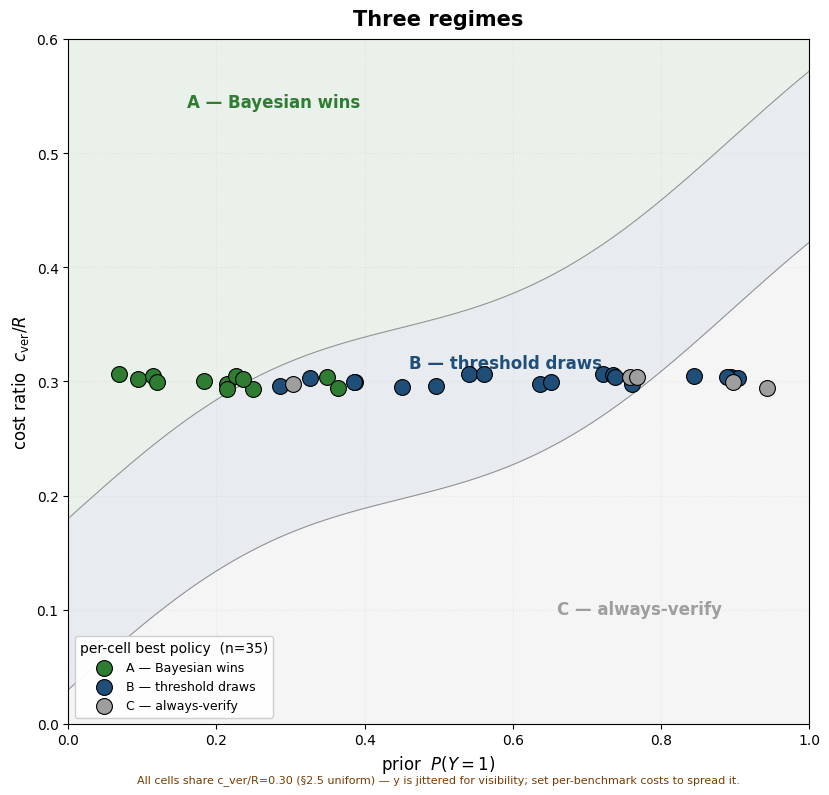

regime counts: {'B': 17, 'A': 13, 'C': 5}


In [152]:
# %% Three-regime map — prior × c_ver/R, colored by best strategy
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D

assert "STAT_POLICY" in globals() and "STAT_PRIOR" in globals() \
    and "COST_VECTORS" in globals(), "run §2.1, §2.5 and §3 first"

# per-cell empirical winner = argmax Δ over the 8 policies
_win = (STAT_POLICY.loc[STAT_POLICY.groupby(["benchmark","generator"])
        ["delta_vs_av"].idxmax()][["benchmark","generator","policy"]])
_prior = STAT_PRIOR[["benchmark","generator","prior_Y1"]]
pts = _win.merge(_prior, on=["benchmark","generator"], how="left")
pts["cver_R"] = pts.benchmark.map(
    lambda b: COST_VECTORS.get(b, {}).get("c_ver", np.nan) /
              COST_VECTORS.get(b, {}).get("reward", np.nan))

def _regime(p):
    if p in ("bayesian_greedy", "bayesian_DP"): return "A"
    if p.startswith("threshold"):               return "B"
    if p == "always_verify":                    return "C"
    return "O"
pts["regime"] = pts.policy.map(_regime)
RC = {"A": "#2E7D32", "B": "#1f4e79", "C": "#9E9E9E", "O": "#c2691f"}
RLAB = {"A": "A — Bayesian wins", "B": "B — threshold draws",
        "C": "C — always-verify", "O": "other (fixed/best-of-3)"}

xmin, xmax = 0.0, 1.0
ymax = max(0.6, float(np.nanmax(pts.cver_R)) * 1.6) if pts.cver_R.notna().any() else 0.6
ymin = 0.0
fig, ax = plt.subplots(figsize=(8.4, 8))
# illustrative A/B/C bands (anti-diagonal: A upper-left, C lower-right)
gx = np.linspace(xmin, xmax, 240)
def _b(off):  # gently wavy increasing boundary, scaled to the y-range
    return ymin + (off + 0.62*gx + 0.05*np.sin(7*gx)) * (ymax - ymin)
up, lo = _b(0.30), _b(0.05)
ax.fill_between(gx, np.clip(up, ymin, ymax), ymax, color=RC["A"], alpha=0.10, lw=0)
ax.fill_between(gx, np.clip(lo, ymin, ymax), np.clip(up, ymin, ymax),
                color=RC["B"], alpha=0.10, lw=0)
ax.fill_between(gx, ymin, np.clip(lo, ymin, ymax), color=RC["C"], alpha=0.10, lw=0)
for yb in (up, lo):
    ax.plot(gx, np.clip(yb, ymin, ymax), color="#3a3a3a", lw=0.8, alpha=0.5)
ax.text(0.16, ymax*0.90, "A — Bayesian wins", color=RC["A"], fontsize=12, fontweight="bold")
ax.text(0.46, ymax*0.52, "B — threshold draws", color=RC["B"], fontsize=12, fontweight="bold")
ax.text(0.66, ymax*0.16, "C — always-verify", color=RC["C"], fontsize=12, fontweight="bold")

# data points (jitter y a touch ONLY if every point shares one y, so 35
# coincident markers are visible; flagged in the caption)
yvals = pts.cver_R.to_numpy(dtype=float)
jit = 0.0
if np.nanstd(yvals) < 1e-9:
    jit = (ymax - ymin) * 0.012
    rng = np.random.default_rng(42)
    yj = yvals + rng.uniform(-jit, jit, len(yvals))
else:
    yj = yvals
for rg, grp in pts.assign(_y=yj).groupby("regime"):
    ax.scatter(grp.prior_Y1, grp._y, c=RC[rg], s=130, edgecolors="black",
               linewidths=0.8, zorder=5, label=RLAB[rg])

ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax)
ax.set_xlabel("prior  $P(Y{=}1)$", fontsize=12)
ax.set_ylabel(r"cost ratio  $c_\mathrm{ver}/R$", fontsize=12)
ax.set_title("Three regimes", fontsize=15, fontweight="bold", pad=10)
ax.grid(alpha=0.20, linestyle=":")
ax.legend(loc="lower left", fontsize=9, framealpha=0.95,
          title=f"per-cell best policy  (n={len(pts)})")
if jit:
    ax.text(0.5, -0.085, "All cells share c_ver/R=0.30 (§2.5 uniform) — "
            "y is jittered for visibility; set per-benchmark costs to spread it.",
            transform=ax.transAxes, ha="center", fontsize=8, color="#7a3b00")
fig.tight_layout()
fig.savefig(CACHE / "fig_three_regimes.png", dpi=150, bbox_inches="tight")
plt.show()
print("regime counts:", pts.regime.value_counts().to_dict())


### Regime grid over the (c_ver, R) cost plane — companion to §14

§14 fixes the cost and spreads the **35 (benchmark, generator) calibration
pairs** over (prior, $c_\mathrm{ver}/R$). This panel does the dual: it
**fixes the whole cohort of 35 pairs and sweeps the cost plane** — a
`CVER_GRID × R_GRID` matrix (per-critic costs `c_gen=5, c_L0=1, c_L2=2,
c_L3=5` held fixed; only $c_\mathrm{ver}$ and $R$ vary).

**What one grid tile means.** At each $(c_\mathrm{ver}, R)$ point we
recompute all 8 policies for **every one of the 35 pairs** by the §3/§7
*canonical* method — `run_policies` for the 7 non-DP policies plus §3's
measured single\_method-kernel DP (`KERN_MEAS` / `_measured_dp_row`, reused
from §3, not reimplemented), winner = `idxmax` of Δ-vs-`always_verify` in
`POLICY_NAMES` order (ties → the simpler policy). Each pair's winning policy
is mapped to a regime — **A** = Bayesian, **B** = threshold, **C** =
always-verify, **O** = other. That gives 35 regime "votes" for the tile; the
**big letter is the plurality regime** (the single most common one) and the
**% is the share of the 35 (benchmark, generator) pairs in that regime** at
that cost.

**Read the % as a plurality, not a majority.** `A 100%` → all 35 pairs are
Bayesian-regime there; `B 45%` → B is merely the largest group while 55% of
pairs are *not* B (split across A/C/O). A low % flags a **heterogeneous**
cost point (no regime dominates the cohort); a high % means the pairs nearly
all agree.

**Axes.** Rows = $c_\mathrm{ver}$ ascending (bottom = 1, top = 100), columns
= $R$ ascending (left = 25, right = 400); the cost ratio $c_\mathrm{ver}/R$
grows toward the top-left. Expect **A (Bayesian)** where verification is
dear relative to reward and **C/B** where it is cheap — the same
three-regime structure §14 draws as a smoothed per-pair map, here collapsed
to one plurality regime per cost point.


sweep (c_ver, R) plane:   0%|          | 0/35 [00:00<?, ?pt/s]

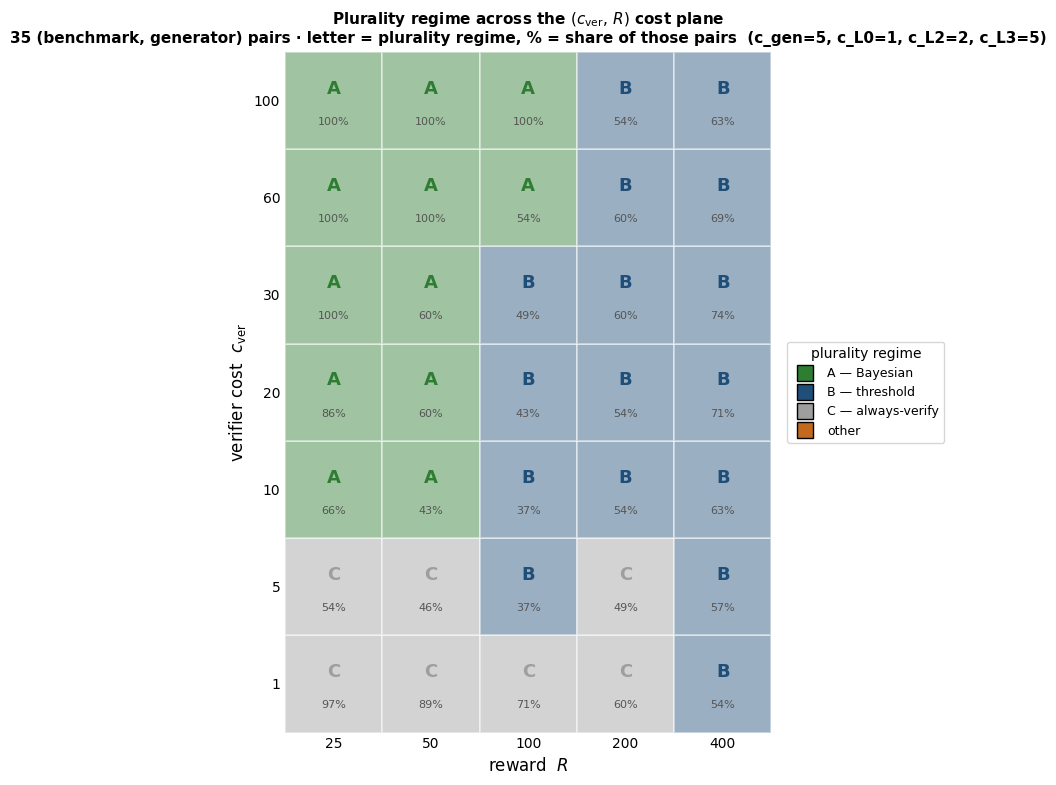

regime grid (rows = c_ver ascending, cols = R):
      R25 R50 R100 R200 R400
cv1     C   C    C    C    B
cv5     C   C    B    C    B
cv10    A   A    B    B    B
cv20    A   A    B    B    B
cv30    A   A    B    B    B
cv60    A   A    A    B    B
cv100   A   A    A    B    B


In [153]:
# %% Regime grid over the (c_ver, R) cost plane (companion to §14)
import sys, json
from pathlib import Path
from collections import Counter
import numpy as np, pandas as pd, matplotlib.pyplot as plt
from matplotlib.patches import Rectangle
from matplotlib.lines import Line2D
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k): return x

SCRIPTS = (Path("../../orchestration_hypothesis_testing/scripts")).resolve()
if str(SCRIPTS) not in sys.path: sys.path.insert(0, str(SCRIPTS))
from upload_runs import compute_likelihoods_from_critic_results
from lcb_sensitivity import run_policies
from lcb_compare import load_lcb_trajectories
from run_baseline_vs_controller import CostModel

assert all(n in globals() for n in
           ("STAT_POLICY", "KERN_MEAS", "_measured_dp_row", "POLICY_NAMES")), \
    ("run §3 (Policy utilities) first -- this map reuses its canonical "
     "measured-kernel DP machinery (KERN_MEAS / _measured_dp_row) and the "
     "POLICY_NAMES winner rule; it does not reimplement them.")
# --- grid axes (edit freely) ---
R_GRID    = [25, 50, 100, 200, 400]
CVER_GRID = [1, 5, 10, 20, 30, 60, 100]
def _regime(p):
    if p in ("bayesian_greedy", "bayesian_DP"): return "A"
    if p.startswith("threshold"):               return "B"
    if p == "always_verify":                    return "C"
    return "O"
def _res_canon(b, g, tr, lk, pr, cost):
    """Canonical per-cell res, shared by every three-regime cell below
    (single source, no reimplementation): run_policies for the 7 non-DP
    policies + §3's measured single_method-kernel DP via KERN_MEAS /
    _measured_dp_row where it exists, else run_policies' IID DP -- exactly
    §3's branch."""
    res = run_policies(tr, lk, pr, cost, n_boot=1)
    if (b, g) in KERN_MEAS:
        res["bayesian_DP"] = _measured_dp_row(
            tr, lk, pr, KERN_MEAS[(b, g)], cost, 1)
    return res
def _winner_canon(res):
    """§7/§3 winner rule: idxmax of delta_vs_av in POLICY_NAMES order
    (ties -> the earlier / simpler policy; == pc[cols].idxmax(axis=1))."""
    pols = [p for p in POLICY_NAMES if p in res]
    mx = max(res[p]["diff_vs_baseline"] for p in pols)
    return next(p for p in pols if res[p]["diff_vs_baseline"] == mx)
RC = {"A": "#2E7D32", "B": "#1f4e79", "C": "#9E9E9E", "O": "#c2691f"}

# Load every calibration cell ONCE from the §2/§3 raw-evidence cache
RAW = CACHE / "raw_evidence"
CELLS = {}
for d in sorted(RAW.glob("calib__*")):
    cr = d / "critic_results.jsonl"
    if not cr.exists():
        continue
    b, g = d.name[len("calib__"):].rsplit("__", 1)
    lk = compute_likelihoods_from_critic_results(cr)
    if lk is None:
        continue
    lk["critic_likelihoods"] = {k: v for k, v in lk["critic_likelihoods"].items()
        if v.get("P_pass_given_Y1") is not None
        and v.get("P_pass_given_Y0") is not None}
    CELLS[(b, g)] = (load_lcb_trajectories(cr), lk, lk["prior_Y1"])
assert CELLS, "no cached calibration critic_results - run §2.0/§3 first"

# Sweep the (c_ver, R) plane: rows = c_ver (ascending), cols = R
grid_reg = np.empty((len(CVER_GRID), len(R_GRID)), dtype=object)
grid_shr = np.zeros((len(CVER_GRID), len(R_GRID)))
combos = [(ci, cv, ri, R) for ci, cv in enumerate(CVER_GRID)
          for ri, R in enumerate(R_GRID)]
for ci, cv, ri, R in tqdm(combos, desc="sweep (c_ver, R) plane", unit="pt"):
    cost = CostModel(c_gen=5, c_L0=1, c_L2=2, c_L3=5, c_ver=cv, reward=R)
    regs = []
    for (b, g), (tr, lk, pr) in CELLS.items():
        res = _res_canon(b, g, tr, lk, pr, cost)
        regs.append(_regime(_winner_canon(res)))
    top, n_top = Counter(regs).most_common(1)[0]
    grid_reg[ci, ri] = top
    grid_shr[ci, ri] = n_top / len(regs)

fig, ax = plt.subplots(figsize=(1.15*len(R_GRID)+3, 0.85*len(CVER_GRID)+2))
for ci in range(len(CVER_GRID)):
    for ri in range(len(R_GRID)):
        rg = grid_reg[ci, ri]
        ax.add_patch(Rectangle((ri, ci), 1, 1, facecolor=RC[rg], alpha=0.45,
                               edgecolor="white", lw=1.4))
        ax.text(ri+0.5, ci+0.62, rg, ha="center", va="center",
                fontsize=13, fontweight="bold", color=RC[rg])
        ax.text(ri+0.5, ci+0.28, f"{grid_shr[ci, ri]*100:.0f}%",
                ha="center", va="center", fontsize=8, color="#555")
ax.set_xlim(0, len(R_GRID)); ax.set_ylim(0, len(CVER_GRID)); ax.set_aspect("equal")
ax.set_xticks([i+0.5 for i in range(len(R_GRID))]); ax.set_xticklabels(R_GRID)
ax.set_yticks([i+0.5 for i in range(len(CVER_GRID))]); ax.set_yticklabels(CVER_GRID)
ax.set_xlabel("reward  $R$", fontsize=12)
ax.set_ylabel(r"verifier cost  $c_\mathrm{ver}$", fontsize=12)
ax.set_title(r"Plurality regime across the $(c_\mathrm{ver},\,R)$ cost plane" "\n"
             f"35 (benchmark, generator) pairs · letter = plurality regime, "
             f"% = share of those pairs  "
             f"(c_gen=5, c_L0=1, c_L2=2, c_L3=5)", fontsize=11, fontweight="bold")
ax.tick_params(length=0)
for sp in ax.spines.values(): sp.set_visible(False)
leg = [Line2D([0], [0], marker="s", color="white", markerfacecolor=RC[k],
              markeredgecolor="black", markersize=12,
              label={"A": "A — Bayesian", "B": "B — threshold",
                     "C": "C — always-verify", "O": "other"}[k])
       for k in ("A", "B", "C", "O")]
ax.legend(handles=leg, loc="center left", bbox_to_anchor=(1.02, 0.5),
          fontsize=9, frameon=True, title="plurality regime")
fig.tight_layout()
fig.savefig(CACHE / "fig_regime_grid_cver_R.png", dpi=150, bbox_inches="tight")
plt.show()
print("regime grid (rows = c_ver ascending, cols = R):")
print(pd.DataFrame(grid_reg, index=[f"cv{c}" for c in CVER_GRID],
                    columns=[f"R{r}" for r in R_GRID]).to_string())


### Three-regime scatter — populated from the (c_ver, R) grid

§14's scatter is at a *single* cost (all points at $c_\mathrm{ver}/R=0.30$).
This is the **populated** version: one point per
**(benchmark, generator) × (c_ver, R)** grid pair —
x = prior $P(Y{=}1)$, y = $c_\mathrm{ver}/R$, colour = that cell's winning
regime at that cost (argmax-Δ over the 8 policies; A=Bayesian, B=threshold,
C=always-verify). $|CELLS|\times|CVER\_GRID|\times|R\_GRID|$ points. With the
cost ratio swept, the points fill the plane and the three regimes emerge
**from the data itself** (no illustrative bands needed): high
$c_\mathrm{ver}/R$ → A, low → C, mid → B. y is log-scaled (the grid spans
$c_\mathrm{ver}/R\!\in\![0.0025, 4]$). Reuses `CELLS`/`R_GRID`/`CVER_GRID`
from the grid-companion cell above.

populate scatter over (c_ver, R) grid:   0%|          | 0/35 [00:00<?, ?pt/s]

1225 points = 35 cells x 7 c_ver x 5 R; regime mix: {'A': 494, 'B': 407, 'C': 314, 'O': 10}
  winner split (greedy vs DP): {'Ag': 420, 'Ad': 74, 'B': 407, 'C': 314, 'O': 10}


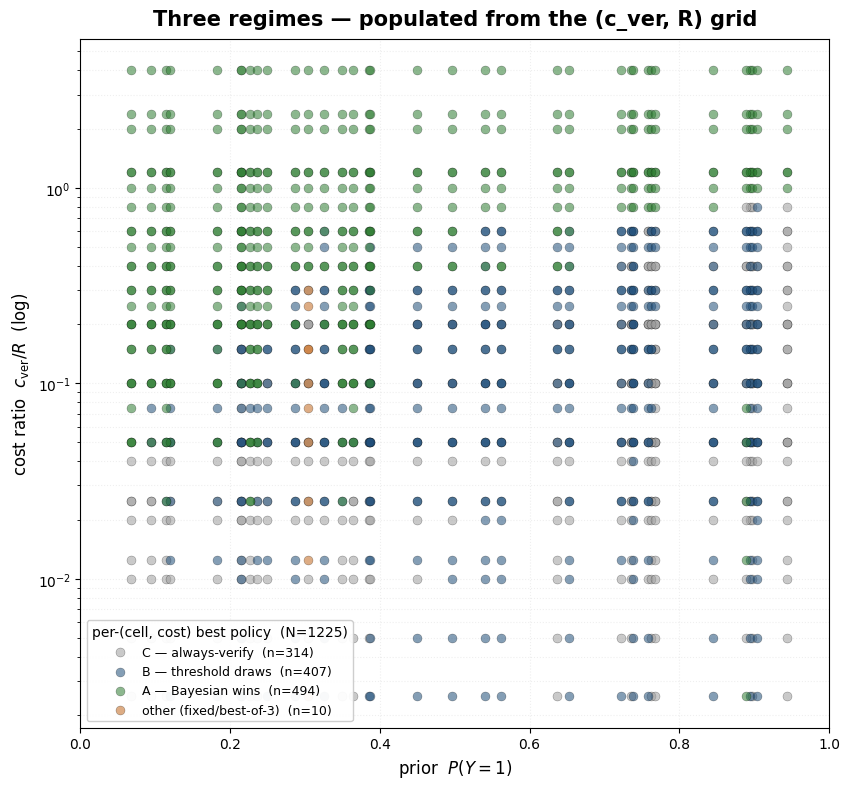

In [154]:
# %% Three-regime scatter — populated from the (c_ver, R) grid
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from run_baseline_vs_controller import CostModel
from lcb_sensitivity import run_policies
try:
    from tqdm.auto import tqdm
except ImportError:
    def tqdm(x, **k): return x

assert all(n in globals() for n in
           ("CELLS", "R_GRID", "CVER_GRID", "_res_canon", "_winner_canon",
            "_regime")), \
    ("run the (c_ver, R) regime-grid companion cell above first -- it defines "
     "CELLS/R_GRID/CVER_GRID and the canonical _res_canon/_winner_canon/"
     "_regime this cell reuses (single source).")
BAYES = ("bayesian_greedy", "bayesian_DP")
def _winner5(res):
    # csW: the regime, with the Bayesian region split into its ACTUAL winner.
    # win via the canonical POLICY_NAMES idxmax on the measured-kernel-DP res
    # (_winner_canon -- same as cs). Inside A, credit greedy unless DP
    # STRICTLY beats it (greedy is the simpler controller; tie -> greedy;
    # order-independent -- not the discarded bayesian_DP-before-greedy POLS).
    win = _winner_canon(res)
    if win not in BAYES:
        return _regime(win)                       # B / C / O, same as cs
    dg = res.get("bayesian_greedy", {}).get("diff_vs_baseline", -1e18)
    dd = res.get("bayesian_DP", {}).get("diff_vs_baseline", -1e18)
    return "Ad" if dd > dg else "Ag"
RC = {"A": "#2E7D32", "B": "#1f4e79", "C": "#9E9E9E", "O": "#c2691f"}
RLAB = {"A": "A — Bayesian wins", "B": "B — threshold draws",
        "C": "C — always-verify", "O": "other (fixed/best-of-3)"}

xs, ys, cs, csW = [], [], [], []
combos = [(cv, R) for cv in CVER_GRID for R in R_GRID]
for cv, R in tqdm(combos, desc="populate scatter over (c_ver, R) grid", unit="pt"):
    cost = CostModel(c_gen=5, c_L0=1, c_L2=2, c_L3=5, c_ver=cv, reward=R)
    ratio = cv / R
    for (b, g), (tr, lk, pr) in CELLS.items():
        res = _res_canon(b, g, tr, lk, pr, cost)
        win = _winner_canon(res)
        xs.append(pr); ys.append(ratio); cs.append(_regime(win))
        csW.append(_winner5(res))
xs = np.array(xs); ys = np.array(ys); cs = np.array(cs); csW = np.array(csW)
print(f"{len(xs)} points = {len(CELLS)} cells x {len(CVER_GRID)} c_ver x "
      f"{len(R_GRID)} R; regime mix: "
      f"{ {k:int((cs==k).sum()) for k in ('A','B','C','O')} }")
print(f"  winner split (greedy vs DP): "
      f"{ {k:int((csW==k).sum()) for k in ('Ag','Ad','B','C','O')} }")

fig, ax = plt.subplots(figsize=(8.6, 8))
for rg in ("C", "B", "A", "O"):
    m = cs == rg
    if m.any():
        ax.scatter(xs[m], ys[m], c=RC[rg], s=42, alpha=0.55,
                   edgecolors="black", linewidths=0.25, zorder=3,
                   label=f"{RLAB[rg]}  (n={int(m.sum())})")
ax.set_yscale("log")
ax.set_xlim(0.0, 1.0)
ax.set_xlabel("prior  $P(Y{=}1)$", fontsize=12)
ax.set_ylabel(r"cost ratio  $c_\mathrm{ver}/R$  (log)", fontsize=12)
ax.set_title("Three regimes — populated from the (c_ver, R) grid",
             fontsize=15, fontweight="bold", pad=10)
ax.grid(alpha=0.20, linestyle=":", which="both")
ax.legend(loc="lower left", fontsize=9, framealpha=0.95,
          title=f"per-(cell, cost) best policy  (N={len(xs)})")
fig.tight_layout()
fig.savefig(CACHE / "fig_three_regimes_populated.png", dpi=150, bbox_inches="tight")
plt.show()


### Three-regime **regions** — decision map from the 1225 points

Same data as the populated scatter, but rendered as **filled regimes**
instead of dots: a dependency-free **k-NN majority vote** (k=25) over the
1225 labelled points in $(\text{prior},\ \log_{10} c_\mathrm{ver}/R)$ space
predicts the winning regime on a fine grid, drawn as green/blue/grey
regions (the data-driven version of the schematic's bands). The 1225 points
are overlaid faintly so you can see the regions follow the data. Reuses
`xs/ys/cs` from the populated-scatter cell above.

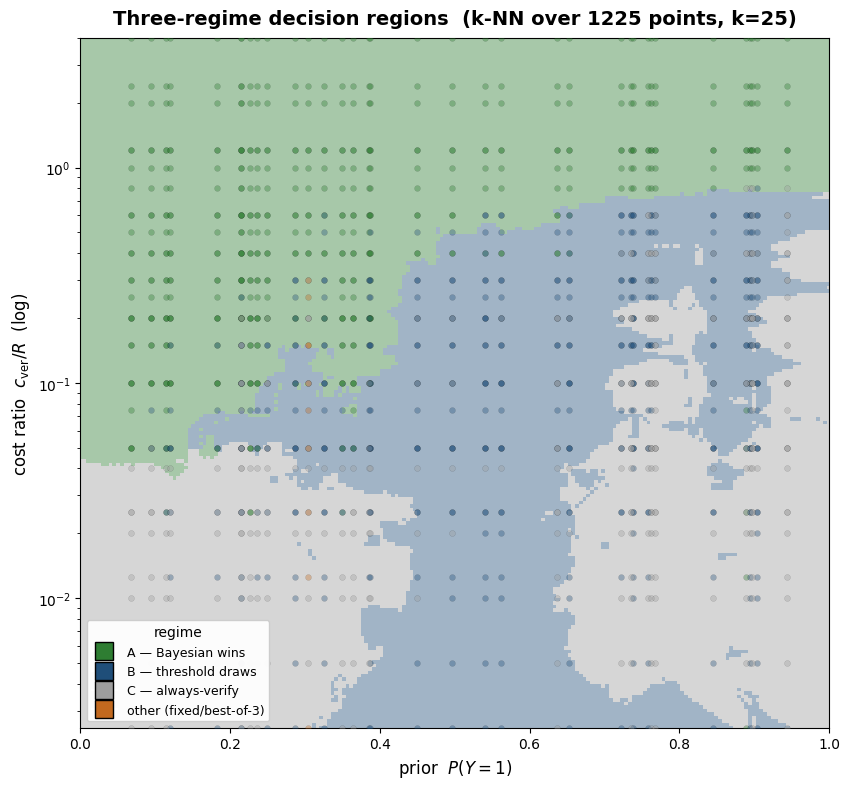

region pixels per regime: {'A': 15093, 'B': 12010, 'C': 12897, 'O': 0}


In [155]:
# %% Three-regime decision regions (k-NN over the 1225 grid points)
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

assert all(n in globals() for n in ("xs", "ys", "cs")), \
    "run the populated three-regime scatter cell above first (defines xs/ys/cs)"
RC   = {"A": "#2E7D32", "B": "#1f4e79", "C": "#9E9E9E", "O": "#c2691f"}
RLAB = {"A": "A — Bayesian wins", "B": "B — threshold draws",
        "C": "C — always-verify", "O": "other (fixed/best-of-3)"}
ORD  = ["A", "B", "C", "O"]
LMAP = {k: i for i, k in enumerate(ORD)}

x = np.asarray(xs, float)                       # prior
y = np.asarray(ys, float)                       # c_ver/R
lab = np.array([LMAP[c] for c in cs])
fy = np.log10(y)                                # work in log10(c_ver/R)
# standardize features so prior and log-ratio weigh equally in k-NN distance
def _z(a): return (a - a.mean()) / (a.std() if a.std() else 1.0)
F = np.column_stack([_z(x), _z(fy)])

# query grid (linear in prior, log-spaced in c_ver/R)
GX = np.linspace(0.0, 1.0, 200)
GY = np.logspace(np.log10(y.min()), np.log10(y.max()), 200)
MX, MY = np.meshgrid(GX, GY)
Q = np.column_stack([(MX.ravel() - x.mean()) / (x.std() or 1.0),
                     (np.log10(MY).ravel() - fy.mean()) / (fy.std() or 1.0)])

K = 25
pred = np.empty(Q.shape[0], int)
for s in range(0, Q.shape[0], 2000):                # chunk to cap memory
    d = ((Q[s:s+2000, None, :] - F[None, :, :]) ** 2).sum(-1)
    nn = np.argpartition(d, K, axis=1)[:, :K]
    pred[s:s+2000] = [np.bincount(lab[r], minlength=len(ORD)).argmax()
                      for r in nn]
pred = pred.reshape(MX.shape)

fig, ax = plt.subplots(figsize=(8.6, 8))
ax.pcolormesh(GX, GY, pred, cmap=ListedColormap([RC[k] for k in ORD]),
              vmin=0, vmax=len(ORD)-1, alpha=0.42, shading="auto")
# faint data points so the regions visibly follow the winners
for k in ORD:
    m = np.array(cs) == k
    if m.any():
        ax.scatter(x[m], y[m], c=RC[k], s=18, alpha=0.35,
                   edgecolors="black", linewidths=0.15, zorder=4)
ax.set_yscale("log")
ax.set_xlim(0.0, 1.0); ax.set_ylim(y.min(), y.max())
ax.set_xlabel("prior  $P(Y{=}1)$", fontsize=12)
ax.set_ylabel(r"cost ratio  $c_\mathrm{ver}/R$  (log)", fontsize=12)
ax.set_title("Three-regime decision regions  (k-NN over 1225 points, k=25)",
             fontsize=14, fontweight="bold", pad=10)
present = [k for k in ORD if (np.array(cs) == k).any()]
ax.legend(handles=[Line2D([0], [0], marker="s", color="white",
                          markerfacecolor=RC[k], markeredgecolor="black",
                          markersize=13, label=RLAB[k]) for k in present],
          loc="lower left", fontsize=9, framealpha=0.95, title="regime")
fig.tight_layout()
fig.savefig(CACHE / "fig_three_regimes_regions.png", dpi=150, bbox_inches="tight")
plt.show()
print("region pixels per regime:",
      {k: int((pred == LMAP[k]).sum()) for k in ORD})


### Decision regions — winning policy, greedy vs DP distinguished

The three-regime regions map above collapses `bayesian_greedy` and
`bayesian_DP` into one green "A". This cell is the **same** k-NN decision
map (same 1225 points, same k=25, same standardized features) but it shows
the *actual* winning policy: the Bayesian region is split into **A·greedy**
vs **A·DP**, with the non-Bayesian winners unchanged (threshold → B = blue,
always-verify → C = grey, fixed/best-of-3 → O = orange).

Inside the Bayesian region the winner is **greedy unless DP *strictly*
beats it**: greedy is the simpler controller (no lookahead, no
transition-kernel estimate), so an exact greedy/DP tie — the common case
under `run_policies`' IID kernel — counts as a greedy win. That tiebreak is
principled (Occam / strict dominance) and order-independent — *not* the
policy-list argmax that produced the earlier phantom "DP" map. So green =
greedy genuinely wins, teal = DP strictly wins (a small real pocket), grey
= always-verify, blue = threshold. The §3 measured-kernel DP — where
lookahead can really pay off — is the separate per-cell quantity.


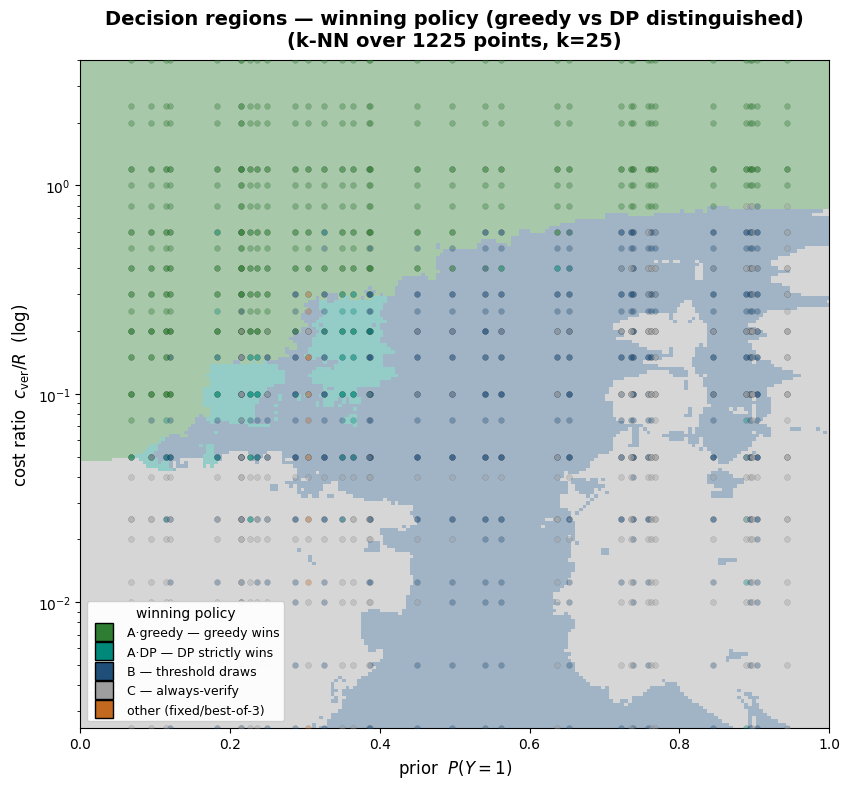

region pixels per class: {'Ag': 13777, 'Ad': 888, 'B': 12340, 'C': 12995, 'O': 0}


In [156]:
# %% Decision regions — winning policy (greedy vs DP distinguished)
# Same k-NN decision map as the three-regime regions cell above, but the
# Bayesian region keeps its actual winner via csW (from the populated
# scatter): A.greedy vs A.DP; threshold -> B, always-verify -> C, else O.
import numpy as np, matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.lines import Line2D

assert all(n in globals() for n in ("xs", "ys", "csW")), \
    "run the populated three-regime scatter cell above first (defines xs/ys/csW)"
RC   = {"Ag": "#2E7D32", "Ad": "#00897B", "B": "#1f4e79",
        "C": "#9E9E9E", "O": "#c2691f"}
RLAB = {"Ag": "A·greedy — greedy wins", "Ad": "A·DP — DP strictly wins",
        "B": "B — threshold draws", "C": "C — always-verify",
        "O": "other (fixed/best-of-3)"}
ORD  = ["Ag", "Ad", "B", "C", "O"]
LMAP = {k: i for i, k in enumerate(ORD)}

x = np.asarray(xs, float)                       # prior
y = np.asarray(ys, float)                       # c_ver/R
lab = np.array([LMAP[c] for c in csW])
fy = np.log10(y)                                # work in log10(c_ver/R)
# standardize features so prior and log-ratio weigh equally in k-NN distance
def _z(a): return (a - a.mean()) / (a.std() if a.std() else 1.0)
F = np.column_stack([_z(x), _z(fy)])

# query grid (linear in prior, log-spaced in c_ver/R)
GX = np.linspace(0.0, 1.0, 200)
GY = np.logspace(np.log10(y.min()), np.log10(y.max()), 200)
MX, MY = np.meshgrid(GX, GY)
Q = np.column_stack([(MX.ravel() - x.mean()) / (x.std() or 1.0),
                     (np.log10(MY).ravel() - fy.mean()) / (fy.std() or 1.0)])

K = 25
pred = np.empty(Q.shape[0], int)
for s in range(0, Q.shape[0], 2000):                # chunk to cap memory
    d = ((Q[s:s+2000, None, :] - F[None, :, :]) ** 2).sum(-1)
    nn = np.argpartition(d, K, axis=1)[:, :K]
    pred[s:s+2000] = [np.bincount(lab[r], minlength=len(ORD)).argmax()
                      for r in nn]
pred = pred.reshape(MX.shape)

fig, ax = plt.subplots(figsize=(8.6, 8))
ax.pcolormesh(GX, GY, pred, cmap=ListedColormap([RC[k] for k in ORD]),
              vmin=0, vmax=len(ORD)-1, alpha=0.42, shading="auto")
# faint data points so the regions visibly follow the winners
for k in ORD:
    m = np.array(csW) == k
    if m.any():
        ax.scatter(x[m], y[m], c=RC[k], s=18, alpha=0.35,
                   edgecolors="black", linewidths=0.15, zorder=4)
ax.set_yscale("log")
ax.set_xlim(0.0, 1.0); ax.set_ylim(y.min(), y.max())
ax.set_xlabel("prior  $P(Y{=}1)$", fontsize=12)
ax.set_ylabel(r"cost ratio  $c_\mathrm{ver}/R$  (log)", fontsize=12)
ax.set_title("Decision regions — winning policy (greedy vs DP distinguished)"
             "\n(k-NN over 1225 points, k=25)",
             fontsize=14, fontweight="bold", pad=10)
present = [k for k in ORD if (np.array(csW) == k).any()]
ax.legend(handles=[Line2D([0], [0], marker="s", color="white",
                          markerfacecolor=RC[k], markeredgecolor="black",
                          markersize=13, label=RLAB[k]) for k in present],
          loc="lower left", fontsize=9, framealpha=0.95, title="winning policy")
fig.tight_layout()
fig.savefig(CACHE / "fig_regions_greedy_vs_dp.png", dpi=150, bbox_inches="tight")
plt.show()
print("region pixels per class:",
      {k: int((pred == LMAP[k]).sum()) for k in ORD})

## 15. c_ver sweep — Δ vs always_verify per policy, by generator (all benchmarks)

For **each benchmark** (one figure per benchmark) a panel per generator:
every policy's Δ utility vs `always_verify` as the **verifier cost
$c_\mathrm{ver}$** sweeps (reward $R=100$ fixed; per-critic costs
`c_gen=5, c_L0=1, c_L2=2, c_L3=5`). Δ at each grid $c_\mathrm{ver}$ is the
**canonical** quantity reused from the §14 regime-grid companion —
`_res_canon` = `run_policies` for the 7 non-DP policies + §3's measured
single\_method-kernel DP via `KERN_MEAS`/`_measured_dp_row` (no
reimplementation). `always_verify` is the baseline, so its curve is the
flat **0 line**.

The transparent background = **the best policy at that $c_\mathrm{ver}$**,
computed as the **exact upper envelope of the drawn Δ polylines** (no
utility recomputation): on each `CVER_SWEEP` interval every policy is a
straight segment between its two endpoints, plus `always_verify` ≡ 0; the
band is the topmost segment and the **dotted dividers are the analytic
segment intersections** where the leading policy changes (labelled). So the
shading matches the plotted lines exactly — the colour switches *iff* the
topmost line switches.


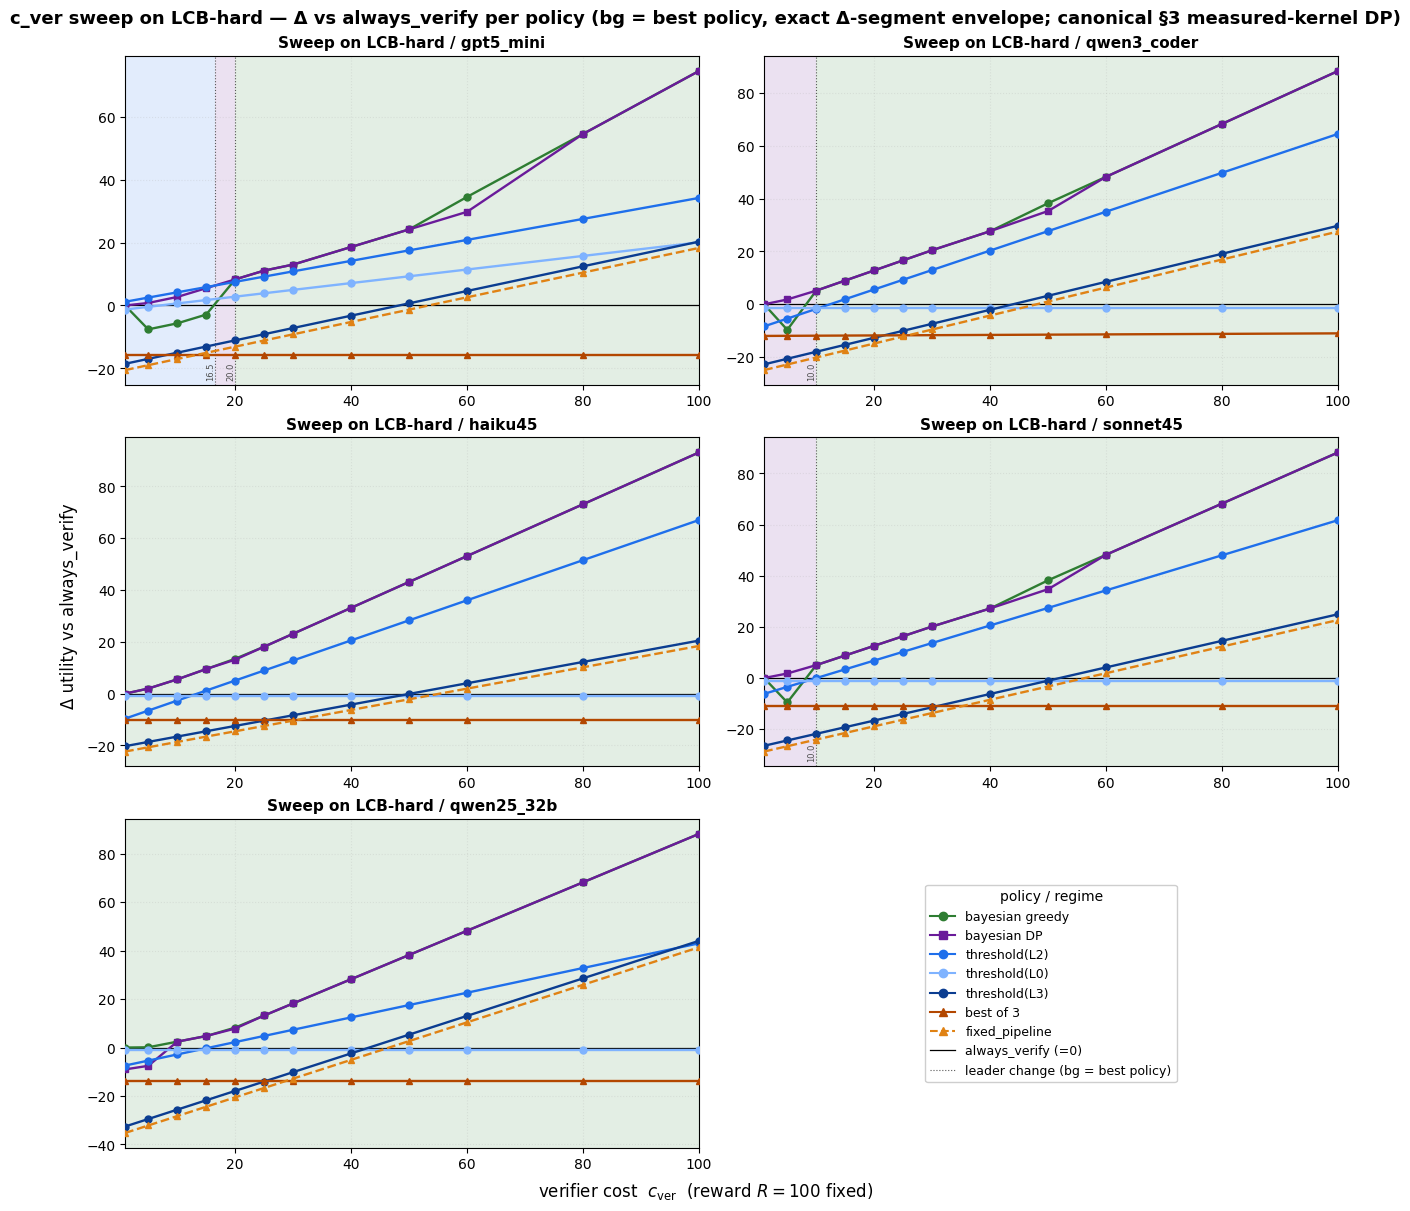

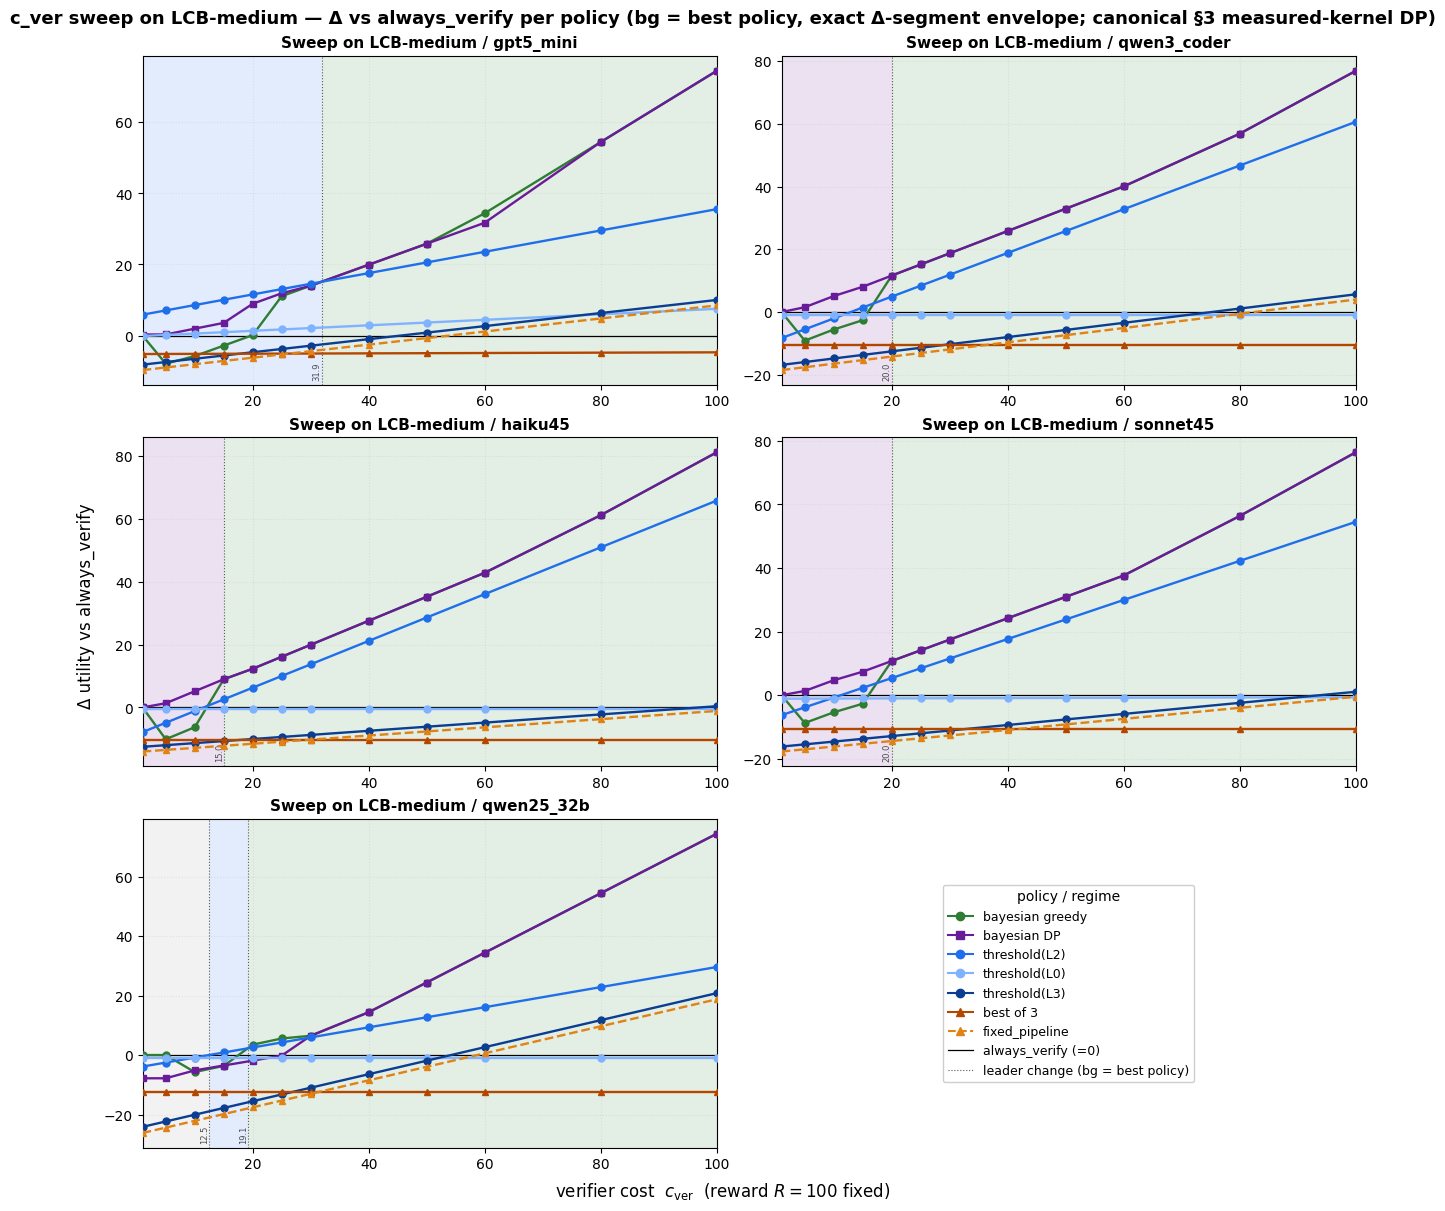

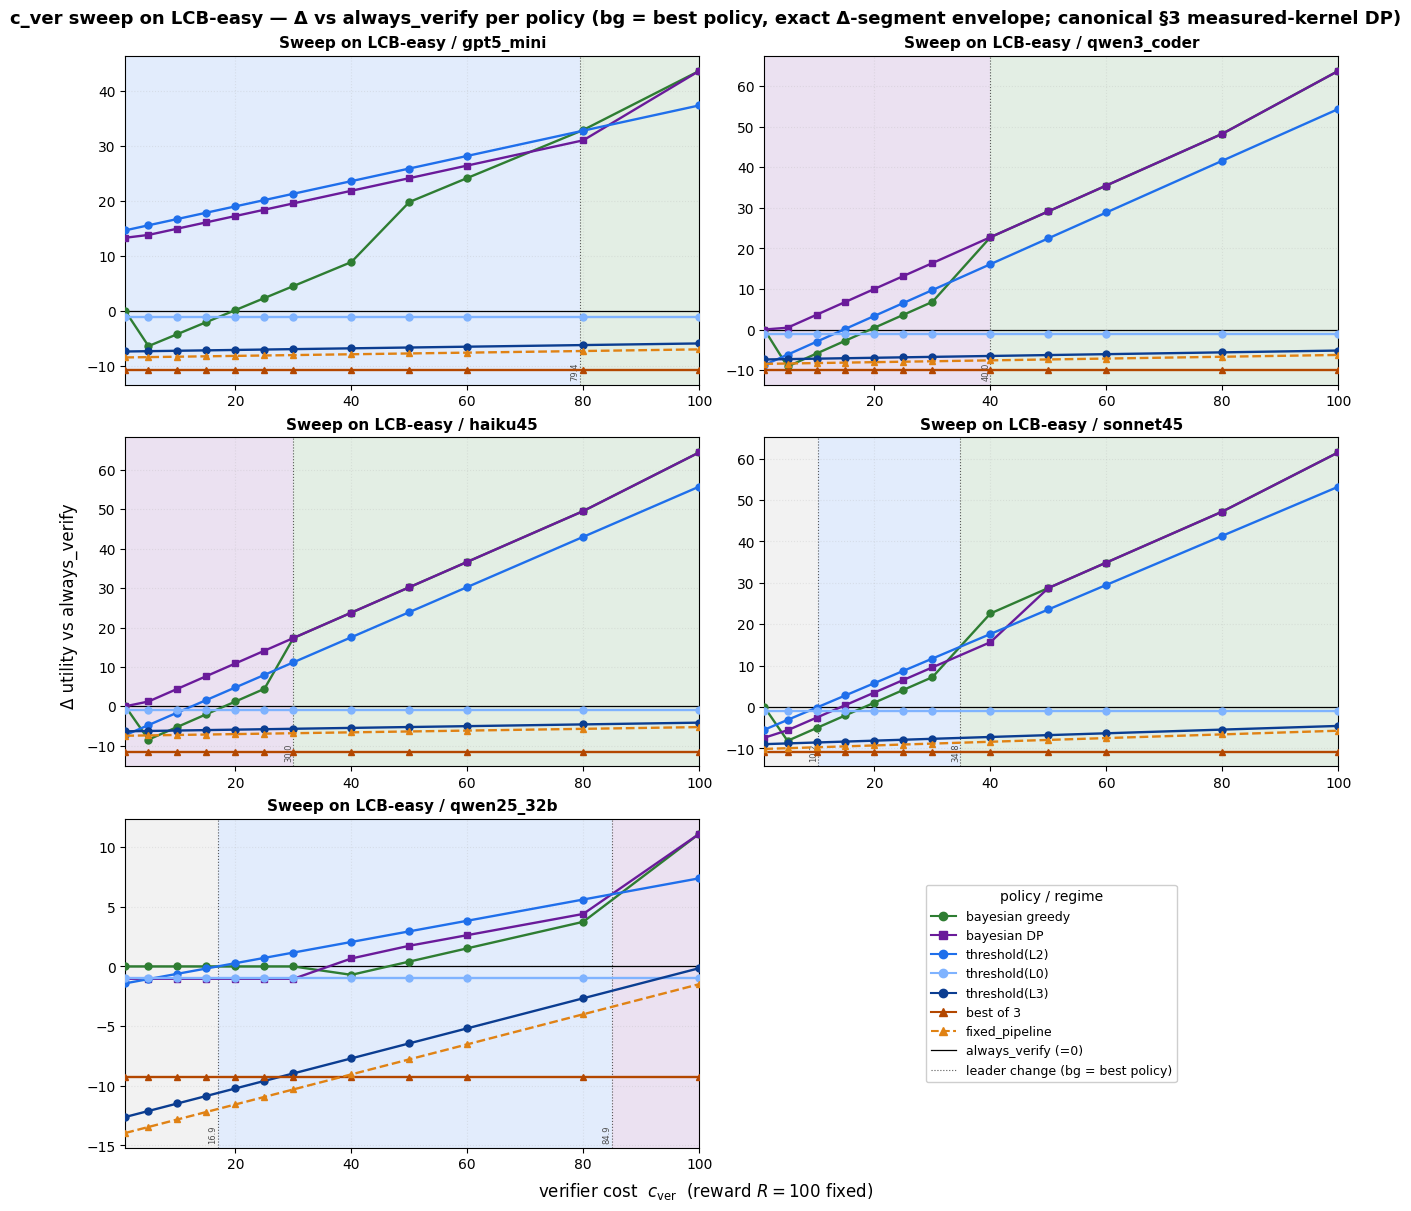

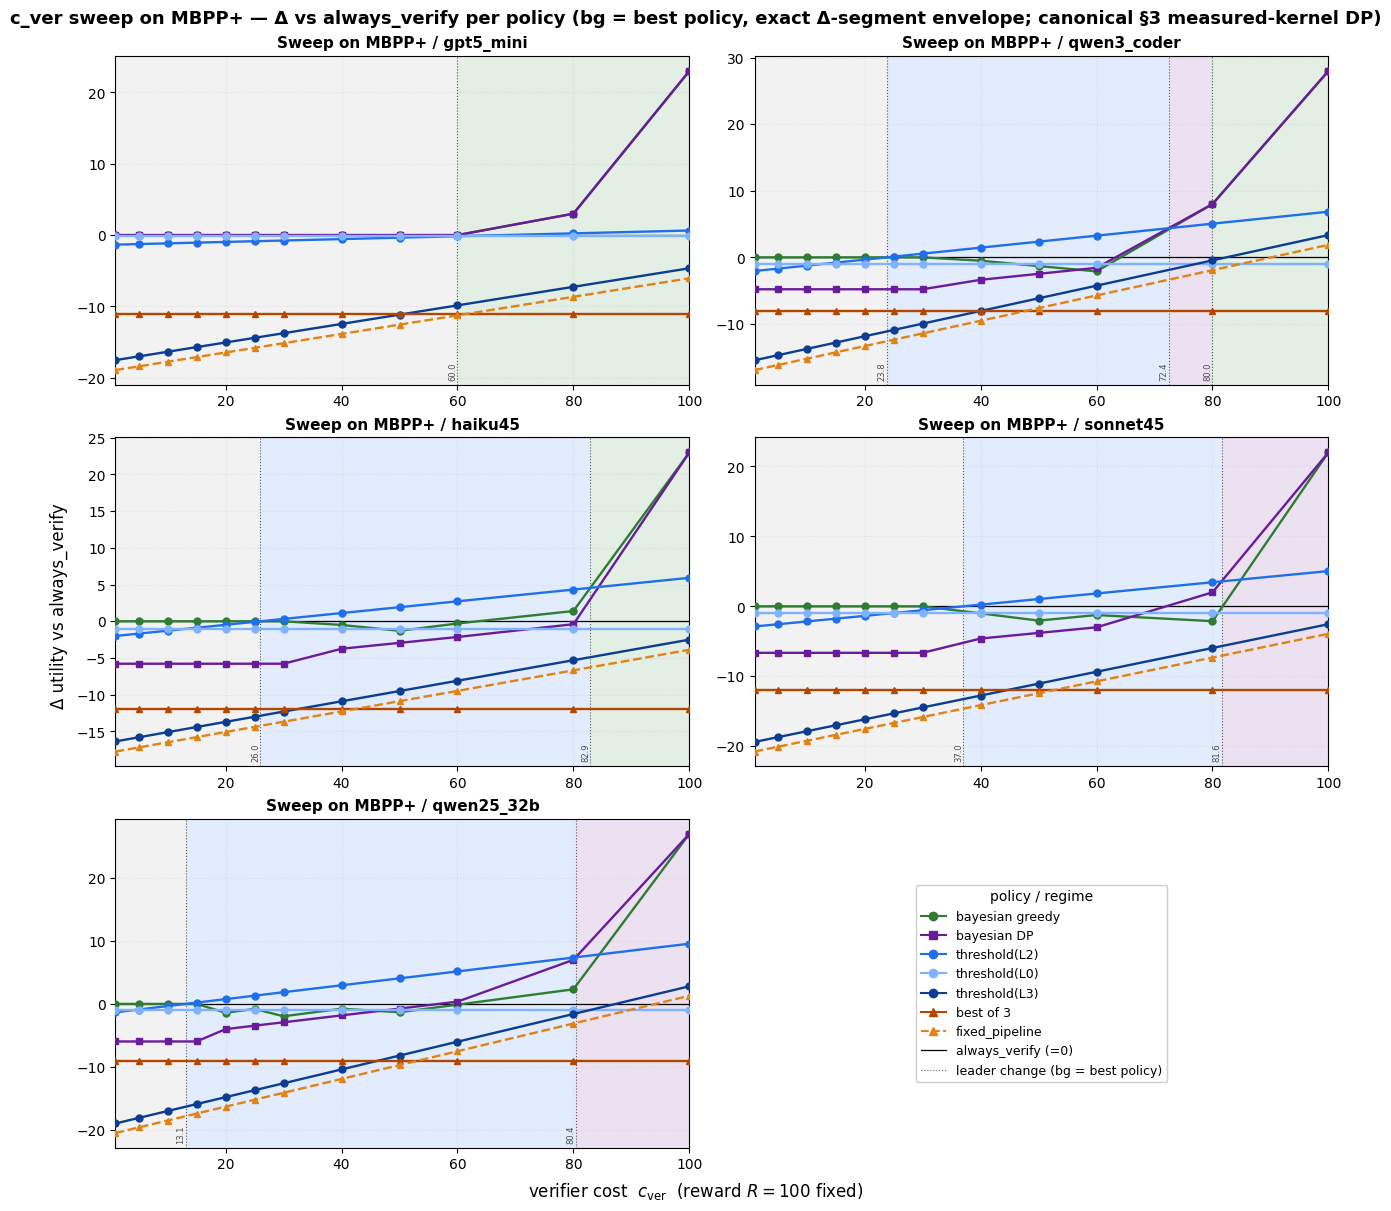

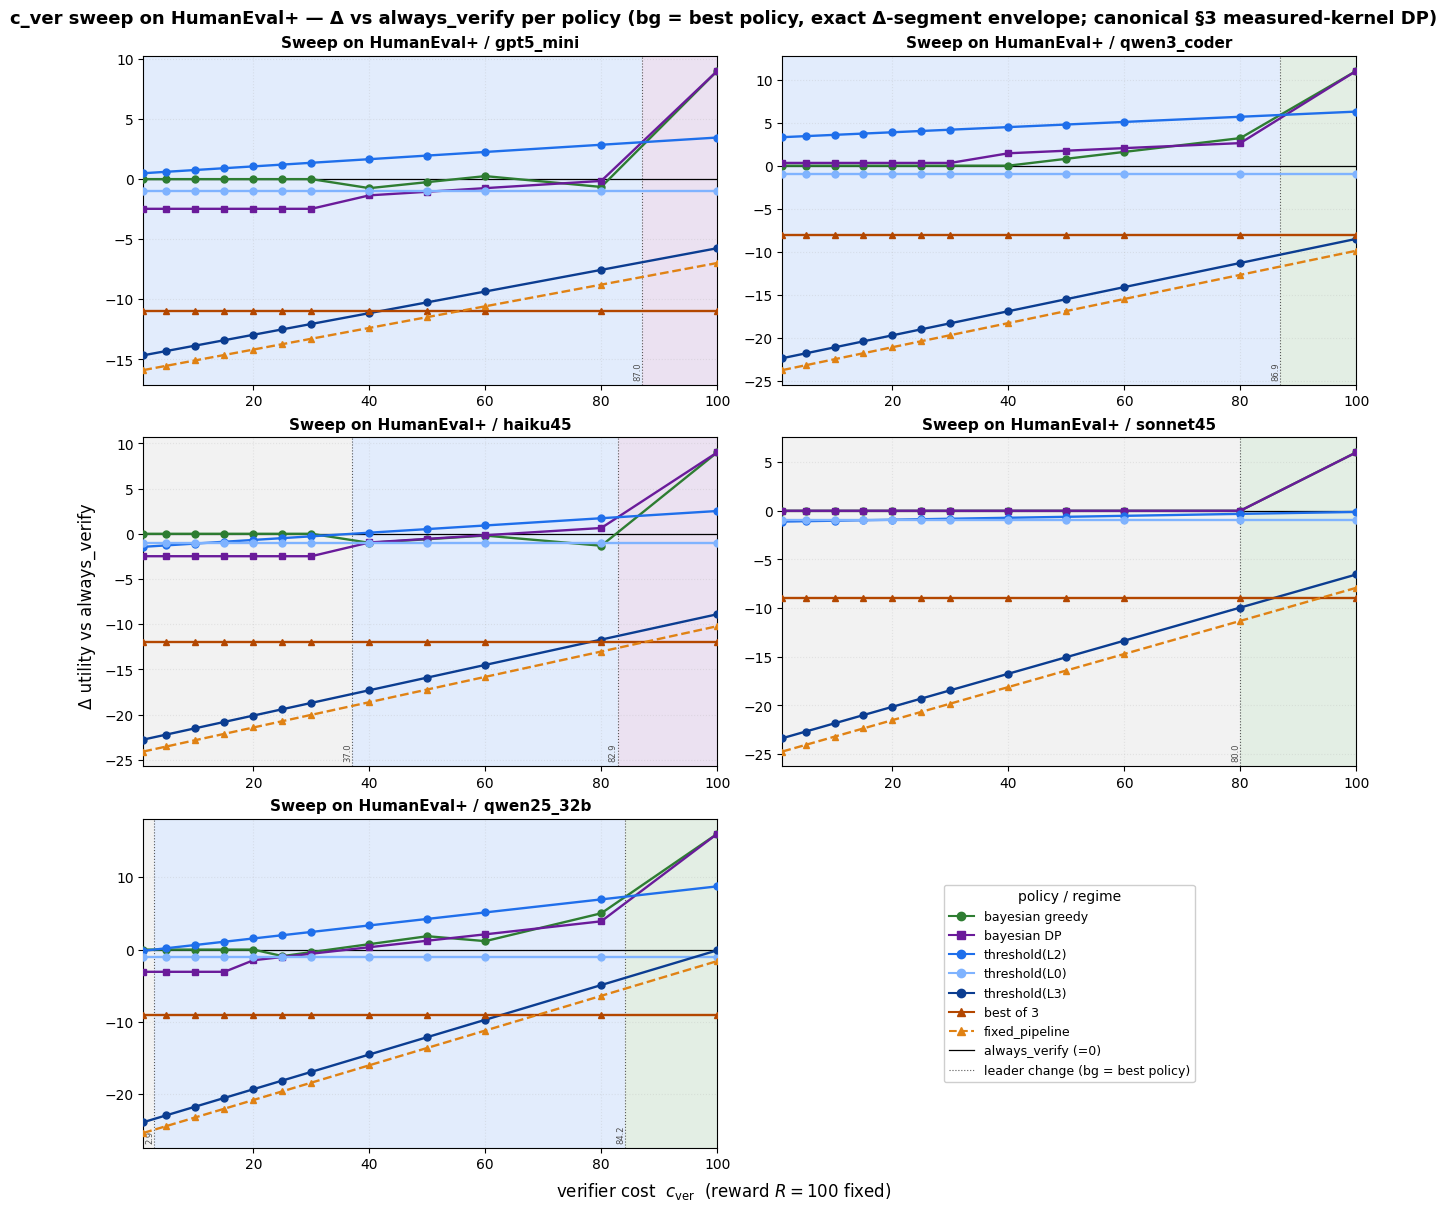

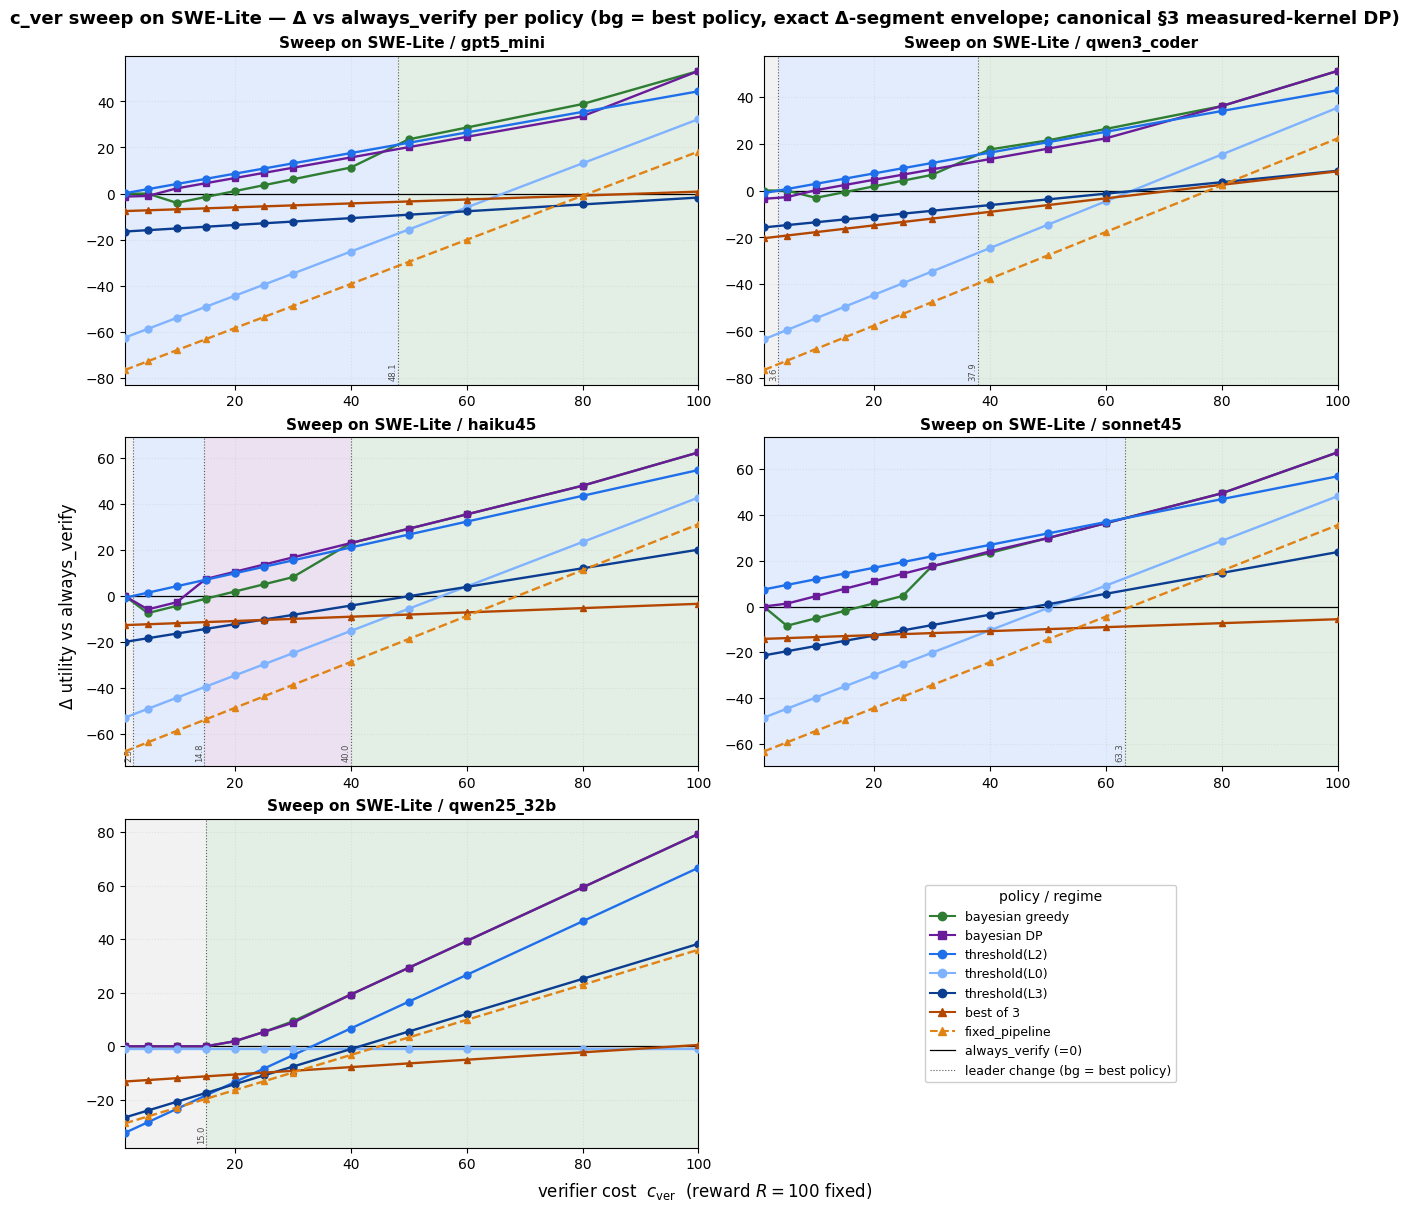

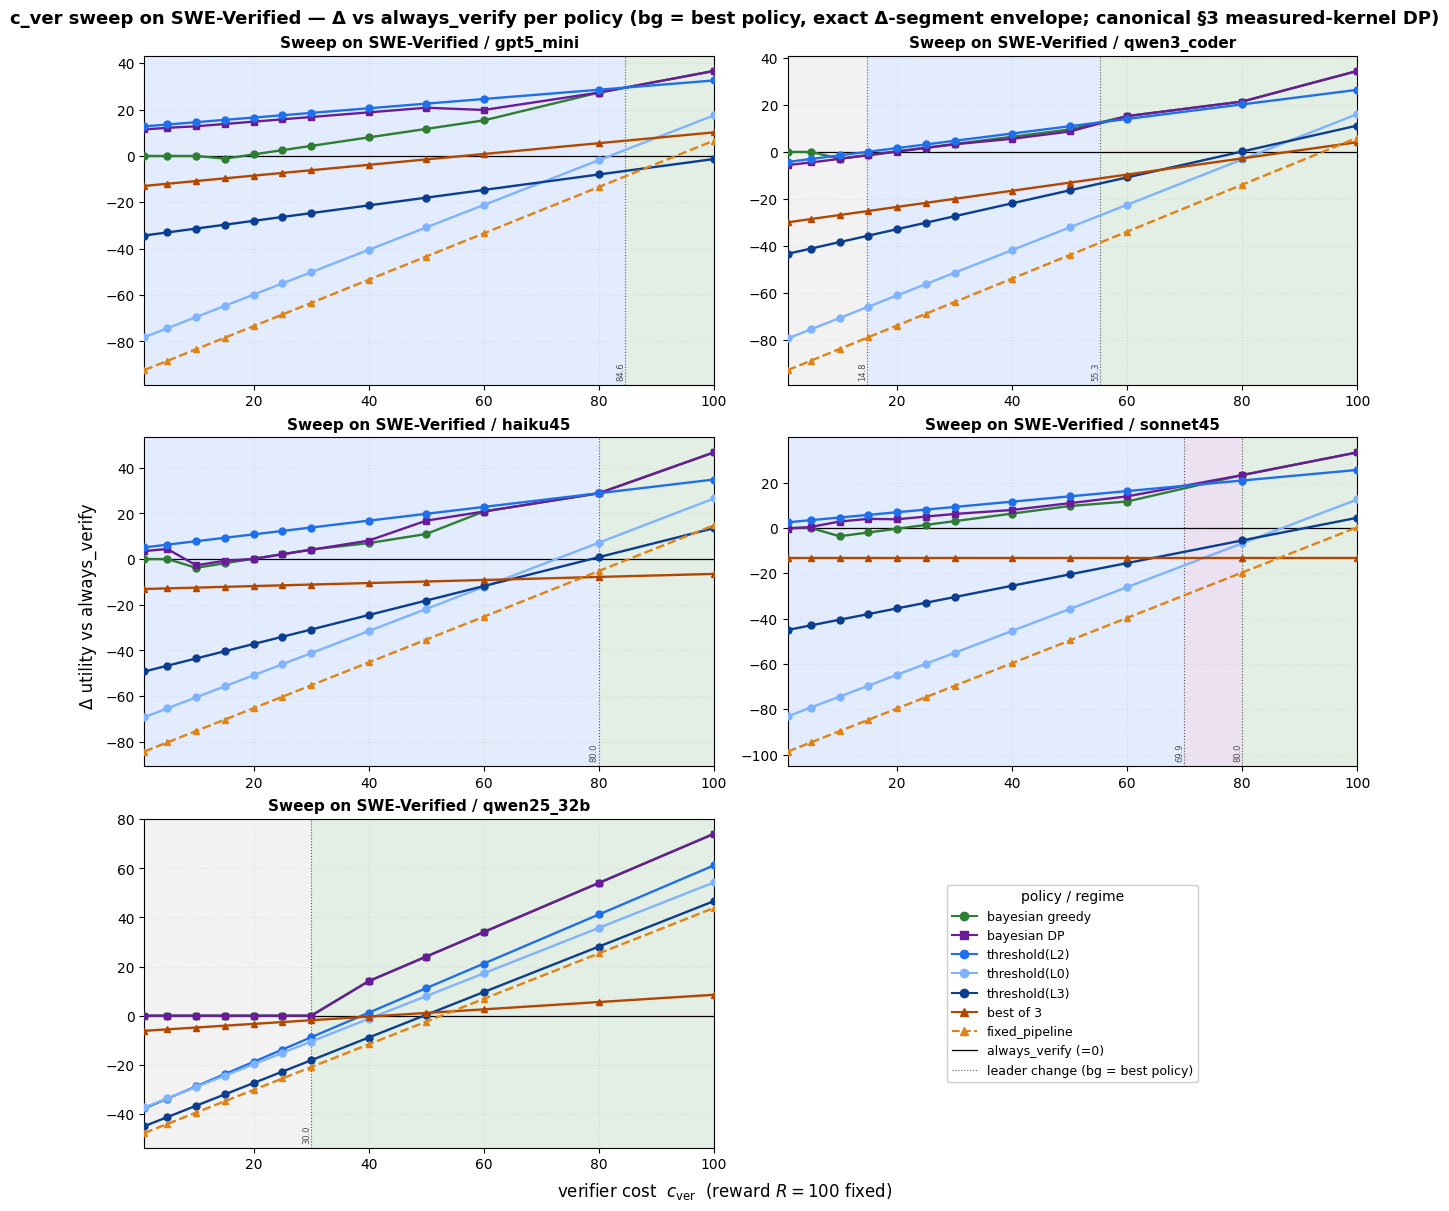

In [157]:
# %% §15 c_ver sweep — Δ vs always_verify per policy, grid by generator
#    One figure per benchmark; x = raw c_ver (R=100 fixed). Δ at grid
#    points = canonical _res_canon (run_policies + §3 measured single_method
#    -kernel DP), reused from the §14 regime grid. Background = the EXACT
#    upper envelope of the plotted Δ segments (+ always_verify ≡ 0): per
#    CVER_SWEEP interval each policy is a straight segment; the band is the
#    top segment, dividers at the analytic segment intersections where the
#    leader changes. No utility recomputation, no dense grid, no bisection —
#    the shading matches the drawn lines by construction.
import numpy as np, matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from run_baseline_vs_controller import CostModel

assert all(n in globals() for n in ("CELLS", "_res_canon", "POLICY_NAMES")), \
    ("run the §14 regime-grid companion cell first — this reuses its "
     "canonical CELLS / _res_canon (run_policies + §3 measured-kernel DP); "
     "it does not reimplement them.")

R_FIX  = 100                                  # fixed reward; sweep raw c_ver
CVER_SWEEP = [1, 5, 10, 15, 20, 25, 30, 40, 50, 60, 80, 100]
GEN_ORDER  = ["gpt5_mini", "qwen3_coder", "haiku45", "sonnet45", "qwen25_32b"]
BENCH_ORDER = ["lcb_hard", "lcb_medium", "lcb_easy", "mbpp", "humaneval",
               "swe_lite", "swe_verified"]
BLAB = {"lcb_hard": "LCB-hard", "lcb_medium": "LCB-medium",
        "lcb_easy": "LCB-easy", "mbpp": "MBPP+", "humaneval": "HumanEval+",
        "swe_lite": "SWE-Lite", "swe_verified": "SWE-Verified"}
PSTYLE = {
    "bayesian_greedy": ("bayesian greedy", "#2e7d32", "o", "-"),
    "bayesian_DP":     ("bayesian DP",     "#6a1b9a", "s", "-"),
    "threshold_L2":    ("threshold(L2)",   "#1f6feb", "o", "-"),
    "threshold_L0":    ("threshold(L0)",   "#7fb3ff", "o", "-"),
    "threshold_L3":    ("threshold(L3)",   "#0b3d91", "o", "-"),
    "best_of_3":       ("best of 3",       "#b34700", "^", "-"),
    "fixed_pipeline":  ("fixed_pipeline",  "#e08214", "^", "--"),
}
PLOT_POLICIES = list(PSTYLE)
_ORD = {p: i for i, p in enumerate(POLICY_NAMES)}     # tie-break order
def _pcol(p):                                         # band colour
    return PSTYLE[p][1] if p in PSTYLE else "#9e9e9e"  # always_verify=grey

def _best_regions(xs, series):
    """Exact upper envelope of straight Δ segments over [xs] (series:
    policy -> Δ at each xs; always_verify ≡ 0 added). Returns merged
    [x0, x1, policy] with boundaries at the analytic segment crossings.
    No utility recomputation — pure geometry on the plotted endpoints."""
    cands = [(p, list(map(float, ys))) for p, ys in series.items()
             if not all(np.isnan(v) for v in ys)]
    cands.append(("always_verify", [0.0] * len(xs)))

    def _y(ys, i, x):                                 # linear interp on seg i
        xL, xR = xs[i], xs[i + 1]
        return ys[i] + (x - xL) * (ys[i + 1] - ys[i]) / (xR - xL)

    def _best(i, x):
        bp, by = None, -1e18
        for p, ys in cands:
            if np.isnan(ys[i]) or np.isnan(ys[i + 1]):
                continue
            y = _y(ys, i, x)
            if y > by + 1e-9 or (abs(y - by) <= 1e-9 and
                                 _ORD.get(p, 99) < _ORD.get(bp, 99)):
                by, bp = y, p
        return bp

    regs = []
    for i in range(len(xs) - 1):
        xL, xR = xs[i], xs[i + 1]
        bps = {xL, xR}
        for a in range(len(cands)):
            ya = cands[a][1]
            for b in range(a + 1, len(cands)):
                yb = cands[b][1]
                if any(np.isnan(v) for v in
                       (ya[i], ya[i + 1], yb[i], yb[i + 1])):
                    continue
                den = (ya[i + 1] - ya[i]) - (yb[i + 1] - yb[i])
                if abs(den) < 1e-12:
                    continue
                t = (yb[i] - ya[i]) / den
                if 1e-9 < t < 1 - 1e-9:
                    bps.add(xL + t * (xR - xL))
        bps = sorted(bps)
        for s in range(len(bps) - 1):
            x0, x1 = bps[s], bps[s + 1]
            if x1 - x0 < 1e-7:
                continue
            regs.append([x0, x1, _best(i, 0.5 * (x0 + x1))])
    merged = [regs[0]]
    for x0, x1, p in regs[1:]:
        if p == merged[-1][2] and abs(x0 - merged[-1][1]) < 1e-6:
            merged[-1][1] = x1
        else:
            merged.append([x0, x1, p])
    return merged

def _winner_bands(ax, regions):
    """Shade by upper-envelope regions; dotted divider + label at each
    leader change (the segment-intersection c_ver)."""
    for k, (x0, x1, p) in enumerate(regions):
        ax.axvspan(x0, x1, color=_pcol(p), alpha=0.13, lw=0, zorder=0)
        if k:                                         # boundary with prev
            ax.axvline(x0, color="0.35", ls=":", lw=0.8, zorder=1.5)
            ax.text(x0, 0.015, f"{x0:.1f}",
                    transform=ax.get_xaxis_transform(), rotation=90,
                    va="bottom", ha="right", fontsize=6, color="0.30")

def _cver_sweep_grid(bench):
    """One figure per benchmark: Δ-vs-always_verify per policy as c_ver
    sweeps (R fixed), a panel per generator; background = exact upper
    envelope of the plotted Δ segments (best policy per c_ver)."""
    gens = [g for g in GEN_ORDER if (bench, g) in CELLS] + \
           [g for (b, g) in CELLS if b == bench and g not in GEN_ORDER]
    if not gens:
        print(f"  {bench}: no cells in CELLS — skipped")
        return
    curves = {g: {p: [] for p in PLOT_POLICIES} for g in gens}
    for g in gens:
        tr, lk, pr = CELLS[(bench, g)]
        for cv in CVER_SWEEP:                         # 12 evals/gen only
            res = _res_canon(bench, g, tr, lk, pr,
                             CostModel(c_gen=5, c_L0=1, c_L2=2, c_L3=5,
                                       c_ver=cv, reward=R_FIX))
            for p in PLOT_POLICIES:
                curves[g][p].append(res[p]["diff_vs_baseline"]
                                    if p in res else np.nan)

    ncol = 2
    nrow = -(-len(gens) // ncol)
    fig, axes = plt.subplots(nrow, ncol, figsize=(13, 4.0 * nrow),
                             squeeze=False, constrained_layout=True)
    blab = BLAB.get(bench, bench)
    for idx, g in enumerate(gens):
        ax = axes[idx // ncol][idx % ncol]
        _winner_bands(ax, _best_regions(CVER_SWEEP, curves[g]))
        for p in PLOT_POLICIES:
            lab, col, mk, ls = PSTYLE[p]
            ax.plot(CVER_SWEEP, curves[g][p], marker=mk, ls=ls, color=col,
                    ms=5, lw=1.7, label=lab, zorder=3)
        ax.axhline(0, color="black", lw=0.9, zorder=2)   # always_verify (=0)
        ax.set_title(f"Sweep on {blab} / {g}", fontsize=11,
                     fontweight="bold")
        ax.set_xlim(min(CVER_SWEEP), max(CVER_SWEEP))
        ax.grid(alpha=0.25, linestyle=":"); ax.set_axisbelow(True)

    leg_ax = (axes.ravel()[len(gens)]
              if nrow * ncol > len(gens) else None)
    for j in range(len(gens), nrow * ncol):
        axes[j // ncol][j % ncol].axis("off")
    handles = [Line2D([0], [0], color=PSTYLE[p][1], marker=PSTYLE[p][2],
                       ls=PSTYLE[p][3], label=PSTYLE[p][0])
               for p in PLOT_POLICIES]
    handles += [Line2D([0], [0], color="black", lw=0.9,
                       label="always_verify (=0)"),
                Line2D([0], [0], color="0.35", ls=":", lw=0.8,
                       label="leader change (bg = best policy)")]
    if leg_ax is not None:
        leg_ax.legend(handles=handles, loc="center", fontsize=9,
                      framealpha=0.95, title="policy / regime")
    else:
        fig.legend(handles=handles, loc="lower center", ncol=4, fontsize=9)
    if hasattr(fig, "supxlabel"):
        fig.supxlabel(r"verifier cost  $c_\mathrm{ver}$  "
                      r"(reward $R{=}100$ fixed)", fontsize=12)
        fig.supylabel("Δ utility vs always_verify", fontsize=12)
    fig.suptitle(f"c_ver sweep on {blab} — Δ vs always_verify per policy "
                 "(bg = best policy, exact Δ-segment envelope; "
                 "canonical §3 measured-kernel DP)",
                 fontsize=13, fontweight="bold")
    fig.savefig(CACHE / f"fig_cver_sweep_{bench}.png", dpi=150,
                bbox_inches="tight")
    plt.show()

for _b in BENCH_ORDER:
    _cver_sweep_grid(_b)